# CE 639: AI for Civil Engineering
## Deep Learning for Civil Engineering — Hands-On CE Applications

**`Training_Tutorial_CE.py`** — A fully self-contained, domain-first training tutorial

---

### What This Tutorial Is

This is a **domain-first** tutorial. Every dataset, every visualization, and every metric
speaks the language of civil engineering. The question it answers:

> *"How do I actually apply FNNs, CNNs, and RNNs to MY civil engineering problem?"*

The answer unfolds across three complete, self-contained modules:

| Part | Architecture | CE Problem                  | Task            | Dataset                      |
|------|--------------|-----------------------------|-----------------|------------------------------ |
| 1    | FNN          | RC Beam Midspan Deflection  | Regression      | Branson's formula (2000 pts) |
| 2    | CNN          | Concrete Crack Detection    | Classification  | Procedural images (400 imgs) |
| 3    | RNN / LSTM   | Streamflow Forecasting      | Time-series Reg | Rainfall-runoff model (1yr)  |

**No external downloads.** All datasets are generated from physics equations inline.
**No `utils` imports.** Every helper function is defined in this file.

### Structure

| Section | Topic                                    |
|---------|------------------------------------------|
| 0       | Setup, imports, reproducibility          |
| 1       | FNN: RC Beam Deflection (end-to-end)     |
| 2       | CNN: Crack Detection (end-to-end)        |
| 3       | LSTM: Streamflow Forecasting (end-to-end)|
| 4       | Cross-model comparison & CE cheat sheet  |

---
*CE 639: AI for Civil Engineering — IIT Gandhinagar*
*Instructors: Dr. Udit Bhatia & Dr. Sushobhan Sen*

---
## Section 0: Setup, Imports, and Reproducibility

All imports in one place. All random seeds fixed here. Device detected once.

In [1]:
# ─── Standard scientific stack ────────────────────────────────────────────────
import os
import sys
import math
import time
import copy
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (confusion_matrix, classification_report,
                             r2_score, mean_absolute_error, mean_squared_error)

print("✅ numpy, matplotlib, sklearn loaded")

# ─── scipy (optional) ─────────────────────────────────────────────────────────
try:
    from scipy.ndimage import gaussian_filter1d
    from scipy.stats import pearsonr
    SCIPY_OK = True
    print("✅ scipy loaded")
except ImportError:
    SCIPY_OK = False
    print("⚠️  scipy not found — using numpy fallbacks")
    def gaussian_filter1d(x, sigma):
        w = max(int(sigma * 3) | 1, 3)
        kernel = np.exp(-0.5 * ((np.arange(w) - w // 2) / sigma) ** 2)
        kernel /= kernel.sum()
        return np.convolve(x, kernel, mode='same')

# ─── PyTorch ──────────────────────────────────────────────────────────────────
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
    from torch.utils.data import (TensorDataset, DataLoader, Dataset,
                                   random_split, Subset)
    TORCH_OK = True
    print(f"✅ PyTorch {torch.__version__}")
except ImportError:
    TORCH_OK = False
    print("⚠️  PyTorch not found.  Install: pip install torch")

# ─── ipywidgets (optional) ────────────────────────────────────────────────────
try:
    import ipywidgets as widgets
    from IPython.display import display as ipy_display
    WIDGETS_OK = True
    print("✅ ipywidgets loaded — interactive widgets enabled")
except ImportError:
    WIDGETS_OK = False
    print("ℹ️  ipywidgets not found — static plots used instead")

✅ numpy, matplotlib, sklearn loaded
✅ scipy loaded
✅ PyTorch 2.10.0+cu128
✅ ipywidgets loaded — interactive widgets enabled


In [34]:
# ─── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
if TORCH_OK:
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False

# ─── Device ───────────────────────────────────────────────────────────────────
if TORCH_OK:
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"\n🖥️  Device: {DEVICE}")
    if DEVICE.type == 'cuda':
        print(f"   GPU: {torch.cuda.get_device_name(0)}")
        print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
    else:
        print("   Running on CPU — demo mode is tuned for reasonable CPU runtime.")
else:
    DEVICE = None

# ─── Training speed / size flags ──────────────────────────────────────────────
# FULL_TRAINING = True  →  longer runs, more data, higher quality results
# FULL_TRAINING = False →  fast demo for classroom / laptop  (default)
FULL_TRAINING = True

N_BEAM             = 2000                                  # FNN samples
N_CRACK_PER_CLASS  = 100 if not FULL_TRAINING else 200    # images per class
N_STREAMFLOW_DAYS  = 365 if not FULL_TRAINING else 730    # days of hydrology data
N_EPOCHS_FNN       = 10  if not FULL_TRAINING else 80
N_EPOCHS_CNN       = 10  if not FULL_TRAINING else 40
N_EPOCHS_LSTM      = 20  if not FULL_TRAINING else 80
N_EPOCHS_SWEEP     = 8   if not FULL_TRAINING else 25     # lookback sensitivity
LOOKBACK           = 30                                    # LSTM lookback window (days)

print(f"\n⚙️  FULL_TRAINING = {FULL_TRAINING}")
print(f"   FNN  : {N_BEAM} samples, {N_EPOCHS_FNN} epochs")
print(f"   CNN  : {N_CRACK_PER_CLASS}×2 images, {N_EPOCHS_CNN} epochs")
print(f"   LSTM : {N_STREAMFLOW_DAYS} days, {N_EPOCHS_LSTM} epochs")


🖥️  Device: cuda
   GPU: Tesla T4
   VRAM: 15.6 GB

⚙️  FULL_TRAINING = True
   FNN  : 2000 samples, 80 epochs
   CNN  : 200×2 images, 40 epochs
   LSTM : 730 days, 80 epochs


In [35]:
# ─── Plotting style ───────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize'  : [13, 5],
    'font.size'       : 11,
    'axes.titlesize'  : 13,
    'axes.titleweight': 'bold',
    'axes.labelsize'  : 11,
    'figure.dpi'      : 100,
    'lines.linewidth' : 2,
})

# Colour palette (CE-themed)
C_BLUE   = '#2196F3'
C_RED    = '#E53935'
C_GREEN  = '#43A047'
C_ORANGE = '#FB8C00'
C_PURPLE = '#8E24AA'
C_TEAL   = '#00ACC1'
C_BROWN  = '#6D4C41'

print("✅ Plotting style configured")

✅ Plotting style configured


In [36]:
# ─── TrainingLogger ───────────────────────────────────────────────────────────

class TrainingLogger:
    """
    Rich logging for PyTorch training loops.

    Prints epoch-by-epoch tables with engineering units, marks the best epoch,
    and provides a final summary with test metrics.
    """

    def __init__(self, model_name: str, metric_name: str = 'Loss',
                 metric_unit: str = '', lower_is_better: bool = True):
        self.model_name       = model_name
        self.metric_name      = metric_name
        self.metric_unit      = metric_unit
        self.lower_is_better  = lower_is_better
        self.train_history    = []
        self.val_history      = []
        self.epoch_history    = []
        self.best_val         = float('inf') if lower_is_better else float('-inf')
        self.best_epoch       = 0
        self.start_time       = time.time()
        self._header_printed  = False
        self._width           = 72

    def _is_better(self, val):
        return val < self.best_val if self.lower_is_better else val > self.best_val

    def _print_header(self):
        print(f"\n{'═' * self._width}")
        print(f"   {self.model_name} — Training Log")
        print(f"{'═' * self._width}")
        self._header_printed = True

    def log_epoch(self, epoch: int, n_epochs: int,
                  train_val: float, val_val: float,
                  lr: float = None, extras: dict = None,
                  log_every: int = 1):
        """Record and optionally print one epoch."""
        if not self._header_printed:
            self._print_header()

        self.train_history.append(train_val)
        self.val_history.append(val_val)
        self.epoch_history.append(epoch)

        is_best = self._is_better(val_val)
        if is_best:
            self.best_val   = val_val
            self.best_epoch = epoch

        should_print = (epoch == 1 or epoch == n_epochs or epoch % log_every == 0)
        if should_print:
            elapsed  = time.time() - self.start_time
            u        = f' {self.metric_unit}' if self.metric_unit else ''
            lr_str   = f' │ LR: {lr:.2e}' if lr is not None else ''
            ext_str  = ''
            if extras:
                ext_str = ' │ ' + ' │ '.join(f'{k}: {v}' for k, v in extras.items())
            best_str = ' ★' if is_best else ''
            print(f"   Epoch {epoch:3d}/{n_epochs}"
                  f" │ Train {self.metric_name}: {train_val:8.3f}{u}"
                  f" │ Val {self.metric_name}: {val_val:8.3f}{u}"
                  f"{lr_str}{ext_str} │ {elapsed:.1f}s{best_str}")

    def summary(self, test_metrics: dict = None):
        """Print training complete summary."""
        elapsed = time.time() - self.start_time
        u       = f' {self.metric_unit}' if self.metric_unit else ''
        print(f"{'─' * self._width}")
        print(f"   ✅ Training complete in {elapsed:.1f}s")
        print(f"   Best val {self.metric_name}: {self.best_val:.4f}{u} "
              f"@ epoch {self.best_epoch}/{self.epoch_history[-1]}")
        if test_metrics:
            print(f"\n   📈 Test Metrics:")
            for k, v in test_metrics.items():
                print(f"      {k:<22s}: {v}")
        print(f"{'═' * self._width}\n")

print("✅ TrainingLogger defined")

✅ TrainingLogger defined


---
## Part 1: Feedforward Neural Networks for RC Beam Midspan Deflection

### 1.1 Motivation & Physics

**Civil Engineering Context:**
A structural engineer checks beam deflection thousands of times during optimisation.
Each check normally requires a finite-element solve.  A trained FNN surrogate cuts
evaluation from seconds to microseconds.

**Physics (Branson's Effective Moment of Inertia):**

$$\delta = \frac{P L^3}{48 \, E \, I_{\text{eff}}}$$

Where the effective moment of inertia transitions at cracking:

$$I_{\text{eff}} = \begin{cases}
I_{\text{gross}}                                                          & M_{\max} \leq M_{cr} \\
I_{cr} + (I_{\text{gross}} - I_{cr})\left(\dfrac{M_{cr}}{M_{\max}}\right)^3 & M_{\max} > M_{cr}
\end{cases}$$

- $M_{\max} = PL/4$ — applied midspan moment (simply supported beam)
- $M_{cr}$ — cracking moment (depends on concrete tensile strength)
- $I_{cr} \approx I_{\text{gross}} \cdot (\rho \cdot 10 + 0.1)$ — cracked section inertia

**Inputs (6):** Load $P$, Span $L$, Elastic Modulus $E$, $I_{\text{gross}}$, $M_{cr}$, $\rho$
**Output (1):** Midspan deflection $\delta$ [mm]

**Why an FNN?** The piecewise nonlinearity at cracking is smooth but difficult to
capture with a linear model. An FNN learns this transition from data.

In [37]:
# ─── Inline dataset generator: Beam Deflection ────────────────────────────────

def generate_beam_deflection_dataset(n=2000, noise_frac=0.05, random_state=42):
    """
    Generate synthetic RC beam midspan deflection dataset.

    Physics: Branson's effective moment of inertia model.
    δ = P·L³ / (48·E·I_eff)   [mm]

    Returns
    -------
    X    : (n, 6) — raw features in engineering units
    y    : (n,)   — deflection [mm]
    meta : dict   — feature names, cracking flags, etc.
    """
    rng = np.random.default_rng(random_state)

    # ── Sample physical inputs ──────────────────────────────────────────────
    P       = rng.uniform(10.0,   500.0,  n)          # kN
    L       = rng.uniform(2.0,    10.0,   n)          # m
    E_GPa   = rng.uniform(25.0,   40.0,   n)          # GPa
    E       = E_GPa * 1e6                              # kN/m²
    I_gross = rng.uniform(1.0,    20.0,   n) * 1e-3   # m⁴
    M_cr    = rng.uniform(5.0,    80.0,   n)          # kN·m
    rho     = rng.uniform(0.005,  0.04,   n)          # dimensionless

    # ── Derived mechanics ───────────────────────────────────────────────────
    M_max   = P * L / 4.0                             # kN·m (simply supported)

    # Cracked section inertia (Branson approximation)
    I_cr    = I_gross * np.clip(rho * 10 + 0.1, 0.05, 0.95)

    # Effective inertia (piecewise at cracking)
    ratio   = np.where(M_max > 0, M_cr / np.maximum(M_max, 1e-6), 1.0)
    ratio   = np.clip(ratio, 0.0, 1.0)
    I_eff   = np.where(
        M_max <= M_cr,
        I_gross,
        I_cr + (I_gross - I_cr) * ratio ** 3
    )
    I_eff   = np.clip(I_eff, 0.01 * I_gross, I_gross)

    # Midspan deflection  [m → mm]
    delta   = (P * L ** 3) / (48.0 * E * I_eff) * 1000.0
    delta   = np.clip(delta, 0.1, 200.0)

    # Add measurement noise
    delta_range = delta.max() - delta.min()
    delta += rng.normal(0, noise_frac * delta_range, n)
    delta   = np.clip(delta, 0.05, 220.0)

    # Cracking flag (useful for colouring plots)
    cracked = (M_max > M_cr).astype(int)

    # Feature matrix (human-readable units)
    X = np.column_stack([P, L, E_GPa, I_gross * 1e3, M_cr, rho])
    y = delta.astype(np.float32)

    meta = {
        'feature_names' : ['P (kN)', 'L (m)', 'E (GPa)',
                           'I_gross (1e-3 m⁴)', 'M_cr (kN·m)', 'ρ (-)'],
        'target_name'   : 'δ (mm)',
        'formula'       : 'δ = PL³/(48·E·I_eff), Branson piecewise',
        'n_samples'     : n,
        'cracked'       : cracked,
        'M_max'         : M_max,
    }
    return X.astype(np.float32), y, meta


# ─── Generate data ─────────────────────────────────────────────────────────────
print("=" * 72)
print("  PART 1: FNN FOR RC BEAM MIDSPAN DEFLECTION")
print("=" * 72)

X_beam, y_beam, meta_beam = generate_beam_deflection_dataset(
    n=N_BEAM, noise_frac=0.05, random_state=SEED)

n_cracked   = meta_beam['cracked'].sum()
n_uncracked = N_BEAM - n_cracked

print(f"\n📊 Dataset summary:")
print(f"   Samples  : {N_BEAM}")
print(f"   Features : {X_beam.shape[1]}  →  {meta_beam['feature_names']}")
print(f"   Target   : {meta_beam['target_name']}")
print(f"   δ range  : [{y_beam.min():.2f}, {y_beam.max():.2f}] mm")
print(f"   δ mean   : {y_beam.mean():.2f} mm  ±  {y_beam.std():.2f} mm")
print(f"   Cracked  : {n_cracked} ({n_cracked/N_BEAM:.1%})   "
      f"Uncracked: {n_uncracked} ({n_uncracked/N_BEAM:.1%})")

for i, name in enumerate(meta_beam['feature_names']):
    print(f"   {name:<22s}: [{X_beam[:,i].min():.3f}, {X_beam[:,i].max():.3f}]"
          f"  mean={X_beam[:,i].mean():.3f}")

  PART 1: FNN FOR RC BEAM MIDSPAN DEFLECTION

📊 Dataset summary:
   Samples  : 2000
   Features : 6  →  ['P (kN)', 'L (m)', 'E (GPa)', 'I_gross (1e-3 m⁴)', 'M_cr (kN·m)', 'ρ (-)']
   Target   : δ (mm)
   δ range  : [0.05, 220.00] mm
   δ mean   : 26.20 mm  ±  41.65 mm
   Cracked  : 1896 (94.8%)   Uncracked: 104 (5.2%)
   P (kN)                : [10.254, 499.717]  mean=256.390
   L (m)                 : [2.005, 9.998]  mean=5.946
   E (GPa)               : [25.005, 39.996]  mean=32.323
   I_gross (1e-3 m⁴)     : [1.008, 20.000]  mean=10.482
   M_cr (kN·m)           : [5.043, 79.929]  mean=42.674
   ρ (-)                 : [0.005, 0.040]  mean=0.023


### 1.3 Exploratory Data Analysis

Four visualisations before any model is trained:
1. Feature distributions (coloured by cracking state)
2. Feature-vs-deflection scatterplots (shows nonlinearity)
3. Correlation heatmap (quantifies input-output dependencies)
4. Characteristic P–δ curve (shows the physics kink at cracking)

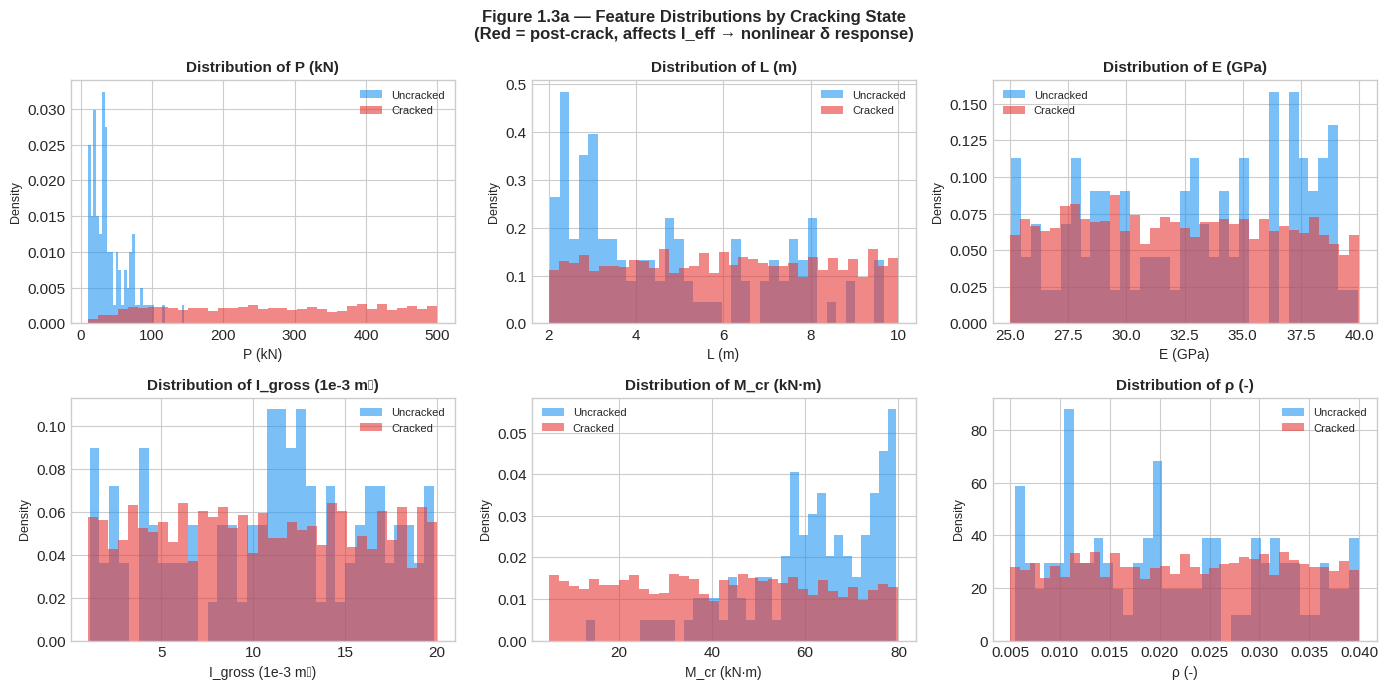

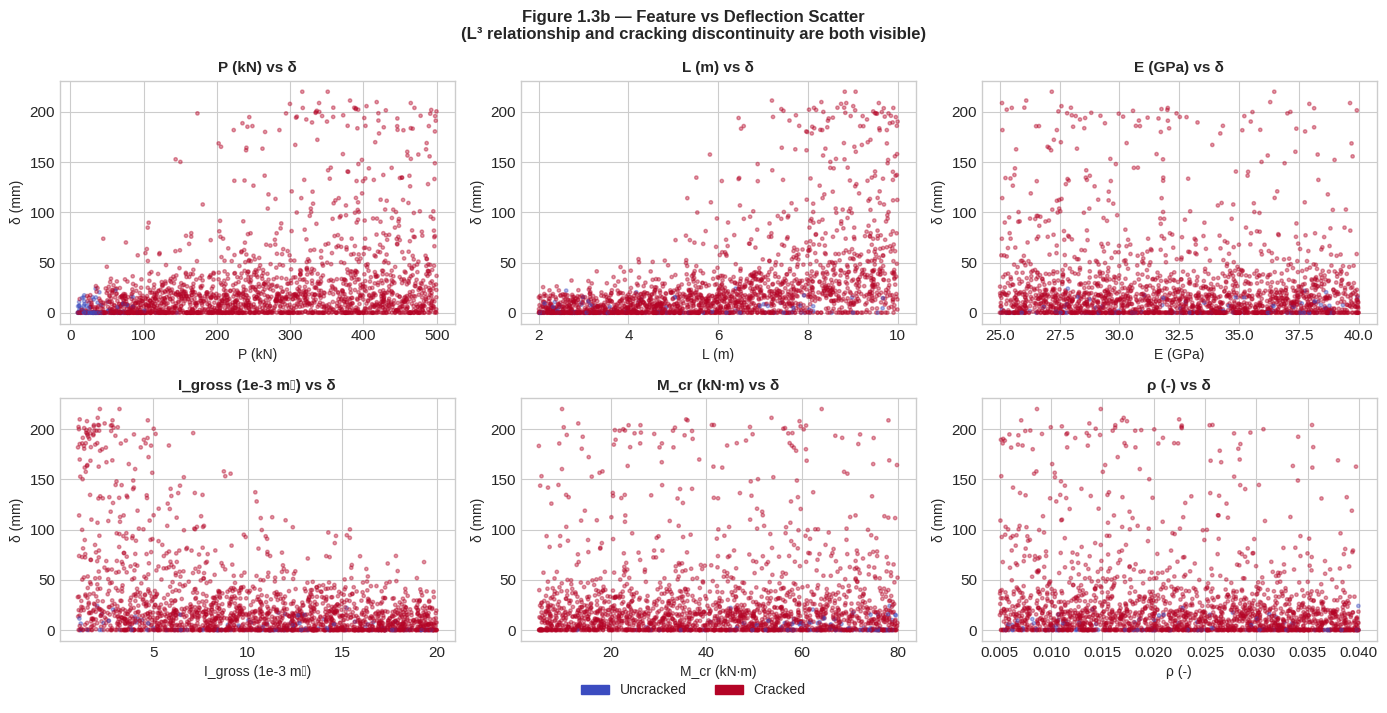

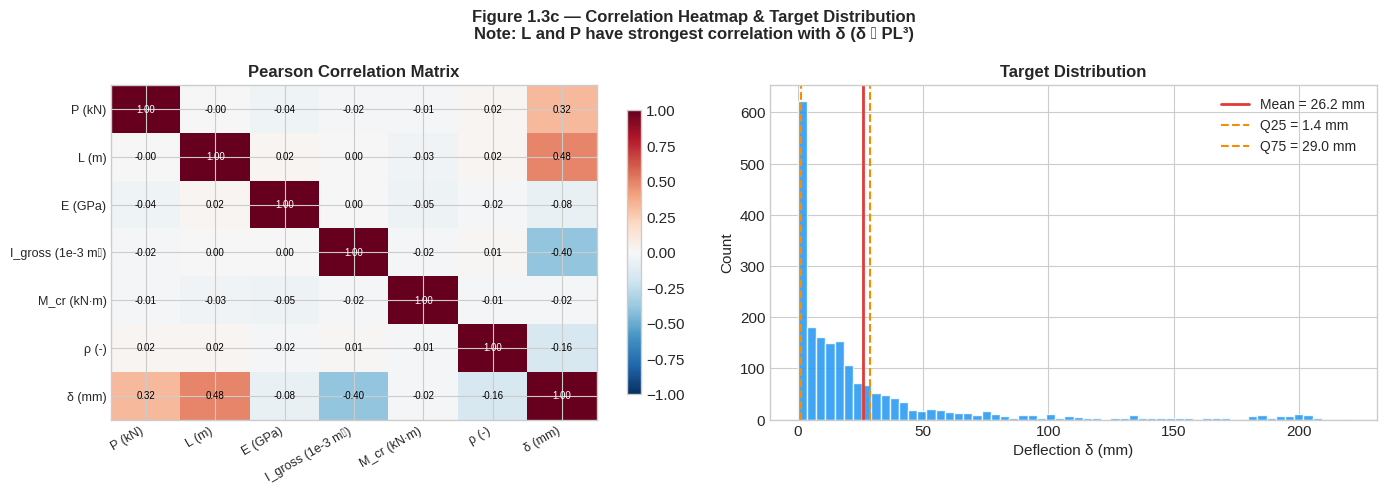


💡 Physical interpretation of correlations:
   P (kN)                : r = +0.323
   L (m)                 : r = +0.484
   E (GPa)               : r = -0.075
   I_gross (1e-3 m⁴)     : r = -0.395
   M_cr (kN·m)           : r = -0.016
   ρ (-)                 : r = -0.162

   → L (span) has the strongest correlation: δ ∝ L³
   → E and I_gross are negative (stiffer → less deflection)


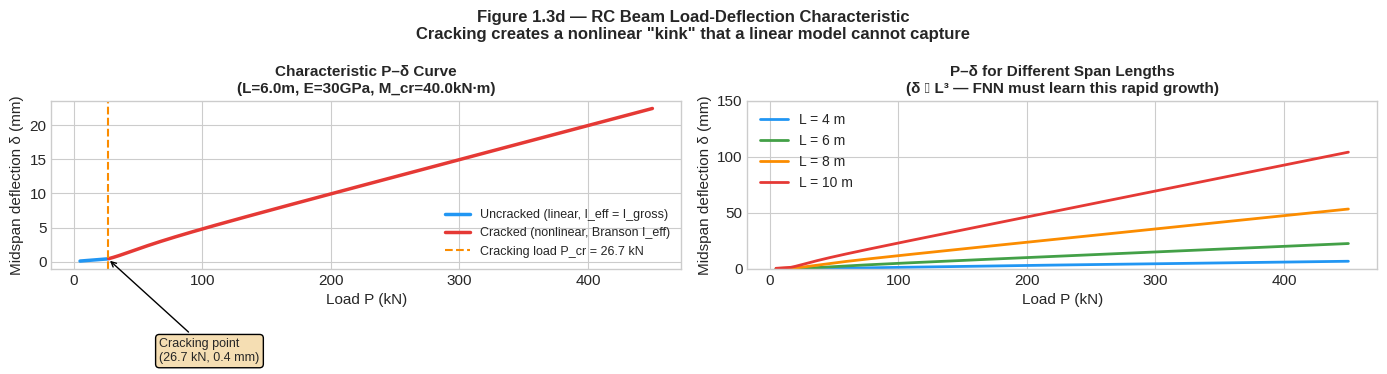

In [38]:
# ─── Figure 1.3a: Feature distributions ──────────────────────────────────────
cracked_mask = meta_beam['cracked'].astype(bool)

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

colours = {0: C_BLUE, 1: C_RED}
labels  = {0: 'Uncracked', 1: 'Cracked'}

for i, (ax, name) in enumerate(zip(axes, meta_beam['feature_names'])):
    for state in [0, 1]:
        mask = (meta_beam['cracked'] == state)
        ax.hist(X_beam[mask, i], bins=35, alpha=0.6,
                color=colours[state], label=labels[state], density=True)
    ax.set_xlabel(name, fontsize=10)
    ax.set_ylabel('Density', fontsize=9)
    ax.set_title(f'Distribution of {name}', fontsize=11)
    ax.legend(fontsize=8)

plt.suptitle('Figure 1.3a — Feature Distributions by Cracking State\n'
             '(Red = post-crack, affects I_eff → nonlinear δ response)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ──  Figure 1.3b: Feature vs target scatterplots ──────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, (ax, name) in enumerate(zip(axes, meta_beam['feature_names'])):
    sc = ax.scatter(X_beam[:, i], y_beam, c=meta_beam['cracked'],
                    cmap='coolwarm', s=6, alpha=0.4)
    ax.set_xlabel(name, fontsize=10)
    ax.set_ylabel('δ (mm)', fontsize=10)
    ax.set_title(f'{name} vs δ', fontsize=11)

handles = [mpatches.Patch(color=plt.cm.coolwarm(0.0), label='Uncracked'),
           mpatches.Patch(color=plt.cm.coolwarm(1.0), label='Cracked')]
fig.legend(handles=handles, loc='lower center', ncol=2, fontsize=10,
           bbox_to_anchor=(0.5, -0.02))
plt.suptitle('Figure 1.3b — Feature vs Deflection Scatter\n'
             '(L³ relationship and cracking discontinuity are both visible)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ─── Figure 1.3c: Correlation heatmap + target distribution ──────────────────
all_data = np.column_stack([X_beam, y_beam])
all_names = meta_beam['feature_names'] + [meta_beam['target_name']]
corr_matrix = np.corrcoef(all_data.T)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im = axes[0].imshow(corr_matrix, vmin=-1, vmax=1, cmap='RdBu_r', aspect='auto')
axes[0].set_xticks(range(len(all_names)))
axes[0].set_yticks(range(len(all_names)))
axes[0].set_xticklabels(all_names, rotation=30, ha='right', fontsize=9)
axes[0].set_yticklabels(all_names, fontsize=9)
for ii in range(len(all_names)):
    for jj in range(len(all_names)):
        axes[0].text(jj, ii, f'{corr_matrix[ii, jj]:.2f}',
                     ha='center', va='center', fontsize=7,
                     color='white' if abs(corr_matrix[ii, jj]) > 0.5 else 'black')
plt.colorbar(im, ax=axes[0], shrink=0.85)
axes[0].set_title('Pearson Correlation Matrix', fontsize=12)

axes[1].hist(y_beam, bins=60, color=C_BLUE, edgecolor='white', alpha=0.85)
axes[1].axvline(y_beam.mean(), color=C_RED, lw=2, label=f'Mean = {y_beam.mean():.1f} mm')
axes[1].axvline(np.percentile(y_beam, 25), color=C_ORANGE, lw=1.5,
                ls='--', label=f'Q25 = {np.percentile(y_beam,25):.1f} mm')
axes[1].axvline(np.percentile(y_beam, 75), color=C_ORANGE, lw=1.5,
                ls='--', label=f'Q75 = {np.percentile(y_beam,75):.1f} mm')
axes[1].set_xlabel('Deflection δ (mm)', fontsize=11)
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_title('Target Distribution', fontsize=12)
axes[1].legend(fontsize=10)

plt.suptitle('Figure 1.3c — Correlation Heatmap & Target Distribution\n'
             'Note: L and P have strongest correlation with δ (δ ∝ PL³)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 Physical interpretation of correlations:")
for i, name in enumerate(meta_beam['feature_names']):
    r = corr_matrix[i, -1]
    print(f"   {name:<22s}: r = {r:+.3f}")
print("\n   → L (span) has the strongest correlation: δ ∝ L³")
print("   → E and I_gross are negative (stiffer → less deflection)")

# ─── Figure 1.3d: Characteristic P–δ curve ───────────────────────────────────
# For a fixed reference beam, show analytical P–δ with cracking kink
L_ref  = 6.0     # m
E_ref  = 30.0e6  # kN/m²
Ig_ref = 10.0e-3 # m⁴
Icr_ref= Ig_ref * (0.02 * 10 + 0.1)
Mcr_ref= 40.0    # kN·m
P_cr   = 4.0 * Mcr_ref / L_ref   # cracking load

P_range = np.linspace(5, 450, 500)
delta_analytical = []
for P_val in P_range:
    Mmax = P_val * L_ref / 4
    ratio = np.clip(Mcr_ref / max(Mmax, 1e-9), 0, 1)
    if Mmax <= Mcr_ref:
        Ieff = Ig_ref
    else:
        Ieff = Icr_ref + (Ig_ref - Icr_ref) * ratio**3
    d = (P_val * L_ref**3) / (48 * E_ref * Ieff) * 1000
    delta_analytical.append(d)
delta_analytical = np.array(delta_analytical)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: P–δ curve with cracking annotated
axes[0].plot(P_range[P_range <= P_cr], delta_analytical[P_range <= P_cr],
             color=C_BLUE, lw=2.5, label='Uncracked (linear, I_eff = I_gross)')
axes[0].plot(P_range[P_range >= P_cr], delta_analytical[P_range >= P_cr],
             color=C_RED, lw=2.5, label='Cracked (nonlinear, Branson I_eff)')
axes[0].axvline(P_cr, color=C_ORANGE, lw=1.5, ls='--',
                label=f'Cracking load P_cr = {P_cr:.1f} kN')

delta_at_cr = delta_analytical[np.argmin(np.abs(P_range - P_cr))]
axes[0].annotate(f'Cracking point\n({P_cr:.1f} kN, {delta_at_cr:.1f} mm)',
                 xy=(P_cr, delta_at_cr), xytext=(P_cr + 40, delta_at_cr - 15),
                 arrowprops=dict(arrowstyle='->', color='black'),
                 fontsize=9, bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat'))

axes[0].set_xlabel('Load P (kN)', fontsize=11)
axes[0].set_ylabel('Midspan deflection δ (mm)', fontsize=11)
axes[0].set_title(f'Characteristic P–δ Curve\n(L={L_ref}m, E={E_ref/1e6:.0f}GPa, M_cr={Mcr_ref}kN·m)',
                  fontsize=11)
axes[0].legend(fontsize=9)

# Right: same curves for different span lengths
for L_val, col in zip([4, 6, 8, 10], [C_BLUE, C_GREEN, C_ORANGE, C_RED]):
    Pcr_L = 4.0 * Mcr_ref / L_val
    delta_L = []
    for P_val in P_range:
        Mmax = P_val * L_val / 4
        ratio = np.clip(Mcr_ref / max(Mmax, 1e-9), 0, 1)
        Ieff = Ig_ref if Mmax <= Mcr_ref else Icr_ref + (Ig_ref - Icr_ref) * ratio**3
        d = (P_val * L_val**3) / (48 * E_ref * Ieff) * 1000
        delta_L.append(d)
    axes[1].plot(P_range, np.array(delta_L), color=col, lw=2, label=f'L = {L_val} m')

axes[1].set_xlabel('Load P (kN)', fontsize=11)
axes[1].set_ylabel('Midspan deflection δ (mm)', fontsize=11)
axes[1].set_title('P–δ for Different Span Lengths\n(δ ∝ L³ — FNN must learn this rapid growth)',
                  fontsize=11)
axes[1].legend(fontsize=10)
axes[1].set_ylim(0, 150)

plt.suptitle('Figure 1.3d — RC Beam Load-Deflection Characteristic\n'
             'Cracking creates a nonlinear "kink" that a linear model cannot capture',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 1.4 Data Pipeline: Scaling → TensorDataset → DataLoader

**Why scale?** The 6 input features have wildly different units:
- $P$ ranges from 10–500 kN
- $\rho$ ranges from 0.005–0.04

A neural network gradient step would prioritise large-magnitude features.
`StandardScaler` brings all features to zero mean, unit variance.

**Key rule:** fit the scaler on training data only, then transform val/test.
This prevents information leakage from val/test into the training statistics.

📊 Split: train=1400  val=300  test=300
✅ Features normalised (StandardScaler fit on train)
   Target scaled: mean=25.41 mm, std=40.43 mm
   DataLoaders: 22 train batches, 5 val batches


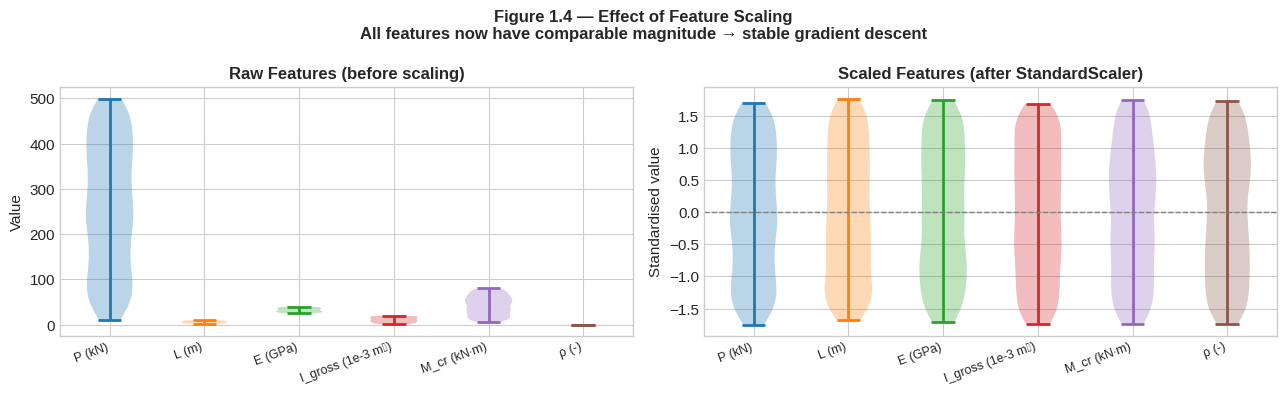

In [39]:
# ─── Train / val / test split ─────────────────────────────────────────────────
X_tr, X_tmp, y_tr, y_tmp = train_test_split(
    X_beam, y_beam, test_size=0.30, random_state=SEED)
X_val, X_te, y_val, y_te = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=SEED)

print(f"📊 Split: train={len(X_tr)}  val={len(X_val)}  test={len(X_te)}")

# ─── Scaling ──────────────────────────────────────────────────────────────────
scaler_X = StandardScaler()
X_tr_s  = scaler_X.fit_transform(X_tr)    # fit on train only
X_val_s = scaler_X.transform(X_val)
X_te_s  = scaler_X.transform(X_te)

# Scale target too (improves convergence)
y_mean_tr, y_std_tr = y_tr.mean(), y_tr.std()
y_tr_s  = (y_tr  - y_mean_tr) / y_std_tr
y_val_s = (y_val - y_mean_tr) / y_std_tr
y_te_s  = (y_te  - y_mean_tr) / y_std_tr

print("✅ Features normalised (StandardScaler fit on train)")
print(f"   Target scaled: mean={y_mean_tr:.2f} mm, std={y_std_tr:.2f} mm")

if TORCH_OK:
    # ── PyTorch DataLoaders ────────────────────────────────────────────────────
    def make_loader(X, y, batch_size=64, shuffle=True):
        ds = TensorDataset(torch.FloatTensor(X), torch.FloatTensor(y))
        return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

    train_loader_fnn = make_loader(X_tr_s,  y_tr_s,  shuffle=True)
    val_loader_fnn   = make_loader(X_val_s, y_val_s, shuffle=False)
    test_loader_fnn  = make_loader(X_te_s,  y_te_s,  shuffle=False)

    print(f"   DataLoaders: {len(train_loader_fnn)} train batches, "
          f"{len(val_loader_fnn)} val batches")

# Visualise scaling effect
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for i in range(X_tr.shape[1]):
    axes[0].violinplot(X_tr[:, i], positions=[i])
    axes[1].violinplot(X_tr_s[:, i], positions=[i])

axes[0].set_xticks(range(6))
axes[0].set_xticklabels(meta_beam['feature_names'], rotation=20, ha='right', fontsize=9)
axes[0].set_title('Raw Features (before scaling)', fontsize=12)
axes[0].set_ylabel('Value', fontsize=11)

axes[1].set_xticks(range(6))
axes[1].set_xticklabels(meta_beam['feature_names'], rotation=20, ha='right', fontsize=9)
axes[1].set_title('Scaled Features (after StandardScaler)', fontsize=12)
axes[1].set_ylabel('Standardised value', fontsize=11)
axes[1].axhline(0, color='gray', ls='--', lw=1)

plt.suptitle('Figure 1.4 — Effect of Feature Scaling\n'
             'All features now have comparable magnitude → stable gradient descent',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 1.5 Model Architecture: BeamFNN

A 4-layer feedforward network:
```
Input (6) → Dense(128) → ReLU → Dense(64) → ReLU → Dense(32) → ReLU → Output (1)
```
The architecture is parametric — depth and width can be changed easily.
We use He initialisation (built into PyTorch's default for Linear layers with ReLU).

In [40]:
if TORCH_OK:
    class BeamFNN(nn.Module):
        """
        Feedforward neural network for RC beam deflection regression.

        Architecture: Linear → ReLU stack, configurable depth & width.
        Output: single scalar (deflection, normalised).
        """
        def __init__(self, n_features=6, hidden_dims=(128, 64, 32),
                     dropout=0.0, use_bn=False):
            super().__init__()
            layers = []
            in_dim = n_features
            for h in hidden_dims:
                layers.append(nn.Linear(in_dim, h))
                if use_bn:
                    layers.append(nn.BatchNorm1d(h))
                layers.append(nn.ReLU())
                if dropout > 0:
                    layers.append(nn.Dropout(dropout))
                in_dim = h
            layers.append(nn.Linear(in_dim, 1))
            self.net = nn.Sequential(*layers)

        def forward(self, x):
            return self.net(x).squeeze(-1)

    def count_params(model):
        return sum(p.numel() for p in model.parameters() if p.requires_grad)

    beam_model = BeamFNN(n_features=6, hidden_dims=(128, 64, 32), dropout=0.0)
    beam_model  = beam_model.to(DEVICE)

    n_params = count_params(beam_model)
    print(f"🔧 BeamFNN Architecture:")
    print(f"   Layers : 6 → 128 → 64 → 32 → 1")
    print(f"   Params : {n_params:,}")
    print(f"   Device : {DEVICE}")
    print()
    print("   Layer Details:")
    for name, module in beam_model.named_modules():
        if isinstance(module, (nn.Linear, nn.ReLU, nn.Dropout, nn.BatchNorm1d)):
            if isinstance(module, nn.Linear):
                print(f"   {name:<20s}: Linear({module.in_features} → {module.out_features})"
                      f"  params={module.in_features*module.out_features + module.out_features:,}")
            else:
                print(f"   {name:<20s}: {module.__class__.__name__}")

🔧 BeamFNN Architecture:
   Layers : 6 → 128 → 64 → 32 → 1
   Params : 11,265
   Device : cuda

   Layer Details:
   net.0               : Linear(6 → 128)  params=896
   net.1               : ReLU
   net.2               : Linear(128 → 64)  params=8,256
   net.3               : ReLU
   net.4               : Linear(64 → 32)  params=2,080
   net.5               : ReLU
   net.6               : Linear(32 → 1)  params=33


### 1.6 Training Loop — Explicit 4-Step Pattern

The **universal deep learning training recipe** applied to beam deflection:

```
for each epoch:
    ① model.train()                         # enable dropout/BN training mode
    ② for each batch:
         optimizer.zero_grad()              # reset accumulated gradients
         y_pred = model(X_batch)            # forward pass
         loss   = criterion(y_pred, y_true) # compute loss
         loss.backward()                    # backpropagate gradients
         optimizer.step()                   # update weights
    ③ model.eval() + torch.no_grad()        # validation phase
    ④ log train & val metrics
```

In [41]:
if TORCH_OK:
    # ── Hyperparameters ────────────────────────────────────────────────────────
    LR_BEAM     = 1e-3
    WD_BEAM     = 1e-4
    PATIENCE    = 15       # early stopping patience

    criterion_fnn = nn.MSELoss()
    optimizer_fnn = optim.Adam(beam_model.parameters(), lr=LR_BEAM,
                                weight_decay=WD_BEAM)
    scheduler_fnn = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_fnn, patience=5, factor=0.5, min_lr=1e-6)

    logger_fnn  = TrainingLogger('Beam Deflection FNN', 'RMSE', 'mm')
    fnn_history = {'train_rmse': [], 'val_rmse': [], 'lr': []}

    best_val_loss = float('inf')
    best_state    = None
    patience_ctr  = 0

    for epoch in range(1, N_EPOCHS_FNN + 1):
        # ── Training phase ────────────────────────────────────────────────────
        beam_model.train()
        train_loss_sum = 0.0
        for X_b, y_b in train_loader_fnn:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            optimizer_fnn.zero_grad()              # ① zero gradients
            y_pred = beam_model(X_b)               # ② forward pass
            loss   = criterion_fnn(y_pred, y_b)   # ③ compute loss
            loss.backward()                        # ④a backpropagate
            optimizer_fnn.step()                   # ④b update weights
            train_loss_sum += loss.item() * len(y_b)

        train_mse = train_loss_sum / len(train_loader_fnn.dataset)

        # ── Validation phase ──────────────────────────────────────────────────
        beam_model.eval()
        val_loss_sum = 0.0
        with torch.no_grad():
            for X_b, y_b in val_loader_fnn:
                X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
                y_pred = beam_model(X_b)
                val_loss_sum += criterion_fnn(y_pred, y_b).item() * len(y_b)
        val_mse = val_loss_sum / len(val_loader_fnn.dataset)

        # Convert normalised MSE → physical RMSE in mm
        train_rmse = np.sqrt(train_mse) * y_std_tr
        val_rmse   = np.sqrt(val_mse)   * y_std_tr

        current_lr = optimizer_fnn.param_groups[0]['lr']
        scheduler_fnn.step(val_mse)

        fnn_history['train_rmse'].append(train_rmse)
        fnn_history['val_rmse'].append(val_rmse)
        fnn_history['lr'].append(current_lr)

        logger_fnn.log_epoch(epoch, N_EPOCHS_FNN, train_rmse, val_rmse,
                             lr=current_lr, log_every=max(1, N_EPOCHS_FNN // 5))

        # Early stopping
        if val_mse < best_val_loss:
            best_val_loss = val_mse
            best_state    = copy.deepcopy(beam_model.state_dict())
            patience_ctr  = 0
        else:
            patience_ctr += 1
            if patience_ctr >= PATIENCE:
                print(f"   ⏹  Early stopping at epoch {epoch} (patience={PATIENCE})")
                break

    # Restore best weights
    beam_model.load_state_dict(best_state)
    logger_fnn.summary()


════════════════════════════════════════════════════════════════════════
   Beam Deflection FNN — Training Log
════════════════════════════════════════════════════════════════════════
   Epoch   1/80 │ Train RMSE:   36.939 mm │ Val RMSE:   34.408 mm │ LR: 1.00e-03 │ 0.1s ★
   Epoch  16/80 │ Train RMSE:   10.016 mm │ Val RMSE:   11.340 mm │ LR: 1.00e-03 │ 0.8s
   Epoch  32/80 │ Train RMSE:    8.663 mm │ Val RMSE:   10.586 mm │ LR: 1.00e-03 │ 1.6s
   ⏹  Early stopping at epoch 41 (patience=15)
────────────────────────────────────────────────────────────────────────
   ✅ Training complete in 2.1s
   Best val RMSE: 10.2128 mm @ epoch 26/41
════════════════════════════════════════════════════════════════════════



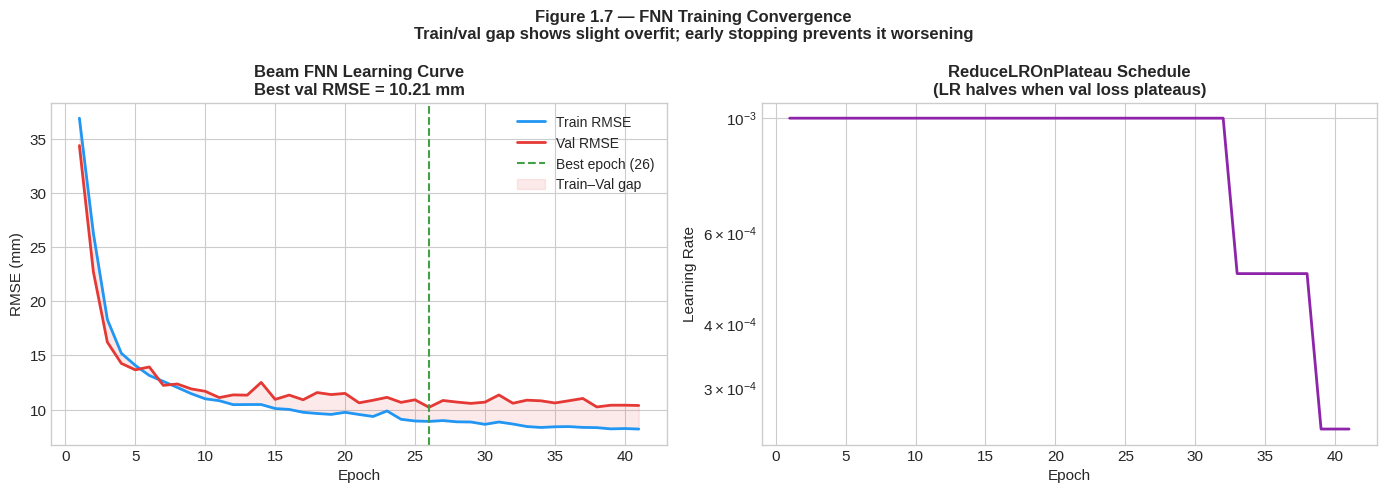

In [42]:
# ─── Figure 1.7: Training convergence ─────────────────────────────────────────
if TORCH_OK:
    epochs_ran = range(1, len(fnn_history['train_rmse']) + 1)
    best_ep    = np.argmin(fnn_history['val_rmse']) + 1
    best_rmse  = min(fnn_history['val_rmse'])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: RMSE curves
    axes[0].plot(epochs_ran, fnn_history['train_rmse'],
                 color=C_BLUE, lw=2, label='Train RMSE')
    axes[0].plot(epochs_ran, fnn_history['val_rmse'],
                 color=C_RED,  lw=2, label='Val RMSE')
    axes[0].axvline(best_ep, color=C_GREEN, lw=1.5, ls='--',
                    label=f'Best epoch ({best_ep})')
    axes[0].fill_between(epochs_ran, fnn_history['train_rmse'],
                         fnn_history['val_rmse'], alpha=0.1, color=C_RED,
                         label='Train–Val gap')
    axes[0].set_xlabel('Epoch', fontsize=11)
    axes[0].set_ylabel('RMSE (mm)', fontsize=11)
    axes[0].set_title(f'Beam FNN Learning Curve\nBest val RMSE = {best_rmse:.2f} mm',
                      fontsize=12)
    axes[0].legend(fontsize=10)

    # Right: Learning rate schedule
    axes[1].semilogy(epochs_ran, fnn_history['lr'], color=C_PURPLE, lw=2)
    axes[1].set_xlabel('Epoch', fontsize=11)
    axes[1].set_ylabel('Learning Rate', fontsize=11)
    axes[1].set_title('ReduceLROnPlateau Schedule\n(LR halves when val loss plateaus)',
                      fontsize=12)

    plt.suptitle('Figure 1.7 — FNN Training Convergence\n'
                 'Train/val gap shows slight overfit; early stopping prevents it worsening',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

### 1.8 Evaluation — Prediction Quality

Three evaluation tools:
1. **Predicted vs True scatter** — should lie on the 1:1 diagonal
2. **Residual plot** — should be random (no systematic error)
3. **Error by cracking state** — model may struggle in the post-crack nonlinear regime

────────────────────────────────────────────────────────────────────────
   ✅ Training complete in 2.8s
   Best val RMSE: 10.2128 mm @ epoch 26/41

   📈 Test Metrics:
      RMSE                  : 11.86 mm
      MAE                   : 8.62 mm
      R²                    : 0.9293
      Max error             : 58.02 mm
════════════════════════════════════════════════════════════════════════



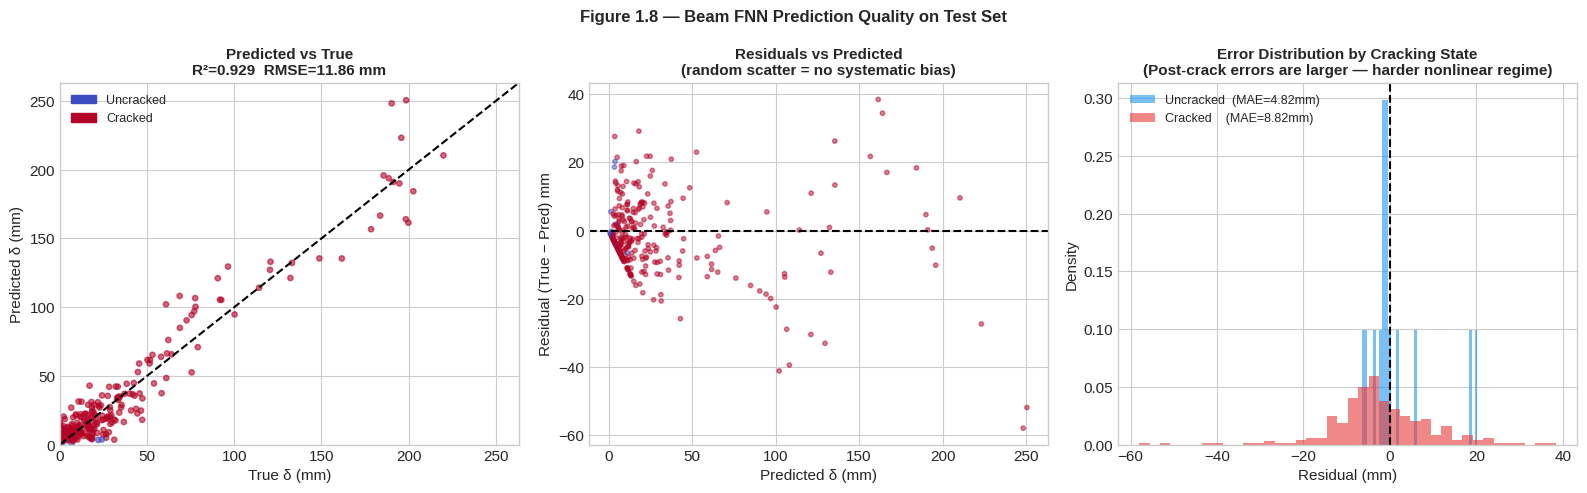

In [43]:
if TORCH_OK:
    # ── Get test-set predictions ───────────────────────────────────────────────
    beam_model.eval()
    y_pred_list = []
    with torch.no_grad():
        for X_b, _ in test_loader_fnn:
            y_pred_list.append(beam_model(X_b.to(DEVICE)).cpu().numpy())
    y_pred_s = np.concatenate(y_pred_list)

    # Inverse-normalise back to mm
    y_pred_mm = y_pred_s * y_std_tr + y_mean_tr
    y_true_mm = y_te

    # ── Metrics ───────────────────────────────────────────────────────────────
    rmse_test = np.sqrt(mean_squared_error(y_true_mm, y_pred_mm))
    mae_test  = mean_absolute_error(y_true_mm, y_pred_mm)
    r2_test   = r2_score(y_true_mm, y_pred_mm)
    max_err   = np.abs(y_true_mm - y_pred_mm).max()

    logger_fnn.summary(test_metrics={
        'RMSE            ': f'{rmse_test:.2f} mm',
        'MAE             ': f'{mae_test:.2f} mm',
        'R²              ': f'{r2_test:.4f}',
        'Max error       ': f'{max_err:.2f} mm',
    })

    # ── Figure 1.8a: Scatter ──────────────────────────────────────────────────
    # Split by cracking state in test set
    X_tr_tmp, X_te_tmp, _, cracked_te = train_test_split(
        X_beam, meta_beam['cracked'], test_size=0.30, random_state=SEED)
    _, cracked_te = train_test_split(cracked_te, test_size=0.50, random_state=SEED)

    lims = [0, max(y_true_mm.max(), y_pred_mm.max()) * 1.05]

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    sc = axes[0].scatter(y_true_mm, y_pred_mm, c=cracked_te,
                         cmap='coolwarm', s=15, alpha=0.6)
    axes[0].plot(lims, lims, 'k--', lw=1.5, label='1:1 line')
    axes[0].set_xlim(lims); axes[0].set_ylim(lims)
    axes[0].set_xlabel('True δ (mm)', fontsize=11)
    axes[0].set_ylabel('Predicted δ (mm)', fontsize=11)
    axes[0].set_title(f'Predicted vs True\nR²={r2_test:.3f}  RMSE={rmse_test:.2f} mm',
                      fontsize=11)
    axes[0].legend(fontsize=9)
    handles = [mpatches.Patch(color=plt.cm.coolwarm(0.0), label='Uncracked'),
               mpatches.Patch(color=plt.cm.coolwarm(1.0), label='Cracked')]
    axes[0].legend(handles=handles, fontsize=9)

    # Residuals vs predicted
    residuals = y_true_mm - y_pred_mm
    axes[1].scatter(y_pred_mm, residuals, c=cracked_te, cmap='coolwarm',
                    s=10, alpha=0.5)
    axes[1].axhline(0, color='black', lw=1.5, ls='--')
    axes[1].set_xlabel('Predicted δ (mm)', fontsize=11)
    axes[1].set_ylabel('Residual (True − Pred) mm', fontsize=11)
    axes[1].set_title('Residuals vs Predicted\n(random scatter = no systematic bias)',
                      fontsize=11)

    # Error distribution
    axes[2].hist(residuals[cracked_te == 0], bins=40, alpha=0.6,
                 color=C_BLUE, label=f'Uncracked  (MAE={np.abs(residuals[cracked_te==0]).mean():.2f}mm)', density=True)
    axes[2].hist(residuals[cracked_te == 1], bins=40, alpha=0.6,
                 color=C_RED, label=f'Cracked    (MAE={np.abs(residuals[cracked_te==1]).mean():.2f}mm)', density=True)
    axes[2].axvline(0, color='k', lw=1.5, ls='--')
    axes[2].set_xlabel('Residual (mm)', fontsize=11)
    axes[2].set_ylabel('Density', fontsize=11)
    axes[2].set_title('Error Distribution by Cracking State\n'
                      '(Post-crack errors are larger — harder nonlinear regime)',
                      fontsize=11)
    axes[2].legend(fontsize=9)

    plt.suptitle('Figure 1.8 — Beam FNN Prediction Quality on Test Set',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

### 1.9 Feature Importance via Input Perturbation

**Method:** Perturb each input feature ±1σ while holding others fixed.
Measure how much the predicted deflection changes.
The feature that causes the largest output change is most important.

**Expected result:** L (span) should dominate — because δ ∝ L³.

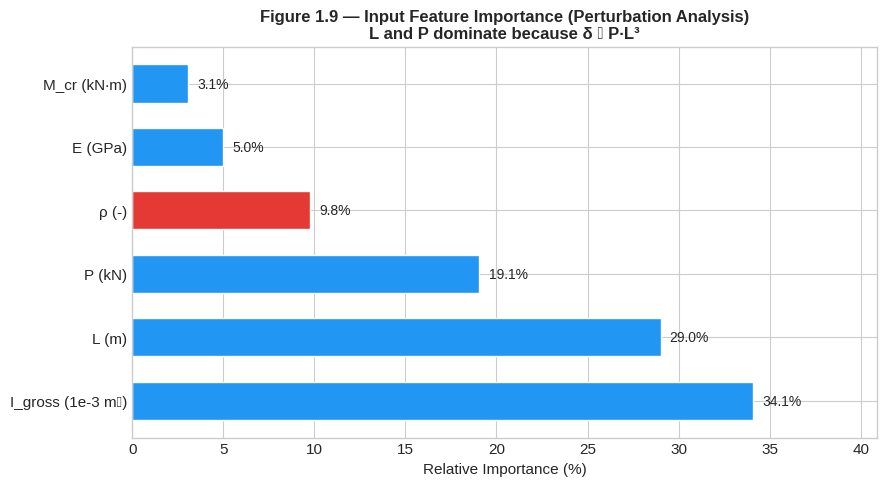


🔍 Feature Importance Ranking:
   #1: I_gross (1e-3 m⁴)         34.1%
   #2: L (m)                     29.0%
   #3: P (kN)                    19.1%
   #4: ρ (-)                     9.8%
   #5: E (GPa)                   5.0%
   #6: M_cr (kN·m)               3.1%

   💡 L (span) is 11.1× more important than ρ — consistent with δ ∝ L³


In [44]:
if TORCH_OK:
    beam_model.eval()
    importance = np.zeros(6)
    X_ref = torch.FloatTensor(X_val_s[:200]).to(DEVICE)
    base_pred = beam_model(X_ref).detach().cpu().numpy()

    for feat_idx in range(6):
        X_pert_pos = X_ref.clone()
        X_pert_neg = X_ref.clone()
        X_pert_pos[:, feat_idx] += 1.0   # +1 std
        X_pert_neg[:, feat_idx] -= 1.0   # -1 std
        pred_pos = beam_model(X_pert_pos).detach().cpu().numpy()
        pred_neg = beam_model(X_pert_neg).detach().cpu().numpy()
        importance[feat_idx] = np.abs(pred_pos - base_pred).mean() + \
                                np.abs(pred_neg - base_pred).mean()

    # Normalise to percentage
    importance_pct = importance / importance.sum() * 100
    order = np.argsort(importance_pct)[::-1]

    fig, ax = plt.subplots(figsize=(9, 5))
    colours_fi = [C_RED if i == order[0] else C_BLUE for i in range(6)]
    bars = ax.barh(
        [meta_beam['feature_names'][i] for i in order],
        importance_pct[order],
        color=[colours_fi[list(order).index(i)] for i in order],
        edgecolor='white', height=0.6
    )
    for bar, val in zip(bars, importance_pct[order]):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}%', va='center', fontsize=10)
    ax.set_xlabel('Relative Importance (%)', fontsize=11)
    ax.set_title('Figure 1.9 — Input Feature Importance (Perturbation Analysis)\n'
                 'L and P dominate because δ ∝ P·L³', fontsize=12)
    ax.set_xlim(0, importance_pct.max() * 1.2)
    plt.tight_layout()
    plt.show()

    print("\n🔍 Feature Importance Ranking:")
    for rank, i in enumerate(order):
        print(f"   #{rank+1}: {meta_beam['feature_names'][i]:<25s} {importance_pct[i]:.1f}%")
    print(f"\n   💡 L (span) is {importance_pct[order[0]]/importance_pct[order[-1]]:.1f}× more important"
          f" than ρ — consistent with δ ∝ L³")

### 1.10 Overfitting Experiment & Regularisation

**Setup:** Intentionally overfit by using a tiny dataset (n=100) with a large model.
Then apply three cures and compare.

**Cures tested:**
1. L2 weight decay (Adam's `weight_decay` parameter)
2. Dropout (p=0.3 on hidden layers)
3. Both combined

🔬 Running regularisation experiment (4 configurations)...
   Training: No Reg ...
   → Final val RMSE: 19.28 mm
   Training: L2 Weight Decay ...
   → Final val RMSE: 18.14 mm
   Training: Dropout (p=0.3) ...
   → Final val RMSE: 23.22 mm
   Training: L2 + Dropout ...
   → Final val RMSE: 18.98 mm


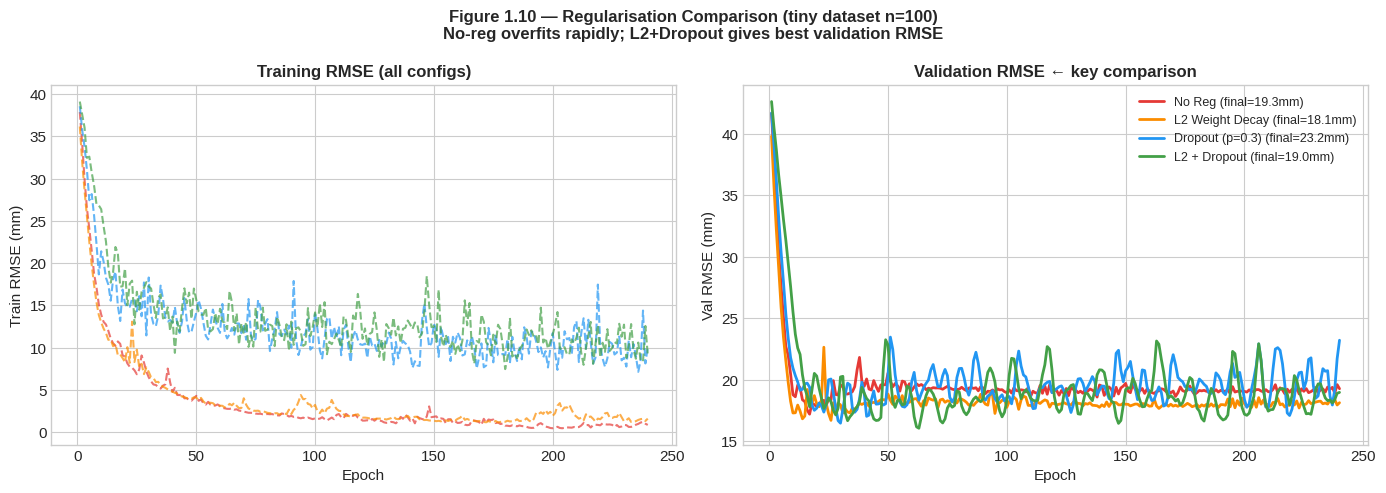


📊 Final Val RMSE comparison:
   Config                     Final Val RMSE
   ────────────────────────────────────────
   No Reg                           19.28 mm
   L2 Weight Decay                  18.14 mm ← best
   Dropout (p=0.3)                  23.22 mm
   L2 + Dropout                     18.98 mm


In [45]:
if TORCH_OK:
    N_TINY   = 100
    EPOCHS_R = max(N_EPOCHS_FNN * 3, 30)  # train longer to see overfit

    # Tiny training set (first 100 samples)
    X_tiny = X_tr_s[:N_TINY]
    y_tiny = y_tr_s[:N_TINY]
    dl_tiny = make_loader(X_tiny, y_tiny, batch_size=32, shuffle=True)

    def train_fnn_config(name, dropout=0.0, wd=0.0, use_bn=False, n_epochs=EPOCHS_R):
        mdl  = BeamFNN(hidden_dims=(256, 128, 64), dropout=dropout, use_bn=use_bn).to(DEVICE)
        opt  = optim.Adam(mdl.parameters(), lr=1e-3, weight_decay=wd)
        crit = nn.MSELoss()
        tr_hist, vl_hist = [], []
        for ep in range(1, n_epochs + 1):
            mdl.train()
            for Xb, yb in dl_tiny:
                Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
                opt.zero_grad()
                loss = crit(mdl(Xb), yb)
                loss.backward()
                opt.step()
            train_l = crit(mdl(torch.FloatTensor(X_tiny).to(DEVICE)),
                           torch.FloatTensor(y_tiny).to(DEVICE)).item()
            mdl.eval()
            with torch.no_grad():
                val_l = crit(mdl(torch.FloatTensor(X_val_s).to(DEVICE)),
                             torch.FloatTensor(y_val_s).to(DEVICE)).item()
            tr_hist.append(np.sqrt(train_l) * y_std_tr)
            vl_hist.append(np.sqrt(val_l)   * y_std_tr)
        return tr_hist, vl_hist

    print("🔬 Running regularisation experiment (4 configurations)...")
    configs = [
        ('No Reg',           0.0,  0.0),
        ('L2 Weight Decay',  0.0,  1e-3),
        ('Dropout (p=0.3)',  0.3,  0.0),
        ('L2 + Dropout',     0.3,  1e-3),
    ]
    results_reg = {}
    for name, do, wd in configs:
        print(f"   Training: {name} ...")
        tr, vl = train_fnn_config(name, dropout=do, wd=wd)
        results_reg[name] = (tr, vl)
        print(f"   → Final val RMSE: {vl[-1]:.2f} mm")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    cols = [C_RED, C_ORANGE, C_BLUE, C_GREEN]
    ep_r = range(1, EPOCHS_R + 1)

    for (name, (tr, vl)), col in zip(results_reg.items(), cols):
        axes[0].plot(ep_r, tr, color=col, ls='--', lw=1.5, alpha=0.7)
        axes[1].plot(ep_r, vl, color=col, lw=2, label=f'{name} (final={vl[-1]:.1f}mm)')

    axes[0].set_title('Training RMSE (all configs)', fontsize=12)
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Train RMSE (mm)')
    axes[1].set_title('Validation RMSE ← key comparison', fontsize=12)
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Val RMSE (mm)')
    axes[1].legend(fontsize=9)

    plt.suptitle(f'Figure 1.10 — Regularisation Comparison (tiny dataset n={N_TINY})\n'
                 'No-reg overfits rapidly; L2+Dropout gives best validation RMSE',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Summary table
    print("\n📊 Final Val RMSE comparison:")
    print(f"   {'Config':<25s} {'Final Val RMSE':>15s}")
    print(f"   {'─'*40}")
    for name, (_, vl) in results_reg.items():
        marker = " ← best" if vl[-1] == min(v[-1] for _,v in results_reg.values()) else ""
        print(f"   {name:<25s} {vl[-1]:>12.2f} mm{marker}")

---
## Part 2: Convolutional Neural Networks for Concrete Crack Detection

### 2.1 Motivation & Context

**Civil Engineering Context:**
Manual inspection of concrete infrastructure (bridges, pavements, buildings) is slow,
expensive, and inconsistent.  A trained CNN on drone/camera imagery can flag cracks
at scale — automating the first-pass triage.

**Why CNN over FNN?**
- A crack is a *spatially local* pattern: the same linear feature can appear anywhere
- CNNs use **shared weights** (filters slide across the image) — exploit translation invariance
- A FNN on flattened pixels (64×64 = 4096 inputs) would need 10× more parameters and
  would not generalise to cracks in different locations

**Task:** Binary classification — Cracked (1) vs Uncracked (0)

**Dataset:** Procedurally generated synthetic concrete images (64×64 pixels, grayscale)
with five crack morphologies:
1. Linear transverse crack (flexural failure)
2. Diagonal shear crack (45° from corner)
3. Hairline surface crack (thin, long)
4. Branching / dendritic crack (fatigue)
5. Wide structural crack (thick edges)

In [46]:
# ─── Helper: Bresenham line drawing ──────────────────────────────────────────

def _draw_line(start, end, img_size):
    """Return (rows, cols) pixel coordinates for a line (Bresenham simplified)."""
    y0, x0 = int(np.clip(start[0], 0, img_size-1)), int(np.clip(start[1], 0, img_size-1))
    y1, x1 = int(np.clip(end[0],   0, img_size-1)), int(np.clip(end[1],   0, img_size-1))
    n_pts   = max(abs(y1 - y0), abs(x1 - x0)) + 1
    rows    = np.linspace(y0, y1, n_pts).astype(int)
    cols    = np.linspace(x0, x1, n_pts).astype(int)
    rows    = np.clip(rows, 0, img_size - 1)
    cols    = np.clip(cols, 0, img_size - 1)
    return rows, cols


def _add_concrete_texture(img_size, rng):
    """Generate a realistic concrete surface texture (H×W, float32 in [0,1])."""
    # Granular base
    base    = rng.uniform(0.45, 0.75, (img_size, img_size)).astype(np.float32)
    # Add aggregate blobs (dark circular inclusions)
    n_agg   = rng.integers(5, 15)
    for _ in range(n_agg):
        cy, cx = rng.integers(2, img_size - 2, size=2)
        r      = rng.integers(1, 4)
        yy, xx = np.ogrid[:img_size, :img_size]
        mask   = (yy - cy)**2 + (xx - cx)**2 <= r**2
        base[mask] *= rng.uniform(0.5, 0.85)
    # Fine grain noise
    base += rng.normal(0, 0.04, (img_size, img_size)).astype(np.float32)
    return np.clip(base, 0.0, 1.0)


def generate_crack_dataset(n_per_class=100, img_size=64, random_state=42):
    """
    Generate synthetic concrete crack detection images.

    Crack morphologies (5 types):
        0: Linear transverse (flexural crack)
        1: Diagonal shear crack (45°)
        2: Hairline surface crack (thin + long)
        3: Branching / dendritic (fatigue)
        4: Wide structural crack (thick edges)

    Returns
    -------
    images : (2*n_per_class, img_size, img_size) float32, [0,1], grayscale
    labels : (2*n_per_class,)  int64  — 0=uncracked, 1=cracked
    meta   : dict
    """
    rng    = np.random.default_rng(random_state)
    N      = n_per_class * 2
    images = np.zeros((N, img_size, img_size), dtype=np.float32)
    labels = np.zeros(N, dtype=np.int64)
    crack_types = []

    for i in range(N):
        img = _add_concrete_texture(img_size, rng)

        if i < n_per_class:
            # ── Uncracked class ───────────────────────────────────────────────
            labels[i] = 0
            crack_types.append('none')
            # Slight brightness variation only
            img *= rng.uniform(0.85, 1.05)
        else:
            # ── Cracked class — pick morphology ───────────────────────────────
            labels[i]  = 1
            morph_idx  = (i - n_per_class) % 5

            if morph_idx == 0:
                # Linear transverse crack
                crack_types.append('transverse')
                x_start = rng.integers(5, img_size - 5)
                y_start = rng.integers(5, img_size // 3)
                x_end   = x_start + rng.integers(-10, 10)
                y_end   = img_size - rng.integers(5, img_size // 3)
                rr, cc  = _draw_line((y_start, x_start), (y_end, x_end), img_size)
                img[rr, cc] *= rng.uniform(0.15, 0.35)
                # Add crack shadow (width)
                for dr in [-1, 1]:
                    rr2 = np.clip(rr + dr, 0, img_size - 1)
                    img[rr2, cc] *= rng.uniform(0.5, 0.75)

            elif morph_idx == 1:
                # Diagonal shear crack
                crack_types.append('diagonal')
                if rng.random() > 0.5:
                    start = (rng.integers(0, img_size//3), rng.integers(0, img_size//3))
                    end   = (rng.integers(2*img_size//3, img_size),
                             rng.integers(2*img_size//3, img_size))
                else:
                    start = (rng.integers(0, img_size//3),
                             rng.integers(2*img_size//3, img_size))
                    end   = (rng.integers(2*img_size//3, img_size),
                             rng.integers(0, img_size//3))
                rr, cc  = _draw_line(start, end, img_size)
                img[rr, cc] *= rng.uniform(0.2, 0.4)

            elif morph_idx == 2:
                # Hairline crack (thin, meandering)
                crack_types.append('hairline')
                pts_y = np.sort(rng.integers(2, img_size - 2, size=6))
                pts_x = rng.integers(img_size // 4, 3 * img_size // 4, size=6)
                for k in range(len(pts_y) - 1):
                    rr, cc = _draw_line((pts_y[k], pts_x[k]),
                                        (pts_y[k+1], pts_x[k+1]), img_size)
                    img[rr, cc] *= rng.uniform(0.45, 0.65)  # lighter than structural

            elif morph_idx == 3:
                # Branching / dendritic crack
                crack_types.append('branching')
                # Main crack
                sy, sx = rng.integers(5, img_size//3), rng.integers(img_size//4, 3*img_size//4)
                ey, ex = rng.integers(2*img_size//3, img_size-5), rng.integers(img_size//4, 3*img_size//4)
                rr, cc = _draw_line((sy, sx), (ey, ex), img_size)
                img[rr, cc] *= rng.uniform(0.2, 0.35)
                # Branches
                n_branches = rng.integers(2, 5)
                for _ in range(n_branches):
                    branch_idx = rng.integers(len(rr))
                    bsy, bsx   = rr[branch_idx], cc[branch_idx]
                    bey = int(bsy + rng.integers(-img_size//5, img_size//5))
                    bex = int(bsx + rng.integers(-img_size//5, img_size//5))
                    brr, bcc   = _draw_line((bsy, bsx), (bey, bex), img_size)
                    img[brr, bcc] *= rng.uniform(0.3, 0.5)

            else:
                # Wide structural crack
                crack_types.append('wide')
                sy, sx = rng.integers(5, 20), rng.integers(10, img_size - 10)
                ey, ex = img_size - rng.integers(5, 20), rng.integers(10, img_size - 10)
                for offset in range(-2, 3):
                    sx_off = int(np.clip(sx + offset, 0, img_size - 1))
                    ex_off = int(np.clip(ex + offset, 0, img_size - 1))
                    rr, cc = _draw_line((sy, sx_off), (ey, ex_off), img_size)
                    img[rr, cc] *= rng.uniform(0.15, 0.4)

            # Add moisture staining near crack (optional)
            if rng.random() > 0.6:
                stain = np.zeros_like(img)
                stain[img < 0.35] = rng.uniform(0.05, 0.15)
                img = np.clip(img + stain * 0.3, 0, 1)

        images[i] = np.clip(img, 0.0, 1.0)

    meta = {
        'class_names' : ['Uncracked', 'Cracked'],
        'n_classes'   : 2,
        'img_size'    : img_size,
        'crack_types' : crack_types,
        'morphologies': ['transverse', 'diagonal', 'hairline', 'branching', 'wide'],
        'n_per_class' : n_per_class,
    }
    return images, labels, meta


# ─── Generate data ─────────────────────────────────────────────────────────────
print("=" * 72)
print("  PART 2: CNN FOR CONCRETE CRACK DETECTION")
print("=" * 72)

images_crack, labels_crack, meta_crack = generate_crack_dataset(
    n_per_class=N_CRACK_PER_CLASS, img_size=64, random_state=SEED)

N_CRACK = len(labels_crack)
print(f"\n📊 Dataset summary:")
print(f"   Total images  : {N_CRACK}")
print(f"   Image size    : {meta_crack['img_size']}×{meta_crack['img_size']} (grayscale)")
print(f"   Uncracked     : {(labels_crack==0).sum()}")
print(f"   Cracked       : {(labels_crack==1).sum()}")
print(f"   Pixel range   : [{images_crack.min():.3f}, {images_crack.max():.3f}]")
print(f"   Mean intensity: uncracked={images_crack[labels_crack==0].mean():.3f}, "
      f"cracked={images_crack[labels_crack==1].mean():.3f}")

  PART 2: CNN FOR CONCRETE CRACK DETECTION

📊 Dataset summary:
   Total images  : 400
   Image size    : 64×64 (grayscale)
   Uncracked     : 200
   Cracked       : 200
   Pixel range   : [0.020, 0.924]
   Mean intensity: uncracked=0.563, cracked=0.585


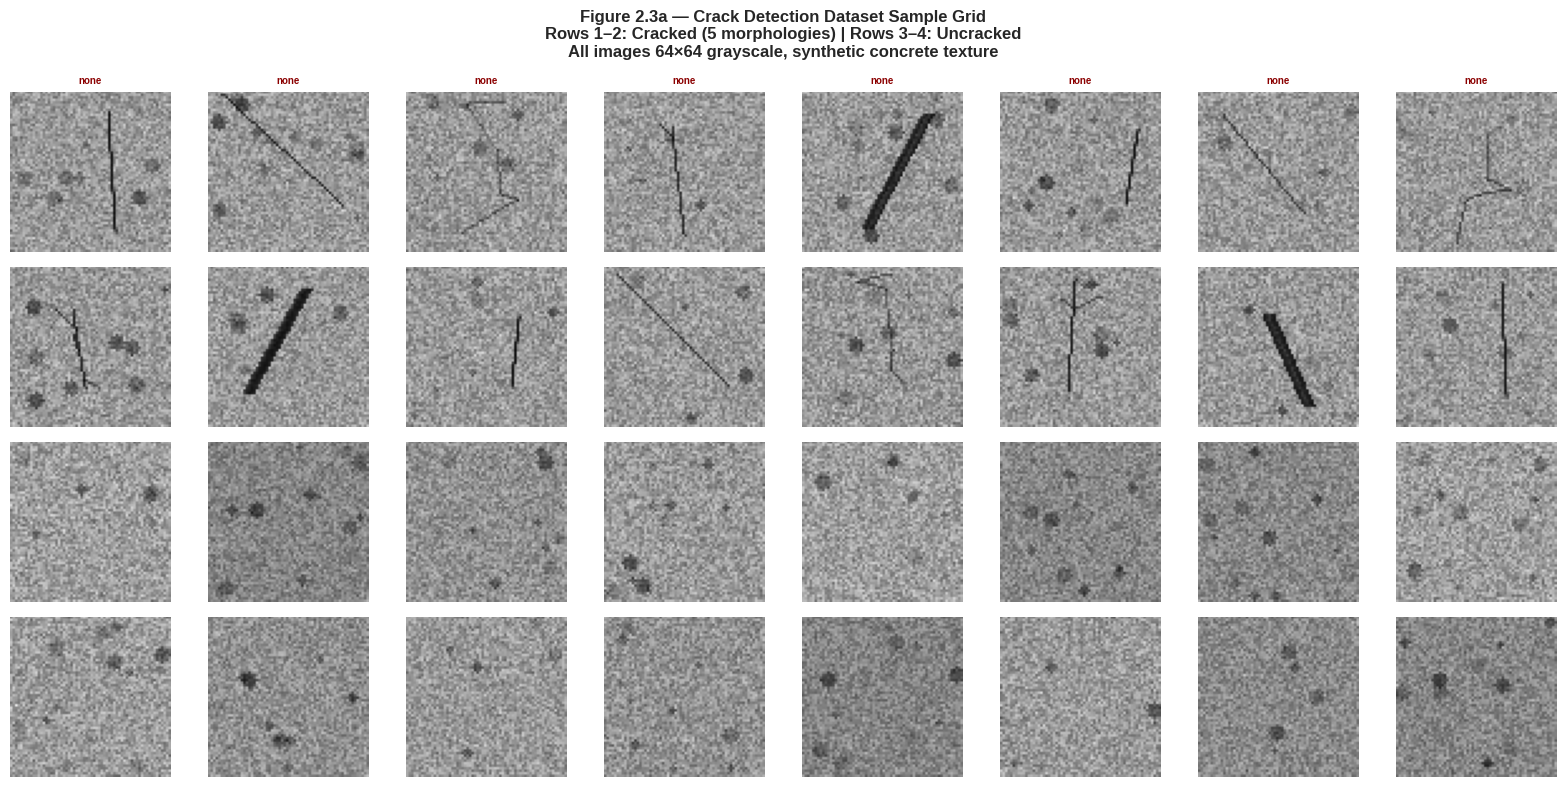

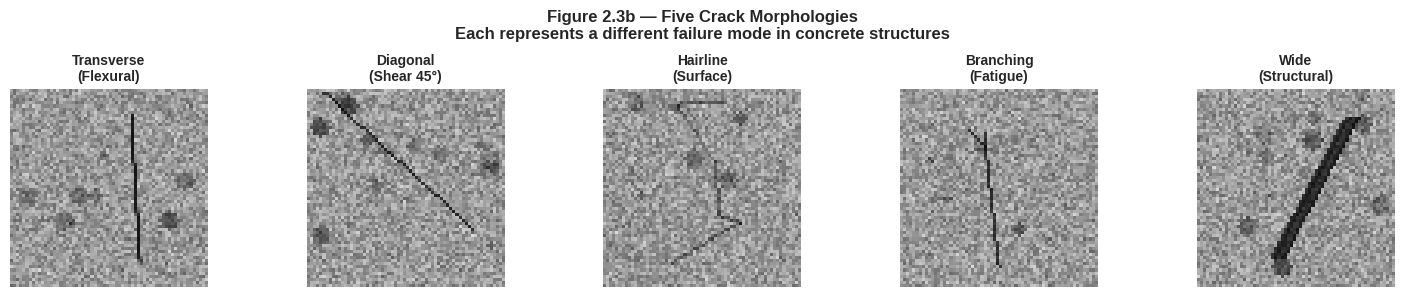

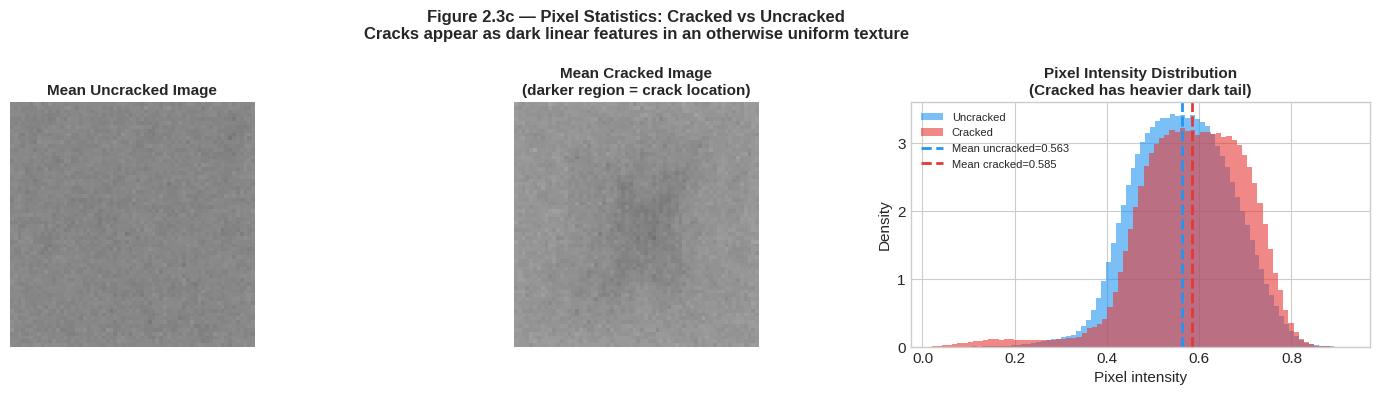

In [47]:
# ─── Figure 2.3a: Sample image grid (4 rows × 8 cols) ────────────────────────
fig, axes = plt.subplots(4, 8, figsize=(16, 8))

# Top 2 rows: cracked; bottom 2 rows: uncracked
cracked_idx   = np.where(labels_crack == 1)[0]
uncracked_idx = np.where(labels_crack == 0)[0]

for col in range(8):
    for row in range(2):
        idx = cracked_idx[row * 8 + col]
        axes[row][col].imshow(images_crack[idx], cmap='gray', vmin=0, vmax=1)
        axes[row][col].axis('off')
        if row == 0:
            ct = meta_crack['crack_types'][idx - N_CRACK_PER_CLASS] if idx >= N_CRACK_PER_CLASS else ''
            axes[row][col].set_title(ct, fontsize=7, color='darkred')
        for spine in axes[row][col].spines.values():
            spine.set_edgecolor(C_RED)
            spine.set_linewidth(2)
            spine.set_visible(True)
        axes[row][col].patch.set_edgecolor(C_RED)
        axes[row][col].patch.set_linewidth(2)

    for row in range(2, 4):
        idx = uncracked_idx[(row - 2) * 8 + col]
        axes[row][col].imshow(images_crack[idx], cmap='gray', vmin=0, vmax=1)
        axes[row][col].axis('off')

axes[0][0].set_ylabel('CRACKED', fontsize=9, color=C_RED, labelpad=40)
axes[2][0].set_ylabel('UNCRACKED', fontsize=9, color=C_BLUE, labelpad=40)

plt.suptitle('Figure 2.3a — Crack Detection Dataset Sample Grid\n'
             'Rows 1–2: Cracked (5 morphologies) | Rows 3–4: Uncracked\n'
             'All images 64×64 grayscale, synthetic concrete texture',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ─── Figure 2.3b: Morphology gallery ─────────────────────────────────────────
morph_labels = {
    'transverse': 'Transverse\n(Flexural)',
    'diagonal'  : 'Diagonal\n(Shear 45°)',
    'hairline'  : 'Hairline\n(Surface)',
    'branching' : 'Branching\n(Fatigue)',
    'wide'      : 'Wide\n(Structural)',
}

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
crack_type_arr = np.array(meta_crack['crack_types'])
for ax, morph in zip(axes, meta_crack['morphologies']):
    morph_mask = np.where(crack_type_arr == morph)[0]
    if len(morph_mask) > 0:
        # Original line: img_idx = np.where(labels_crack == 1)[0][morph_mask[0]]
        # Corrected line: morph_mask already contains original indices of cracked images for the given morphology.
        img_idx = morph_mask[0]
        ax.imshow(images_crack[img_idx], cmap='gray', vmin=0, vmax=1)
        ax.set_title(morph_labels[morph], fontsize=10, fontweight='bold')
    ax.axis('off')

plt.suptitle('Figure 2.3b — Five Crack Morphologies\n'
             'Each represents a different failure mode in concrete structures',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ─── Figure 2.3c: Pixel statistics ───────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Mean image per class
mean_cracked    = images_crack[labels_crack == 1].mean(axis=0)
mean_uncracked  = images_crack[labels_crack == 0].mean(axis=0)

axes[0].imshow(mean_uncracked, cmap='gray', vmin=0.3, vmax=0.8)
axes[0].set_title('Mean Uncracked Image', fontsize=11)
axes[0].axis('off')

axes[1].imshow(mean_cracked, cmap='gray', vmin=0.3, vmax=0.8)
axes[1].set_title('Mean Cracked Image\n(darker region = crack location)', fontsize=11)
axes[1].axis('off')

# Pixel intensity histograms
axes[2].hist(images_crack[labels_crack == 0].flatten(), bins=80, alpha=0.6,
             color=C_BLUE, density=True, label='Uncracked')
axes[2].hist(images_crack[labels_crack == 1].flatten(), bins=80, alpha=0.6,
             color=C_RED,  density=True, label='Cracked')
axes[2].axvline(images_crack[labels_crack==0].mean(), color=C_BLUE,
                lw=2, ls='--', label=f"Mean uncracked={images_crack[labels_crack==0].mean():.3f}")
axes[2].axvline(images_crack[labels_crack==1].mean(), color=C_RED,
                lw=2, ls='--', label=f"Mean cracked={images_crack[labels_crack==1].mean():.3f}")
axes[2].set_xlabel('Pixel intensity', fontsize=11)
axes[2].set_ylabel('Density', fontsize=11)
axes[2].set_title('Pixel Intensity Distribution\n(Cracked has heavier dark tail)', fontsize=11)
axes[2].legend(fontsize=8)

plt.suptitle('Figure 2.3c — Pixel Statistics: Cracked vs Uncracked\n'
             'Cracks appear as dark linear features in an otherwise uniform texture',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.4 CNN Architecture

```
Input (1 × 64 × 64)
    ↓  Conv2d(1→16, 3×3, pad=1) → BatchNorm → ReLU → MaxPool(2×2)    → (16, 32, 32)
    ↓  Conv2d(16→32, 3×3, pad=1) → BatchNorm → ReLU → MaxPool(2×2)   → (32, 16, 16)
    ↓  Conv2d(32→64, 3×3, pad=1) → BatchNorm → ReLU → MaxPool(2×2)   → (64, 8, 8)
    ↓  AdaptiveAvgPool2d(1×1)                                         → (64, 1, 1)
    ↓  Flatten → Linear(64→32) → ReLU → Dropout(0.3) → Linear(32→2)
Output (2 logits: uncracked / cracked)
```

**Parameter count comparison:**
- FNN on flattened 64×64: 4096 × 256 = 1,048,576 params (first layer alone!)
- This CNN: ~35,000 total — 30× fewer, and spatially aware

In [48]:
if TORCH_OK:
    class CrackDetectionCNN(nn.Module):
        """
        Lightweight CNN for binary crack classification.

        Uses BatchNorm for training stability and GlobalAvgPool to reduce
        spatial dimensions (more robust than a large FC layer).
        """
        def __init__(self, n_classes=2, dropout=0.3):
            super().__init__()
            self.features = nn.Sequential(
                nn.Conv2d(1, 16, kernel_size=3, padding=1),
                nn.BatchNorm2d(16), nn.ReLU(),
                nn.MaxPool2d(2),                                       # 32×32

                nn.Conv2d(16, 32, kernel_size=3, padding=1),
                nn.BatchNorm2d(32), nn.ReLU(),
                nn.MaxPool2d(2),                                       # 16×16

                nn.Conv2d(32, 64, kernel_size=3, padding=1),
                nn.BatchNorm2d(64), nn.ReLU(),
                nn.MaxPool2d(2),                                       # 8×8
            )
            self.pool       = nn.AdaptiveAvgPool2d(1)                  # 1×1
            self.classifier = nn.Sequential(
                nn.Flatten(),
                nn.Linear(64, 32), nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(32, n_classes),
            )

        def forward(self, x):
            feat = self.features(x)
            feat = self.pool(feat)
            return self.classifier(feat)

        def get_feature_maps(self, x, layer_idx=0):
            """Return feature maps after a specified conv block."""
            x = x
            for i, layer in enumerate(self.features):
                x = layer(x)
                if isinstance(layer, nn.MaxPool2d) and i // 3 == layer_idx:
                    return x
            return x

    crack_model = CrackDetectionCNN(n_classes=2, dropout=0.3).to(DEVICE)
    n_params_cnn = count_params(crack_model)

    print(f"🔧 CrackDetectionCNN Architecture:")
    print(f"   Input  : 1 × 64 × 64")
    print(f"   Conv1  : 16 filters → 16 × 32 × 32  (after pool)")
    print(f"   Conv2  : 32 filters → 32 × 16 × 16  (after pool)")
    print(f"   Conv3  : 64 filters → 64 × 8 × 8    (after pool)")
    print(f"   GAP    : 64 × 1 × 1")
    print(f"   FC     : 64 → 32 → 2")
    print(f"   Params : {n_params_cnn:,}")

    # Receptive field at each layer (3×3 conv, stride 1, pool stride 2)
    print(f"\n   Receptive field growth:")
    print(f"   After Conv1: 3×3")
    print(f"   After Conv2: 10×10 (sees ~15% of image width)")
    print(f"   After Conv3: 26×26 (sees ~40% of image width)")
    print(f"\n   FNN baseline: 4096 → 256 = {4096*256+256:,} params (first layer alone)")
    print(f"   Savings: {(4096*256+256)/n_params_cnn:.1f}× fewer parameters")

🔧 CrackDetectionCNN Architecture:
   Input  : 1 × 64 × 64
   Conv1  : 16 filters → 16 × 32 × 32  (after pool)
   Conv2  : 32 filters → 32 × 16 × 16  (after pool)
   Conv3  : 64 filters → 64 × 8 × 8    (after pool)
   GAP    : 64 × 1 × 1
   FC     : 64 → 32 → 2
   Params : 25,666

   Receptive field growth:
   After Conv1: 3×3
   After Conv2: 10×10 (sees ~15% of image width)
   After Conv3: 26×26 (sees ~40% of image width)

   FNN baseline: 4096 → 256 = 1,048,832 params (first layer alone)
   Savings: 40.9× fewer parameters


### 2.5 CNN Training Loop

Same 4-step recipe as the FNN — only the data format and loss function differ:
- Input tensors: `(batch, 1, 64, 64)` — images with channel dimension
- Loss: `CrossEntropyLoss` — combines softmax + NLL for multi-class problems
- `model.train()` / `model.eval()` — critical for BatchNorm behaviour

We monitor both **loss** and **accuracy** per epoch.

In [49]:
if TORCH_OK:
    class CrackDataset(Dataset):
        """Custom Dataset with optional on-the-fly augmentation."""
        def __init__(self, images, labels, augment=False, rng_seed=0):
            self.images  = images.astype(np.float32)   # (N, H, W)
            self.labels  = labels.astype(np.int64)
            self.augment = augment
            self.rng     = np.random.default_rng(rng_seed)

        def __len__(self):
            return len(self.labels)

        def __getitem__(self, idx):
            img   = self.images[idx].copy()
            label = self.labels[idx]
            if self.augment:
                if self.rng.random() > 0.5:
                    img = np.fliplr(img)
                if self.rng.random() > 0.5:
                    img = np.flipud(img)
                img = img * self.rng.uniform(0.85, 1.15)
                img = img + self.rng.normal(0, 0.025, img.shape).astype(np.float32)
                img = np.clip(img, 0.0, 1.0)
            # (H, W) → (1, H, W) channel-first for PyTorch
            img_t   = torch.FloatTensor(img).unsqueeze(0)
            lbl_t   = torch.tensor(label, dtype=torch.long)
            return img_t, lbl_t

    # ── Split: 70% train, 15% val, 15% test ──────────────────────────────────
    n_train_c = int(N_CRACK * 0.70)
    n_val_c   = int(N_CRACK * 0.15)
    n_test_c  = N_CRACK - n_train_c - n_val_c

    # Stratified split (keep class balance)
    all_idx     = np.arange(N_CRACK)
    idx_tr_c, idx_tmp_c = train_test_split(all_idx, test_size=0.30,
                                            stratify=labels_crack, random_state=SEED)
    idx_val_c, idx_te_c = train_test_split(idx_tmp_c, test_size=0.50,
                                            stratify=labels_crack[idx_tmp_c], random_state=SEED)

    train_ds_cnn = CrackDataset(images_crack[idx_tr_c],  labels_crack[idx_tr_c],  augment=False)
    val_ds_cnn   = CrackDataset(images_crack[idx_val_c], labels_crack[idx_val_c], augment=False)
    test_ds_cnn  = CrackDataset(images_crack[idx_te_c],  labels_crack[idx_te_c],  augment=False)

    train_dl_cnn = DataLoader(train_ds_cnn, batch_size=16, shuffle=True,  num_workers=0)
    val_dl_cnn   = DataLoader(val_ds_cnn,   batch_size=16, shuffle=False, num_workers=0)
    test_dl_cnn  = DataLoader(test_ds_cnn,  batch_size=16, shuffle=False, num_workers=0)

    print(f"📊 CNN Data split: train={len(train_ds_cnn)}  val={len(val_ds_cnn)}  test={len(test_ds_cnn)}")
    print(f"   Train batches: {len(train_dl_cnn)}   Val batches: {len(val_dl_cnn)}")

    # ── Training ─────────────────────────────────────────────────────────────
    criterion_cnn = nn.CrossEntropyLoss()
    optimizer_cnn = optim.Adam(crack_model.parameters(), lr=1e-3, weight_decay=1e-4)
    scheduler_cnn = optim.lr_scheduler.CosineAnnealingLR(
        optimizer_cnn, T_max=N_EPOCHS_CNN, eta_min=1e-5)

    logger_cnn = TrainingLogger('Crack Detection CNN', 'Acc', '%', lower_is_better=False)
    cnn_history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    best_val_acc  = 0.0
    best_cnn_state = None

    def evaluate_cnn(model, loader):
        model.eval()
        total_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for Xb, yb in loader:
                Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
                logits  = model(Xb)
                total_loss += criterion_cnn(logits, yb).item() * len(yb)
                correct    += (logits.argmax(1) == yb).sum().item()
                total      += len(yb)
        return total_loss / total, correct / total * 100

    for epoch in range(1, N_EPOCHS_CNN + 1):
        # ── Train ─────────────────────────────────────────────────────────────
        crack_model.train()
        ep_loss, ep_correct, ep_total = 0.0, 0, 0
        for Xb, yb in train_dl_cnn:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            optimizer_cnn.zero_grad()                  # ① zero gradients
            logits = crack_model(Xb)                   # ② forward pass
            loss   = criterion_cnn(logits, yb)         # ③ compute loss
            loss.backward()                            # ④a backpropagate
            optimizer_cnn.step()                       # ④b update weights
            ep_loss    += loss.item() * len(yb)
            ep_correct += (logits.argmax(1) == yb).sum().item()
            ep_total   += len(yb)
        train_loss = ep_loss / ep_total
        train_acc  = ep_correct / ep_total * 100
        scheduler_cnn.step()

        # ── Validate ──────────────────────────────────────────────────────────
        val_loss, val_acc = evaluate_cnn(crack_model, val_dl_cnn)

        cnn_history['train_loss'].append(train_loss)
        cnn_history['val_loss'].append(val_loss)
        cnn_history['train_acc'].append(train_acc)
        cnn_history['val_acc'].append(val_acc)

        logger_cnn.log_epoch(epoch, N_EPOCHS_CNN, val_acc, val_acc,
                             lr=optimizer_cnn.param_groups[0]['lr'],
                             extras={'Loss': f'{val_loss:.4f}'},
                             log_every=max(1, N_EPOCHS_CNN // 5))

        if val_acc > best_val_acc:
            best_val_acc   = val_acc
            best_cnn_state = copy.deepcopy(crack_model.state_dict())

    crack_model.load_state_dict(best_cnn_state)
    test_loss, test_acc = evaluate_cnn(crack_model, test_dl_cnn)

    logger_cnn.summary(test_metrics={
        'Test Accuracy  ': f'{test_acc:.2f}%',
        'Test Loss      ': f'{test_loss:.4f}',
        'Best Val Acc   ': f'{best_val_acc:.2f}%',
    })

📊 CNN Data split: train=280  val=60  test=60
   Train batches: 18   Val batches: 4

════════════════════════════════════════════════════════════════════════
   Crack Detection CNN — Training Log
════════════════════════════════════════════════════════════════════════
   Epoch   1/40 │ Train Acc:   50.000 % │ Val Acc:   50.000 % │ LR: 9.98e-04 │ Loss: 0.8920 │ 0.1s ★
   Epoch   8/40 │ Train Acc:   98.333 % │ Val Acc:   98.333 % │ LR: 9.05e-04 │ Loss: 0.0933 │ 0.7s
   Epoch  16/40 │ Train Acc:   90.000 % │ Val Acc:   90.000 % │ LR: 6.58e-04 │ Loss: 0.2720 │ 1.3s
   Epoch  24/40 │ Train Acc:   81.667 % │ Val Acc:   81.667 % │ LR: 3.52e-04 │ Loss: 0.5005 │ 1.9s
   Epoch  32/40 │ Train Acc:  100.000 % │ Val Acc:  100.000 % │ LR: 1.05e-04 │ Loss: 0.0121 │ 2.6s
   Epoch  40/40 │ Train Acc:  100.000 % │ Val Acc:  100.000 % │ LR: 1.00e-05 │ Loss: 0.0112 │ 3.3s
────────────────────────────────────────────────────────────────────────
   ✅ Training complete in 3.3s
   Best val Acc: 100.0000 % @ ep

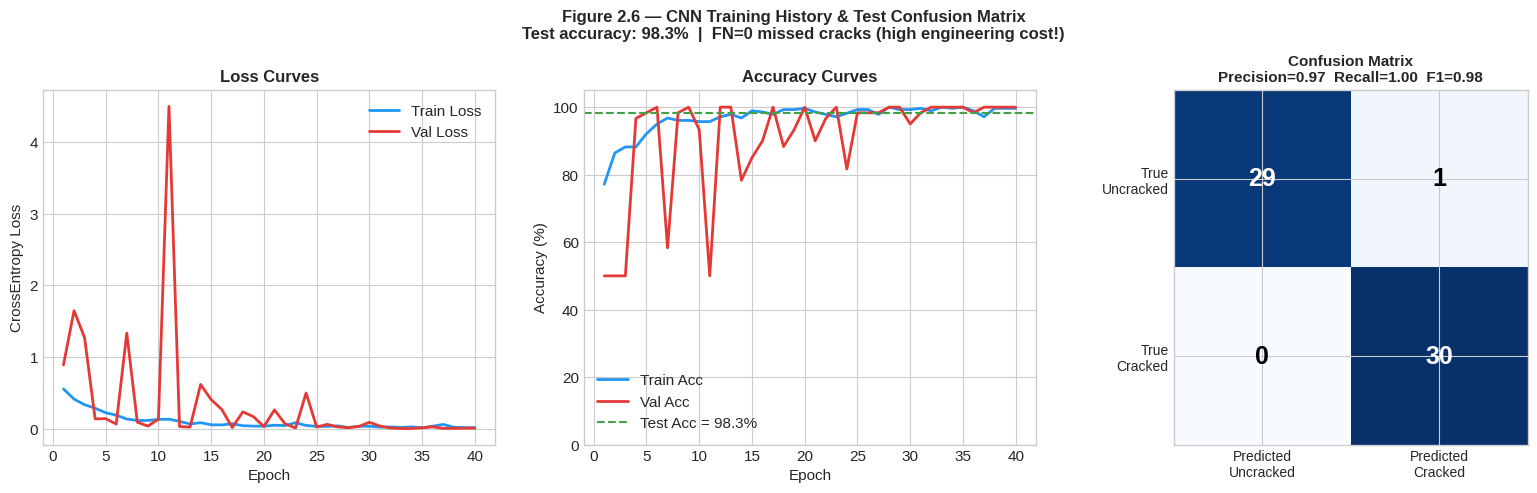


📋 Classification Report:
              precision    recall  f1-score   support

   Uncracked       1.00      0.97      0.98        30
     Cracked       0.97      1.00      0.98        30

    accuracy                           0.98        60
   macro avg       0.98      0.98      0.98        60
weighted avg       0.98      0.98      0.98        60

   ⚠️  False Negatives = 0 (missed cracks)
   In structural inspection: FN >> FP in cost (missed crack → structural risk)


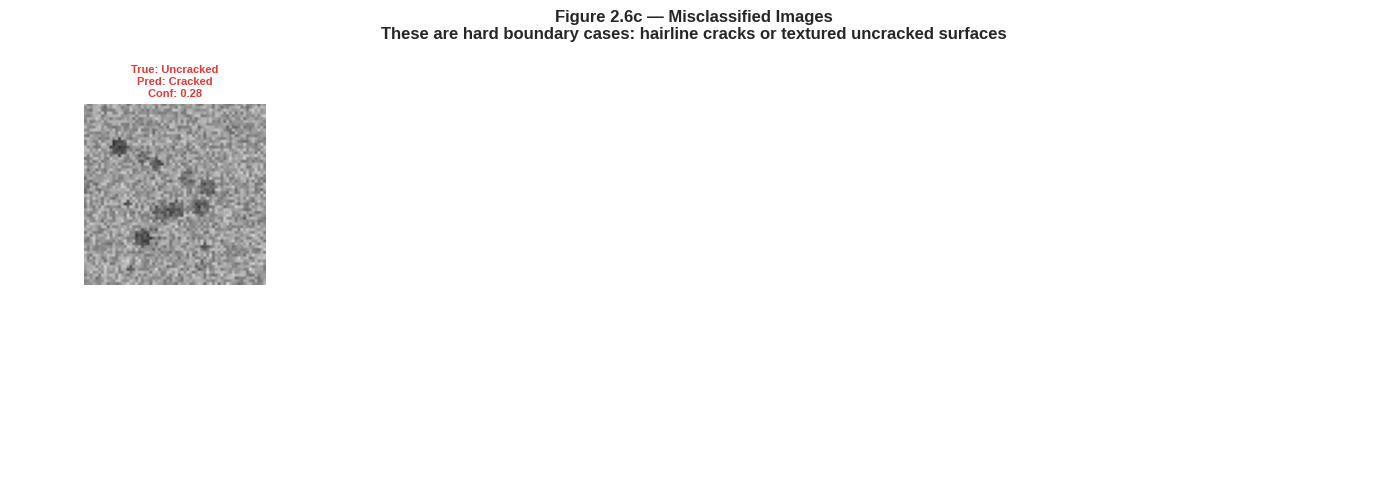

In [50]:
# ─── Figure 2.6a/b: Training curves + Confusion matrix ───────────────────────
if TORCH_OK:
    # Collect test predictions
    crack_model.eval()
    all_pred, all_true = [], []
    all_probs = []
    with torch.no_grad():
        for Xb, yb in test_dl_cnn:
            logits   = crack_model(Xb.to(DEVICE)).cpu()
            probs    = torch.softmax(logits, dim=1)[:, 1].numpy()
            pred     = logits.argmax(1).numpy()
            all_pred.extend(pred)
            all_true.extend(yb.numpy())
            all_probs.extend(probs)
    all_pred  = np.array(all_pred)
    all_true  = np.array(all_true)
    all_probs = np.array(all_probs)

    cm = confusion_matrix(all_true, all_pred)
    ep = range(1, N_EPOCHS_CNN + 1)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Loss curves
    axes[0].plot(ep, cnn_history['train_loss'], color=C_BLUE, lw=2, label='Train Loss')
    axes[0].plot(ep, cnn_history['val_loss'],   color=C_RED,  lw=2, label='Val Loss')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('CrossEntropy Loss')
    axes[0].set_title('Loss Curves', fontsize=12)
    axes[0].legend()

    # Accuracy curves
    axes[1].plot(ep, cnn_history['train_acc'], color=C_BLUE, lw=2, label='Train Acc')
    axes[1].plot(ep, cnn_history['val_acc'],   color=C_RED,  lw=2, label='Val Acc')
    axes[1].axhline(test_acc, color=C_GREEN, lw=1.5, ls='--',
                    label=f'Test Acc = {test_acc:.1f}%')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title('Accuracy Curves', fontsize=12)
    axes[1].legend(); axes[1].set_ylim(0, 105)

    # Confusion matrix
    im = axes[2].imshow(cm, cmap='Blues', interpolation='nearest')
    axes[2].set_xticks([0, 1]); axes[2].set_yticks([0, 1])
    axes[2].set_xticklabels(['Predicted\nUncracked', 'Predicted\nCracked'], fontsize=10)
    axes[2].set_yticklabels(['True\nUncracked', 'True\nCracked'], fontsize=10)
    for ii in range(2):
        for jj in range(2):
            axes[2].text(jj, ii, str(cm[ii, jj]),
                         ha='center', va='center', fontsize=18, fontweight='bold',
                         color='white' if cm[ii, jj] > cm.max() / 2 else 'black')
    tn, fp, fn, tp = cm.ravel()
    axes[2].set_title(f'Confusion Matrix\n'
                      f'Precision={tp/(tp+fp):.2f}  Recall={tp/(tp+fn):.2f}  F1={2*tp/(2*tp+fp+fn):.2f}',
                      fontsize=11)

    plt.suptitle('Figure 2.6 — CNN Training History & Test Confusion Matrix\n'
                 f'Test accuracy: {test_acc:.1f}%  |  '
                 f'FN={fn} missed cracks (high engineering cost!)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("\n📋 Classification Report:")
    print(classification_report(all_true, all_pred,
                                target_names=meta_crack['class_names']))
    print(f"   ⚠️  False Negatives = {fn} (missed cracks)")
    print(f"   In structural inspection: FN >> FP in cost (missed crack → structural risk)")

# ─── Figure 2.6c: Wrong predictions gallery ──────────────────────────────────
if TORCH_OK and len(all_pred) > 0:
    wrong_idx  = np.where(all_pred != all_true)[0]
    n_show     = min(len(wrong_idx), 8)

    if n_show > 0:
        fig, axes = plt.subplots(2, max(n_show, 4), figsize=(14, 5))
        for k in range(max(n_show, 4)):
            if k < n_show:
                idx  = idx_te_c[wrong_idx[k]]
                img  = images_crack[idx]
                true_lbl = meta_crack['class_names'][all_true[wrong_idx[k]]]
                pred_lbl = meta_crack['class_names'][all_pred[wrong_idx[k]]]
                conf     = all_probs[wrong_idx[k]] if all_true[wrong_idx[k]] == 1 \
                           else 1 - all_probs[wrong_idx[k]]
                axes[0][k].imshow(img, cmap='gray', vmin=0, vmax=1)
                axes[0][k].set_title(f'True: {true_lbl}\nPred: {pred_lbl}\n'
                                     f'Conf: {conf:.2f}', fontsize=8, color=C_RED)
                axes[0][k].axis('off')
            else:
                axes[0][k].axis('off')
                axes[1][k].axis('off')

        for k in range(n_show):
            axes[1][k].axis('off')
        plt.suptitle('Figure 2.6c — Misclassified Images\n'
                     'These are hard boundary cases: hairline cracks or textured uncracked surfaces',
                     fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()
    else:
        print("✅ Perfect classification on test set! (no wrong predictions to show)")

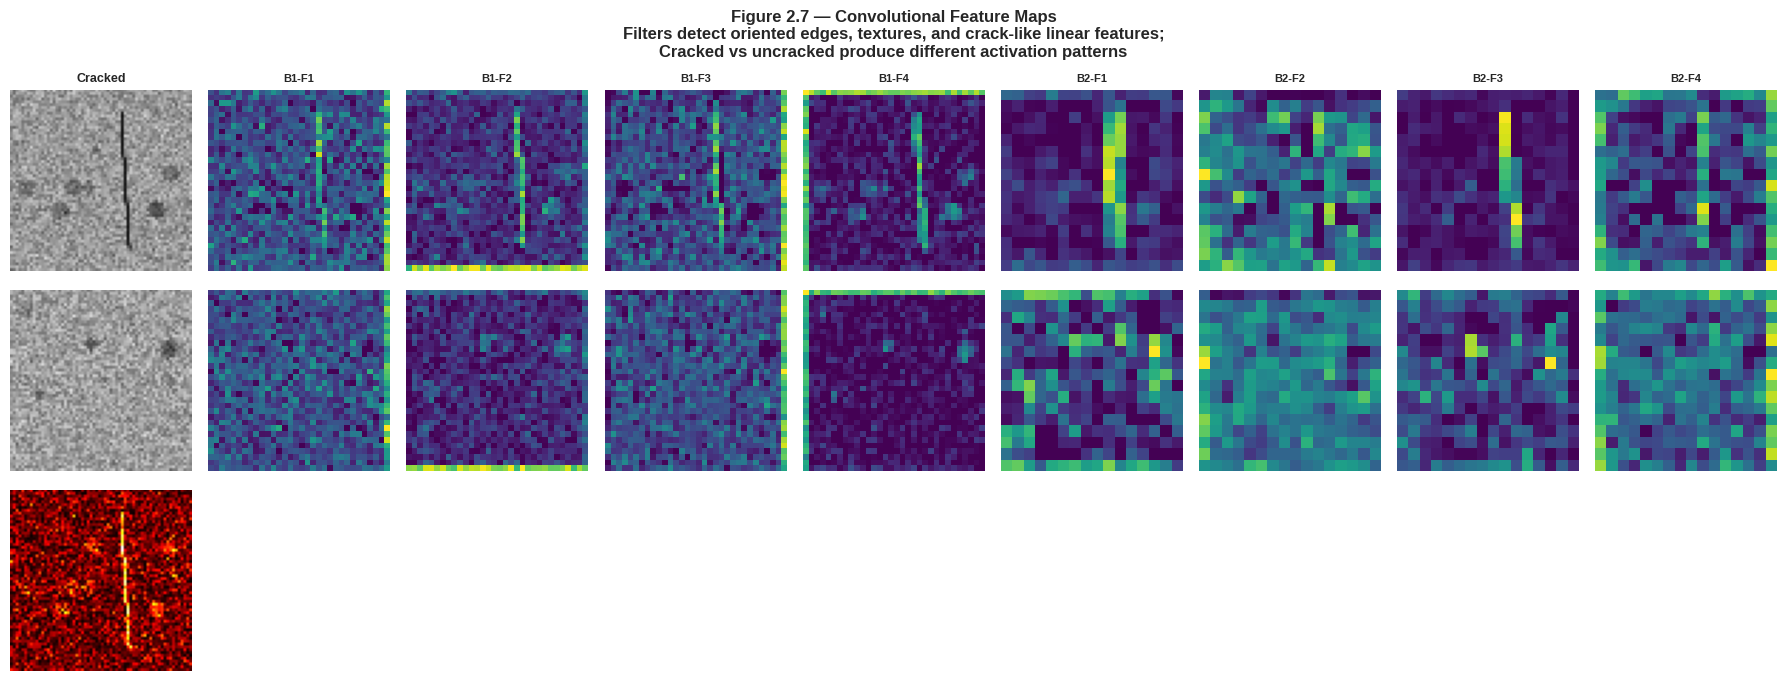

In [51]:
# ─── Figure 2.7: Feature map visualization ───────────────────────────────────
if TORCH_OK:
    # Select one cracked and one uncracked sample
    crack_model.eval()
    sample_cracked   = images_crack[np.where(labels_crack == 1)[0][0]]
    sample_uncracked = images_crack[np.where(labels_crack == 0)[0][0]]

    def get_conv_outputs(model, img_np):
        """Get outputs after each conv block."""
        img_t   = torch.FloatTensor(img_np).unsqueeze(0).unsqueeze(0).to(DEVICE)
        outputs = []
        x = img_t
        with torch.no_grad():
            for i, layer in enumerate(model.features):
                x = layer(x)
                if isinstance(layer, nn.MaxPool2d):
                    outputs.append(x.squeeze(0).cpu().numpy())
        return outputs

    feats_c  = get_conv_outputs(crack_model, sample_cracked)
    feats_nc = get_conv_outputs(crack_model, sample_uncracked)

    fig, axes = plt.subplots(3, 9, figsize=(18, 7))
    titles = ['Original', 'Block 1 (16 maps, 32×32)', 'Block 2 (32 maps, 16×16)']

    for row, (sample, feats, label) in enumerate([
            (sample_cracked,   feats_c,  'Cracked'),
            (sample_uncracked, feats_nc, 'Uncracked'),
            (sample_cracked - sample_uncracked, None, 'Difference')]):

        # Original image
        axes[row][0].imshow(sample if row < 2 else np.abs(sample_cracked - sample_uncracked),
                             cmap='gray' if row < 2 else 'hot', vmin=0, vmax=1 if row < 2 else None)
        axes[row][0].set_title(label if row == 0 else '', fontsize=9)
        axes[row][0].axis('off')
        if row == 0:
            axes[row][0].set_ylabel('Cracked', fontsize=9, color=C_RED)
        elif row == 1:
            axes[row][0].set_ylabel('Uncracked', fontsize=9, color=C_BLUE)

        if row < 2:
            # Block 1: show first 4 feature maps
            for k in range(4):
                axes[row][k+1].imshow(feats[0][k], cmap='viridis')
                axes[row][k+1].axis('off')
                if row == 0:
                    axes[row][k+1].set_title(f'B1-F{k+1}', fontsize=8)
            # Block 2: show first 4 feature maps
            for k in range(4):
                axes[row][k+5].imshow(feats[1][k], cmap='viridis')
                axes[row][k+5].axis('off')
                if row == 0:
                    axes[row][k+5].set_title(f'B2-F{k+1}', fontsize=8)
        else:
            for k in range(1, 9):
                axes[row][k].axis('off')

    plt.suptitle('Figure 2.7 — Convolutional Feature Maps\n'
                 'Filters detect oriented edges, textures, and crack-like linear features;\n'
                 'Cracked vs uncracked produce different activation patterns',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

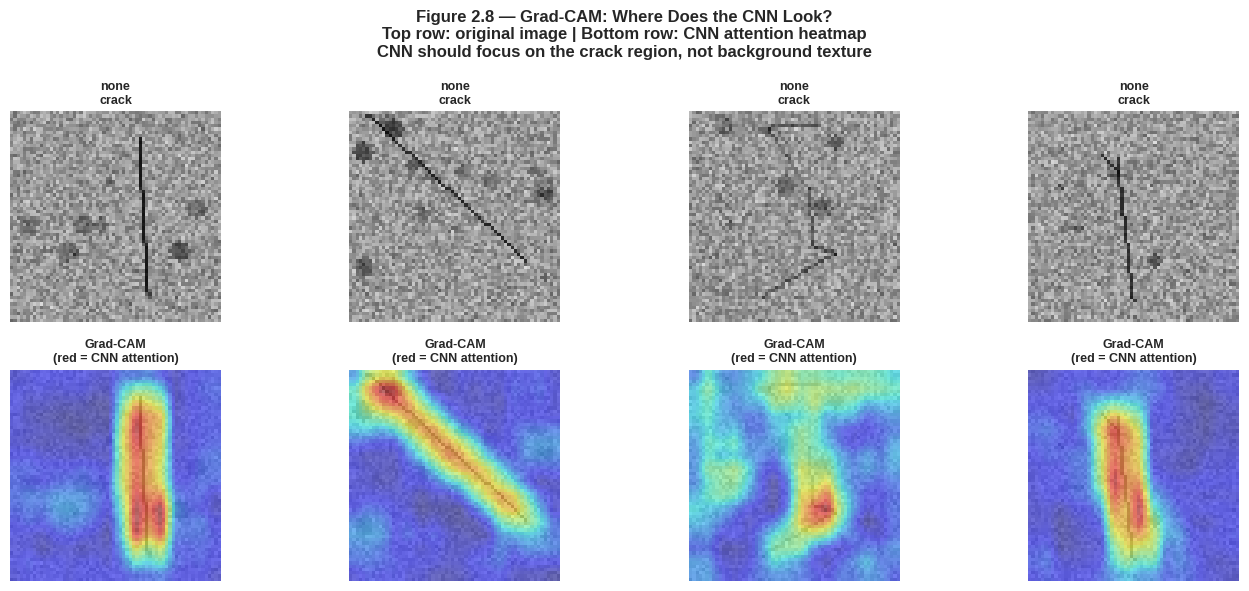

In [52]:
# ─── Grad-CAM: localise what the CNN "looks at" ──────────────────────────────
if TORCH_OK:
    def compute_gradcam(model, img_np, class_idx=1):
        """
        Compute Grad-CAM heatmap for the target class.

        Algorithm:
            1. Forward pass → capture last-conv activations
            2. Backward pass → capture gradients w.r.t. those activations
            3. Weight each feature map by its mean gradient (global average pool)
            4. ReLU the weighted sum → highlight discriminative regions
        """
        model.eval()
        activations, gradients = {}, {}

        # Hooks for capture
        def fwd_hook(module, inp, out):
            activations['feat'] = out.detach()

        def bwd_hook(module, gin, gout):
            gradients['feat'] = gout[0].detach()

        # Register on last conv layer (last Conv2d in features)
        last_conv = None
        for module in model.features.modules():
            if isinstance(module, nn.Conv2d):
                last_conv = module
        if last_conv is None:
            return None

        h1 = last_conv.register_forward_hook(fwd_hook)
        try:
            h2 = last_conv.register_full_backward_hook(bwd_hook)
        except AttributeError:
            h2 = last_conv.register_backward_hook(bwd_hook)

        img_t = torch.FloatTensor(img_np).unsqueeze(0).unsqueeze(0).to(DEVICE)
        img_t.requires_grad_(True)

        logits = model(img_t)
        model.zero_grad()
        logits[0, class_idx].backward()

        h1.remove(); h2.remove()

        act  = activations['feat'].squeeze(0).cpu().numpy()   # (C, H, W)
        grad = gradients['feat'].squeeze(0).cpu().numpy()

        # Global average pooling of gradients
        weights = grad.mean(axis=(1, 2), keepdims=True)       # (C, 1, 1)
        cam     = (weights * act).sum(axis=0)                  # (H, W)
        cam     = np.maximum(cam, 0)                           # ReLU

        # Resize to original image size
        from PIL import Image as PILImage
        cam_min, cam_max = cam.min(), cam.max()
        if cam_max > cam_min:
            cam = (cam - cam_min) / (cam_max - cam_min)
        cam_img = np.array(PILImage.fromarray(
            (cam * 255).astype(np.uint8)).resize((64, 64), PILImage.BILINEAR)) / 255.0
        return cam_img

    # Try PIL import; fall back to simple zoom if unavailable
    try:
        import PIL.Image
        PIL_OK = True
    except ImportError:
        PIL_OK = False

    if PIL_OK:
        # Show Grad-CAM for 4 cracked images
        cracked_samples = np.where(labels_crack == 1)[0][:4]

        fig, axes = plt.subplots(2, len(cracked_samples), figsize=(14, 6))
        for k, idx in enumerate(cracked_samples):
            img = images_crack[idx]
            cam = compute_gradcam(crack_model, img, class_idx=1)

            axes[0][k].imshow(img, cmap='gray', vmin=0, vmax=1)
            axes[0][k].set_title(f'{meta_crack["crack_types"][idx - N_CRACK_PER_CLASS]}\ncrack', fontsize=9)
            axes[0][k].axis('off')

            if cam is not None:
                axes[1][k].imshow(img, cmap='gray', vmin=0, vmax=1, alpha=0.6)
                axes[1][k].imshow(cam, cmap='jet', alpha=0.5, vmin=0, vmax=1)
            else:
                axes[1][k].imshow(img, cmap='gray', vmin=0, vmax=1)
            axes[1][k].set_title('Grad-CAM\n(red = CNN attention)', fontsize=9)
            axes[1][k].axis('off')

        plt.suptitle('Figure 2.8 — Grad-CAM: Where Does the CNN Look?\n'
                     'Top row: original image | Bottom row: CNN attention heatmap\n'
                     'CNN should focus on the crack region, not background texture',
                     fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()
    else:
        print("ℹ️  PIL not available — skipping Grad-CAM visualisation.")
        print("   Install with: pip install pillow")

🔬 Augmentation experiment: training with vs without augmentation...


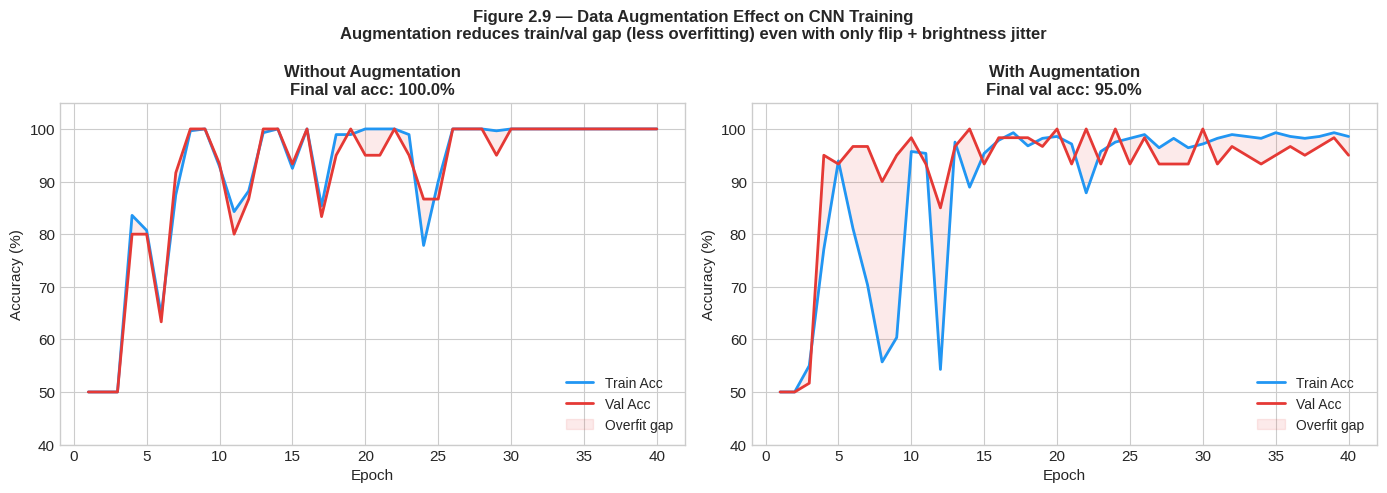


📊 Augmentation experiment results:
   Without augmentation: train=100.0%  val=100.0%  (gap=0.0%)
   With    augmentation: train=98.6%  val=95.0%  (gap=3.6%)


In [53]:
# ─── Figure 2.9: Data augmentation experiment ─────────────────────────────────
if TORCH_OK:
    print("🔬 Augmentation experiment: training with vs without augmentation...")

    def train_crack_cnn(augment=False, n_epochs=N_EPOCHS_CNN, seed=42):
        mdl   = CrackDetectionCNN(n_classes=2, dropout=0.3).to(DEVICE)
        opt   = optim.Adam(mdl.parameters(), lr=1e-3, weight_decay=1e-4)
        sched = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs, eta_min=1e-5)
        crit  = nn.CrossEntropyLoss()

        tr_ds = CrackDataset(images_crack[idx_tr_c], labels_crack[idx_tr_c],
                             augment=augment, rng_seed=seed)
        tr_dl = DataLoader(tr_ds, batch_size=16, shuffle=True, num_workers=0)

        tr_hist, vl_hist = [], []
        for ep in range(1, n_epochs + 1):
            mdl.train()
            for Xb, yb in tr_dl:
                Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
                opt.zero_grad()
                loss = crit(mdl(Xb), yb)
                loss.backward()
                opt.step()
            sched.step()
            mdl.eval()
            with torch.no_grad():
                tl, ta = evaluate_cnn(mdl, tr_dl)
                vl, va = evaluate_cnn(mdl, val_dl_cnn)
            tr_hist.append(ta); vl_hist.append(va)
        return tr_hist, vl_hist

    tr_no_aug, vl_no_aug = train_crack_cnn(augment=False)
    tr_aug,    vl_aug    = train_crack_cnn(augment=True)

    ep_aug = range(1, N_EPOCHS_CNN + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, tr, vl, title in [
            (axes[0], tr_no_aug, vl_no_aug, 'Without Augmentation'),
            (axes[1], tr_aug,    vl_aug,    'With Augmentation')]:
        ax.plot(ep_aug, tr, color=C_BLUE, lw=2, label=f'Train Acc')
        ax.plot(ep_aug, vl, color=C_RED,  lw=2, label=f'Val Acc')
        ax.fill_between(ep_aug, tr, vl, alpha=0.1, color=C_RED,
                        label='Overfit gap')
        ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
        ax.set_title(f'{title}\nFinal val acc: {vl[-1]:.1f}%', fontsize=12)
        ax.legend(fontsize=10); ax.set_ylim(40, 105)

    plt.suptitle('Figure 2.9 — Data Augmentation Effect on CNN Training\n'
                 'Augmentation reduces train/val gap (less overfitting) '
                 'even with only flip + brightness jitter',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print(f"\n📊 Augmentation experiment results:")
    print(f"   Without augmentation: train={tr_no_aug[-1]:.1f}%  val={vl_no_aug[-1]:.1f}%  "
          f"(gap={tr_no_aug[-1]-vl_no_aug[-1]:.1f}%)")
    print(f"   With    augmentation: train={tr_aug[-1]:.1f}%  val={vl_aug[-1]:.1f}%  "
          f"(gap={tr_aug[-1]-vl_aug[-1]:.1f}%)")

---
## Part 3: LSTM for Streamflow Forecasting

### 3.1 Motivation & Physics

**Civil Engineering Context:**
Streamflow forecasting is critical for:
- **Flood early warning** — 24–72 hour advance notice saves lives
- **Reservoir management** — schedule releases to prevent overflow
- **Irrigation planning** — allocate water during dry seasons

**Why LSTM over FNN or CNN?**
- Streamflow today depends on rainfall from the **past 10–30 days** — it has *memory*
- Soil moisture integrates antecedent rainfall: same storm on wet soil → 3× more runoff
- FNN ignores order and past; vanilla RNN forgets over long sequences (vanishing gradient)
- **LSTM** solves this with gated memory: the cell state $C_t$ carries long-range information

**Simplified Rainfall-Runoff Physics:**

$$Q_t = 0.85 \cdot Q_{t-1} + P_t \cdot \theta_t^{1.5} \cdot \epsilon_t$$

Where:
- $Q_t$ = streamflow [m³/s] (target)
- $P_t$ = daily rainfall [mm/day] (input)
- $\theta_t$ = soil moisture [0–1] (input, from bucket model)
- $\epsilon_t$ = random forcing factor
- $0.85$ = baseflow recession coefficient (84% of yesterday's flow carries over)

**Key rule for temporal data:** The train/val/test split must be **chronological**.
Never shuffle — future observations must never appear before past ones in training.

In [54]:
# ─── Inline dataset generator: Streamflow ─────────────────────────────────────

def generate_streamflow(n_days=365, noise_level=0.15, add_events=True, random_state=42):
    """
    Generate synthetic daily streamflow time series using a conceptual
    rainfall-runoff model.

    Features (3):
        Col 0: Rainfall      P_t   [mm/day]
        Col 1: Temperature   T_t   [°C]
        Col 2: Soil Moisture θ_t   [0–1]

    Target (1):
        Col 3: Streamflow    Q_t   [m³/s]

    Returns
    -------
    data     : (n_days, 4)  float32  — features + target stacked
    times    : (n_days,)    day index 0..n_days-1
    metadata : dict
    """
    rng = np.random.default_rng(random_state)
    t   = np.arange(n_days, dtype=float)

    # ── Rainfall P_t [mm/day] ──────────────────────────────────────────────────
    # Seasonal storm probability (higher in monsoon/winter)
    rain_prob = 0.20 + 0.12 * np.sin(2 * np.pi * t / 365)
    rain_mask = rng.random(n_days) < rain_prob
    rainfall  = np.where(rain_mask,
                         rng.exponential(scale=7.0, size=n_days), 0.0)
    rainfall  = gaussian_filter1d(rainfall, sigma=0.8)  # slight smoothing

    # Flash flood events (3–4 per year)
    if add_events and n_days >= 60:
        n_events  = max(2, int(n_days / 365 * 4))
        event_days = rng.integers(15, n_days - 15, size=n_events)
        for ed in event_days:
            duration  = rng.integers(1, 4)
            intensity = rng.uniform(30, 80)
            rainfall[ed:ed+duration] += intensity * np.linspace(1, 0.3, duration)

    rainfall = np.clip(rainfall, 0.0, None)

    # ── Temperature T_t [°C] ──────────────────────────────────────────────────
    # Annual sinusoidal cycle (summer peak)
    temperature = 22 + 10 * np.sin(2 * np.pi * t / 365 - np.pi / 2) \
                  + rng.normal(0, 2.0, n_days)

    # ── Soil Moisture θ_t [0–1]: simple bucket model ─────────────────────────
    soil_moisture = np.zeros(n_days)
    soil_moisture[0] = 0.35
    et_coeff = 0.003 + 0.002 * np.sin(2 * np.pi * t / 365)  # seasonal ET
    for i in range(1, n_days):
        soil_moisture[i] = np.clip(
            soil_moisture[i-1] + rainfall[i] / 120.0 - et_coeff[i] * (20 + temperature[i]),
            0.05, 0.95
        )

    # ── Streamflow Q_t [m³/s]: nonlinear rainfall-runoff + recession ──────────
    Q = np.zeros(n_days)
    Q[0] = 8.0
    decay = 0.85   # baseflow recession coefficient

    for i in range(1, n_days):
        # Runoff is highly nonlinear in soil moisture (Horton-like)
        runoff_coeff = soil_moisture[i] ** 1.5
        runoff       = rainfall[i] * runoff_coeff * rng.uniform(0.7, 1.3)
        Q[i]         = max(decay * Q[i-1] + runoff + 1.5, 0.5)

    # Drought event (Q suppressed for a stretch)
    if add_events and n_days > 150:
        drought_start = rng.integers(40, n_days // 2)
        drought_len   = rng.integers(15, min(40, n_days // 5))
        Q[drought_start:drought_start + drought_len] *= 0.25

    # Multiplicative noise + smoothing (routing delay in river channel)
    Q *= (1 + rng.normal(0, noise_level, n_days))
    Q  = np.clip(Q, 0.1, None)
    Q  = gaussian_filter1d(Q, sigma=1.5)

    data = np.stack([rainfall, temperature, soil_moisture, Q], axis=1).astype(np.float32)

    metadata = {
        'columns'     : ['Rainfall (mm/day)', 'Temperature (°C)',
                         'Soil Moisture', 'Streamflow (m³/s)'],
        'feature_cols': [0, 1, 2],
        'target_col'  : 3,
        'n_days'      : n_days,
        'decay_coeff' : decay,
        'lookback_hint': 30,
    }
    return data, t.astype(np.float32), metadata


# ─── Generate data ──────────────────────────────────────────────────────────────
print("=" * 72)
print("  PART 3: LSTM FOR STREAMFLOW FORECASTING")
print("=" * 72)

sf_data, sf_times, sf_meta = generate_streamflow(
    n_days=N_STREAMFLOW_DAYS, noise_level=0.12, add_events=True, random_state=SEED)

print(f"\n📊 Dataset summary:")
print(f"   Days       : {N_STREAMFLOW_DAYS} ({N_STREAMFLOW_DAYS/365:.1f} years)")
for i, col in enumerate(sf_meta['columns']):
    vals = sf_data[:, i]
    print(f"   {col:<25s}: min={vals.min():.2f}  max={vals.max():.2f}  "
          f"mean={vals.mean():.2f}  std={vals.std():.2f}")

  PART 3: LSTM FOR STREAMFLOW FORECASTING

📊 Dataset summary:
   Days       : 730 (2.0 years)
   Rainfall (mm/day)        : min=0.00  max=72.81  mean=2.31  std=7.32
   Temperature (°C)         : min=7.53  max=36.61  mean=21.77  std=7.37
   Soil Moisture            : min=0.05  max=0.95  mean=0.08  std=0.12
   Streamflow (m³/s)        : min=2.40  max=67.09  mean=12.31  std=7.07


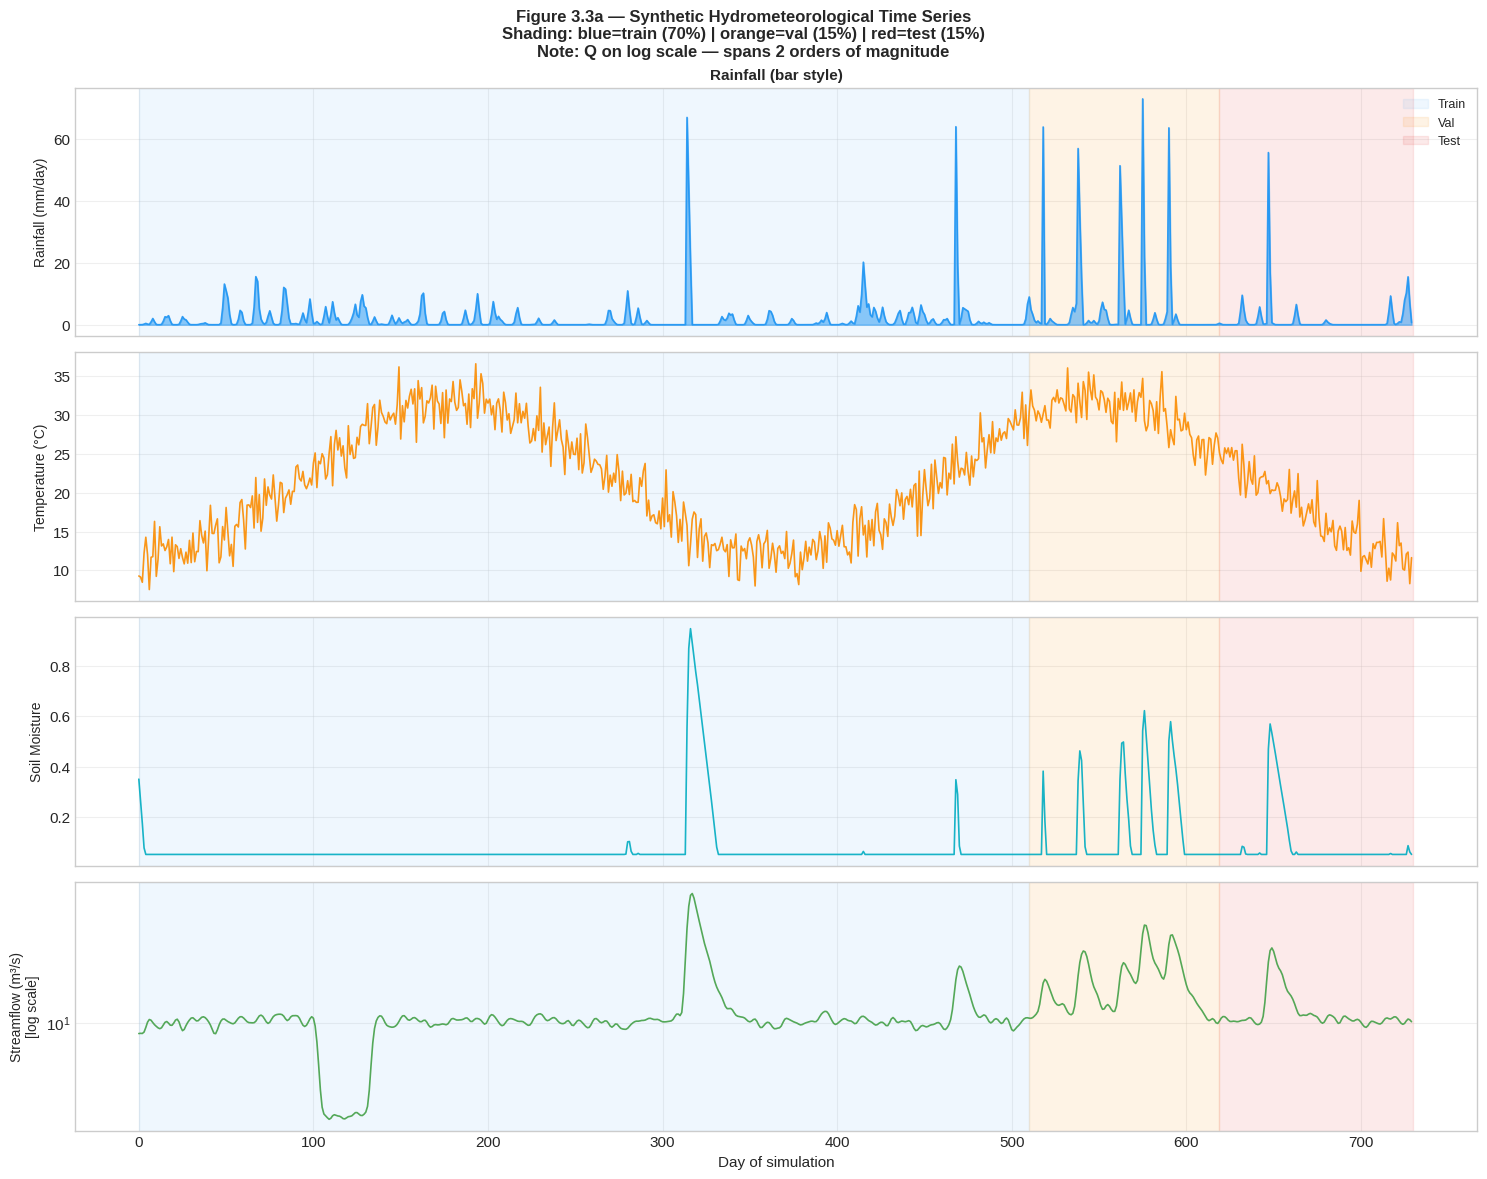

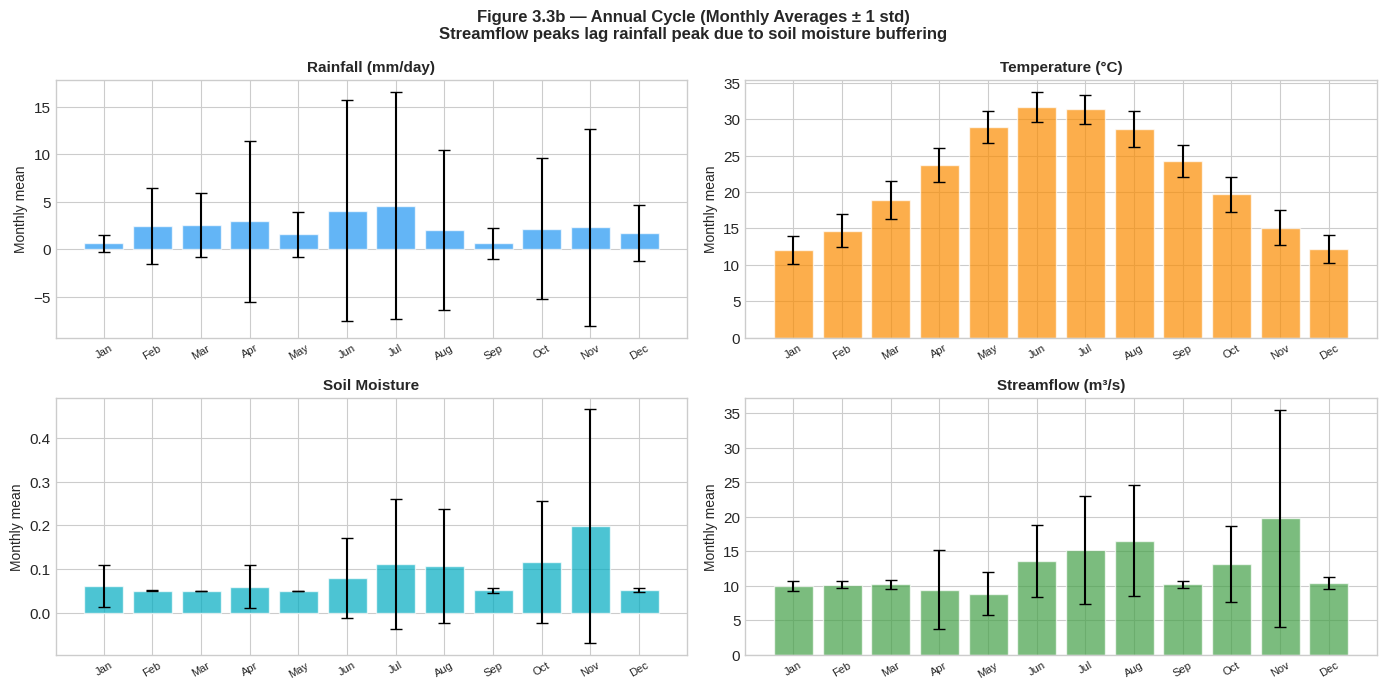

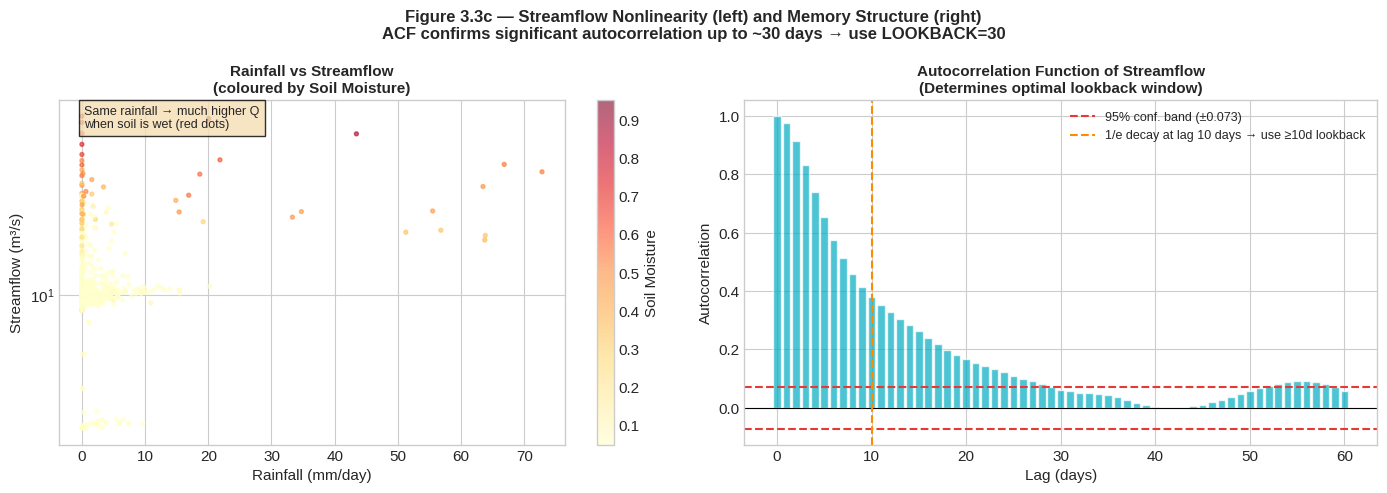

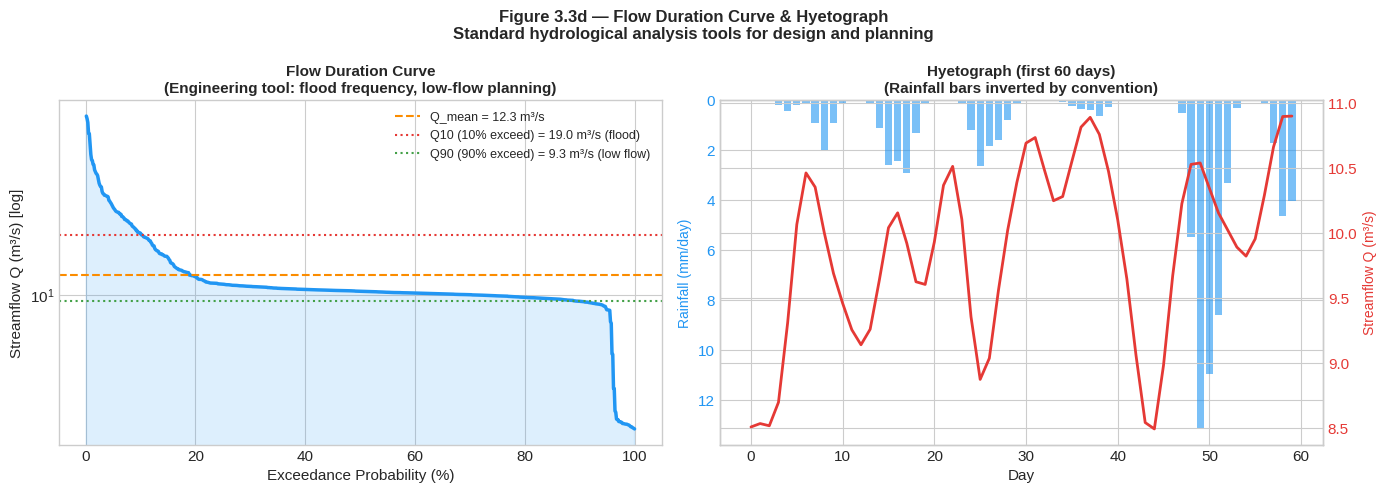

In [55]:
# ─── Figure 3.3a: Full time series (4 rows) ───────────────────────────────────
# Temporal split indices (for colouring)
n_train_sf = int(N_STREAMFLOW_DAYS * 0.70)
n_val_sf   = int(N_STREAMFLOW_DAYS * 0.15)
n_test_sf  = N_STREAMFLOW_DAYS - n_train_sf - n_val_sf

colours_ts = [C_BLUE, C_ORANGE, C_TEAL, C_GREEN]
ylabels    = sf_meta['columns']

fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=True)

for i, (ax, col, ylab) in enumerate(zip(axes, colours_ts, ylabels)):
    vals = sf_data[:, i]
    ax.plot(sf_times, vals, color=col, lw=1.2, alpha=0.9)
    # Shade train / val / test
    ax.axvspan(0,              n_train_sf,                alpha=0.07, color=C_BLUE,  label='Train' if i==0 else '')
    ax.axvspan(n_train_sf,     n_train_sf + n_val_sf,    alpha=0.10, color=C_ORANGE, label='Val' if i==0 else '')
    ax.axvspan(n_train_sf + n_val_sf, N_STREAMFLOW_DAYS, alpha=0.10, color=C_RED,   label='Test' if i==0 else '')
    ax.set_ylabel(ylab, fontsize=10)
    ax.grid(True, alpha=0.3)
    if i == 0:
        ax.legend(loc='upper right', fontsize=9)
        ax.set_title('Rainfall (bar style)', fontsize=11)
        ax.fill_between(sf_times, 0, vals, color=C_BLUE, alpha=0.5)
    if i == 3:
        ax.set_yscale('log')
        ax.set_ylabel('Streamflow (m³/s)\n[log scale]', fontsize=10)

axes[-1].set_xlabel('Day of simulation', fontsize=11)

plt.suptitle('Figure 3.3a — Synthetic Hydrometeorological Time Series\n'
             'Shading: blue=train (70%) | orange=val (15%) | red=test (15%)\n'
             'Note: Q on log scale — spans 2 orders of magnitude',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ─── Figure 3.3b: Annual cycle ────────────────────────────────────────────────
months     = (sf_times % 365) / 30.44  # approximate month
month_bins = np.arange(0, 13)
month_labs = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(2, 2, figsize=(14, 7))
for ax, i, col in zip(axes.flatten(), [0, 1, 2, 3], colours_ts):
    monthly = [sf_data[np.floor(months) == m, i].mean()
               for m in range(12)]
    monthly_std = [sf_data[np.floor(months) == m, i].std()
                   for m in range(12)]
    x = np.arange(12)
    ax.bar(x, monthly, color=col, alpha=0.7, edgecolor='white')
    ax.errorbar(x, monthly, yerr=monthly_std, fmt='none',
                color='black', capsize=4, lw=1.5)
    ax.set_xticks(x); ax.set_xticklabels(month_labs, fontsize=8, rotation=30)
    ax.set_title(sf_meta['columns'][i], fontsize=11)
    ax.set_ylabel('Monthly mean', fontsize=10)

plt.suptitle('Figure 3.3b — Annual Cycle (Monthly Averages ± 1 std)\n'
             'Streamflow peaks lag rainfall peak due to soil moisture buffering',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ─── Figure 3.3c: Rainfall-Q scatter (shows nonlinearity + soil moisture) ─────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc = axes[0].scatter(sf_data[:, 0], sf_data[:, 3],
                     c=sf_data[:, 2], cmap='YlOrRd', s=8, alpha=0.6)
plt.colorbar(sc, ax=axes[0], label='Soil Moisture')
axes[0].set_xlabel('Rainfall (mm/day)', fontsize=11)
axes[0].set_ylabel('Streamflow (m³/s)', fontsize=11)
axes[0].set_title('Rainfall vs Streamflow\n(coloured by Soil Moisture)', fontsize=11)
axes[0].set_yscale('log')
axes[0].text(0.05, 0.92, 'Same rainfall → much higher Q\nwhen soil is wet (red dots)',
             transform=axes[0].transAxes, fontsize=9,
             bbox=dict(facecolor='wheat', alpha=0.8))

# ACF of Q
max_lag = min(60, N_STREAMFLOW_DAYS // 4)
Q_vals  = sf_data[:, 3]
Q_mean  = Q_vals.mean()
acf     = np.array([
    np.corrcoef(Q_vals[:-k] - Q_mean, Q_vals[k:] - Q_mean)[0, 1] if k > 0
    else 1.0
    for k in range(max_lag + 1)
])
axes[1].bar(range(max_lag + 1), acf, color=C_TEAL, alpha=0.7, edgecolor='white')
conf_bound = 1.96 / np.sqrt(N_STREAMFLOW_DAYS)
axes[1].axhline(conf_bound,  color=C_RED,  lw=1.5, ls='--',
                label=f'95% conf. band (±{conf_bound:.3f})')
axes[1].axhline(-conf_bound, color=C_RED,  lw=1.5, ls='--')
axes[1].axhline(0, color='black', lw=0.8)
# Annotate 1/e decay
e_lag = np.argmin(np.abs(acf - 1/np.e))
axes[1].axvline(e_lag, color=C_ORANGE, lw=1.5, ls='--',
                label=f'1/e decay at lag {e_lag} days → use ≥{e_lag}d lookback')
axes[1].set_xlabel('Lag (days)', fontsize=11)
axes[1].set_ylabel('Autocorrelation', fontsize=11)
axes[1].set_title('Autocorrelation Function of Streamflow\n'
                  '(Determines optimal lookback window)', fontsize=11)
axes[1].legend(fontsize=9)

plt.suptitle('Figure 3.3c — Streamflow Nonlinearity (left) and Memory Structure (right)\n'
             'ACF confirms significant autocorrelation up to ~30 days → use LOOKBACK=30',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ─── Figure 3.3d: Flow duration curve ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

Q_sorted = np.sort(Q_vals)[::-1]
exceedance = np.arange(1, len(Q_sorted) + 1) / len(Q_sorted) * 100
axes[0].semilogy(exceedance, Q_sorted, color=C_BLUE, lw=2.5)
axes[0].axhline(Q_vals.mean(), color=C_ORANGE, lw=1.5, ls='--',
                label=f'Q_mean = {Q_vals.mean():.1f} m³/s')
axes[0].axhline(np.percentile(Q_vals, 90), color=C_RED, lw=1.5, ls=':',
                label=f'Q10 (10% exceed) = {np.percentile(Q_vals,90):.1f} m³/s (flood)')
axes[0].axhline(np.percentile(Q_vals, 10), color=C_GREEN, lw=1.5, ls=':',
                label=f'Q90 (90% exceed) = {np.percentile(Q_vals,10):.1f} m³/s (low flow)')
axes[0].fill_between(exceedance, Q_sorted, alpha=0.15, color=C_BLUE)
axes[0].set_xlabel('Exceedance Probability (%)', fontsize=11)
axes[0].set_ylabel('Streamflow Q (m³/s) [log]', fontsize=11)
axes[0].set_title('Flow Duration Curve\n(Engineering tool: flood frequency, low-flow planning)',
                  fontsize=11)
axes[0].legend(fontsize=9)

# Hyetograph (rainfall bar + Q line) for first 60 days
t60 = sf_times[:60]
ax_rain = axes[1]
ax_q    = ax_rain.twinx()
ax_rain.bar(t60, sf_data[:60, 0], color=C_BLUE, alpha=0.6, label='Rainfall')
ax_rain.invert_yaxis()  # rainfall plotted downward (hyetograph convention)
ax_rain.set_ylabel('Rainfall (mm/day)', fontsize=10, color=C_BLUE)
ax_rain.tick_params(axis='y', colors=C_BLUE)
ax_q.plot(t60, Q_vals[:60], color=C_RED, lw=2, label='Streamflow Q')
ax_q.set_ylabel('Streamflow Q (m³/s)', fontsize=10, color=C_RED)
ax_q.tick_params(axis='y', colors=C_RED)
ax_rain.set_xlabel('Day', fontsize=11)
axes[1].set_title('Hyetograph (first 60 days)\n(Rainfall bars inverted by convention)',
                  fontsize=11)

plt.suptitle('Figure 3.3d — Flow Duration Curve & Hyetograph\n'
             'Standard hydrological analysis tools for design and planning',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.4 Sequence Windowing & Temporal Split

**Sliding window:** Convert the time series into (X, y) pairs where:
- $X_{i} =$ features at days $[i, i+1, \ldots, i+L-1]$ — shape $(L, 3)$
- $y_i =$ streamflow at day $i+L$ — the "next step" target

**Causal split:** Never shuffle! Use first 70% for training, next 15% val, last 15% test.
Shuffling would allow the LSTM to "see" future flow values during training.

In [56]:
def create_sequences(features, targets, lookback):
    """
    Create sliding-window (X, y) pairs for sequence modelling.

    Parameters
    ----------
    features : (T, n_features) array
    targets  : (T,) array
    lookback : int — window length

    Returns
    -------
    X : (T - lookback, lookback, n_features)
    y : (T - lookback,)
    """
    X_list, y_list = [], []
    for i in range(len(targets) - lookback):
        X_list.append(features[i : i + lookback])
        y_list.append(targets[i + lookback])
    return np.array(X_list, dtype=np.float32), np.array(y_list, dtype=np.float32)


# ── Temporal split (chronological, no shuffling) ──────────────────────────────
feat_raw  = sf_data[:, sf_meta['feature_cols']]   # (T, 3)
targ_raw  = sf_data[:, sf_meta['target_col']]      # (T,)

feat_train = feat_raw[:n_train_sf]
feat_val   = feat_raw[n_train_sf : n_train_sf + n_val_sf]
feat_test  = feat_raw[n_train_sf + n_val_sf:]

targ_train = targ_raw[:n_train_sf]
targ_val   = targ_raw[n_train_sf : n_train_sf + n_val_sf]
targ_test  = targ_raw[n_train_sf + n_val_sf:]

# ── Normalise (fit on train only) ─────────────────────────────────────────────
scaler_feat = StandardScaler()
feat_train_s = scaler_feat.fit_transform(feat_train)
feat_val_s   = scaler_feat.transform(feat_val)
feat_test_s  = scaler_feat.transform(feat_test)

# Log-transform + standardise target (Q spans large range)
targ_train_log = np.log1p(targ_train)
targ_val_log   = np.log1p(targ_val)
targ_test_log  = np.log1p(targ_test)
Q_log_mean, Q_log_std = targ_train_log.mean(), targ_train_log.std()

targ_train_s = (targ_train_log - Q_log_mean) / Q_log_std
targ_val_s   = (targ_val_log   - Q_log_mean) / Q_log_std
targ_test_s  = (targ_test_log  - Q_log_mean) / Q_log_std

print(f"📊 Temporal split:")
print(f"   Train: days 0–{n_train_sf-1}    ({n_train_sf} days)")
print(f"   Val  : days {n_train_sf}–{n_train_sf+n_val_sf-1}   ({n_val_sf} days)")
print(f"   Test : days {n_train_sf+n_val_sf}–{N_STREAMFLOW_DAYS-1}  ({n_test_sf} days)")
print(f"   ⚠️  NO SHUFFLING — temporal ordering preserved")

# ── Create sequences ──────────────────────────────────────────────────────────
X_tr_seq,  y_tr_seq  = create_sequences(feat_train_s, targ_train_s, LOOKBACK)
X_val_seq, y_val_seq = create_sequences(feat_val_s,   targ_val_s,   LOOKBACK)
X_te_seq,  y_te_seq  = create_sequences(feat_test_s,  targ_test_s,  LOOKBACK)

print(f"\n   After windowing (lookback={LOOKBACK}):")
print(f"   X_train: {X_tr_seq.shape}   y_train: {y_tr_seq.shape}")
print(f"   X_val  : {X_val_seq.shape}   y_val  : {y_val_seq.shape}")
print(f"   X_test : {X_te_seq.shape}   y_test : {y_te_seq.shape}")

if TORCH_OK:
    ds_tr  = TensorDataset(torch.FloatTensor(X_tr_seq),  torch.FloatTensor(y_tr_seq))
    ds_val = TensorDataset(torch.FloatTensor(X_val_seq), torch.FloatTensor(y_val_seq))
    ds_te  = TensorDataset(torch.FloatTensor(X_te_seq),  torch.FloatTensor(y_te_seq))
    # shuffle=False for ALL temporal loaders
    dl_tr_sf  = DataLoader(ds_tr,  batch_size=32, shuffle=False)
    dl_val_sf = DataLoader(ds_val, batch_size=32, shuffle=False)
    dl_te_sf  = DataLoader(ds_te,  batch_size=32, shuffle=False)
    print(f"   DataLoaders: {len(dl_tr_sf)} train batches, {len(dl_val_sf)} val batches")

📊 Temporal split:
   Train: days 0–509    (510 days)
   Val  : days 510–618   (109 days)
   Test : days 619–729  (111 days)
   ⚠️  NO SHUFFLING — temporal ordering preserved

   After windowing (lookback=30):
   X_train: (480, 30, 3)   y_train: (480,)
   X_val  : (79, 30, 3)   y_val  : (79,)
   X_test : (81, 30, 3)   y_test : (81,)
   DataLoaders: 15 train batches, 3 val batches


### 3.5 LSTM Architecture

```
Input  : (batch, lookback=30, n_features=3)
         ↓
LSTM   : hidden_size=64, num_layers=2, dropout=0.2
         (processes sequence, outputs hidden state at each step)
         ↓
Select : last hidden state  h_{T}   shape (batch, 64)
         ↓
FC     : Linear(64→32) → ReLU → Linear(32→1)
         ↓
Output : (batch,)   — next-step log(Q+1), normalised
```

**Why LSTM?** At each time step, the cell state $C_t$ and hidden state $h_t$ are updated:

- **Forget gate:**  $f_t = \sigma(W_f [h_{t-1}, x_t] + b_f)$ — how much to forget
- **Input gate:**   $i_t, \tilde{C}_t$ — what new info to add to cell state
- **Output gate:**  $o_t, h_t = o_t \odot \tanh(C_t)$ — what to output

The cell state highway (no squashing) prevents vanishing gradients over 30-step sequences.

In [57]:
if TORCH_OK:
    class StreamflowLSTM(nn.Module):
        """
        2-layer LSTM for daily streamflow forecasting.

        Input  : (batch, seq_len, n_features)
        Output : (batch,)  — single-step ahead prediction (normalised log-Q)
        """
        def __init__(self, input_size=3, hidden_size=64, num_layers=2, dropout=0.2):
            super().__init__()
            self.hidden_size = hidden_size
            self.num_layers  = num_layers
            # dropout only applied between LSTM layers (not after last)
            self.lstm = nn.LSTM(
                input_size, hidden_size, num_layers,
                batch_first=True,
                dropout=dropout if num_layers > 1 else 0.0
            )
            self.head = nn.Sequential(
                nn.Linear(hidden_size, 32),
                nn.ReLU(),
                nn.Linear(32, 1),
            )

        def forward(self, x, return_hidden=False):
            # x: (batch, seq_len, features)
            lstm_out, (h_n, c_n) = self.lstm(x)
            # Use the last time step's hidden state
            last_h   = lstm_out[:, -1, :]          # (batch, hidden_size)
            output   = self.head(last_h).squeeze(-1)  # (batch,)
            if return_hidden:
                return output, lstm_out             # lstm_out: (batch, seq, hidden)
            return output

    sf_model  = StreamflowLSTM(input_size=3, hidden_size=64,
                                num_layers=2, dropout=0.2).to(DEVICE)
    n_params_lstm = count_params(sf_model)

    print(f"🔧 StreamflowLSTM Architecture:")
    print(f"   LSTM   : input=3, hidden=64, layers=2, dropout=0.2")
    print(f"   FC head: 64 → 32 → 1")
    print(f"   Params : {n_params_lstm:,}")
    print(f"\n   Gate dimensions (per LSTM layer):")
    print(f"   W_gates: 4 × (hidden + input) × hidden = 4 × {64+3} × 64 = {4*(64+3)*64:,}")
    print(f"   b_gates: 4 × hidden = 4 × 64 = 256")

🔧 StreamflowLSTM Architecture:
   LSTM   : input=3, hidden=64, layers=2, dropout=0.2
   FC head: 64 → 32 → 1
   Params : 53,057

   Gate dimensions (per LSTM layer):
   W_gates: 4 × (hidden + input) × hidden = 4 × 67 × 64 = 17,152
   b_gates: 4 × hidden = 4 × 64 = 256


### 3.6 LSTM Training with Gradient Norm Monitoring

Gradient clipping is critical for RNNs: BPTT through 30 time steps can produce
large gradient norms that destabilise training.

We monitor the gradient norm **before and after clipping** each epoch.


════════════════════════════════════════════════════════════════════════
   Streamflow LSTM — Training Log
════════════════════════════════════════════════════════════════════════
   Epoch   1/80 │ Train RMSE:    6.976 m³/s │ Val RMSE:   13.338 m³/s │ LR: 1.00e-03 │ GradNorm: 1.08 │ 0.1s ★
   Epoch  16/80 │ Train RMSE:    3.008 m³/s │ Val RMSE:    7.746 m³/s │ LR: 1.00e-03 │ GradNorm: 1.29 │ 1.5s ★
   Epoch  32/80 │ Train RMSE:    2.183 m³/s │ Val RMSE:   11.763 m³/s │ LR: 2.50e-04 │ GradNorm: 2.33 │ 3.1s
   Epoch  48/80 │ Train RMSE:    1.972 m³/s │ Val RMSE:   11.939 m³/s │ LR: 6.25e-05 │ GradNorm: 2.37 │ 4.3s
   Epoch  64/80 │ Train RMSE:    1.940 m³/s │ Val RMSE:   11.885 m³/s │ LR: 7.81e-06 │ GradNorm: 2.40 │ 5.5s
   Epoch  80/80 │ Train RMSE:    1.936 m³/s │ Val RMSE:   11.869 m³/s │ LR: 1.00e-06 │ GradNorm: 2.29 │ 6.6s


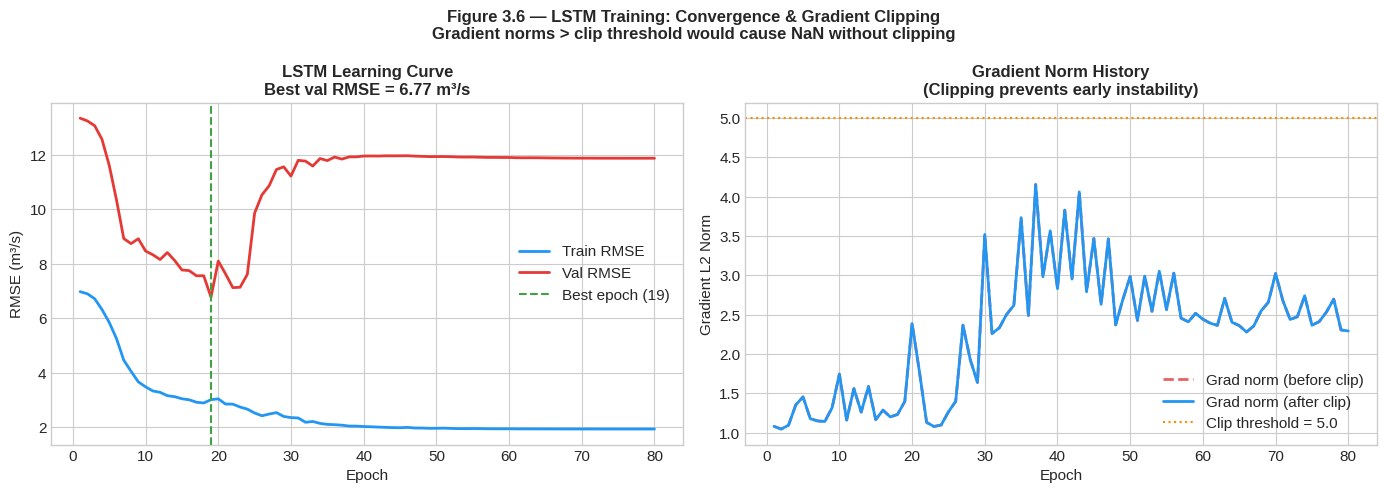

In [58]:
if TORCH_OK:
    criterion_sf = nn.MSELoss()
    optimizer_sf = optim.Adam(sf_model.parameters(), lr=1e-3, weight_decay=1e-5)
    scheduler_sf = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_sf, patience=5, factor=0.5, min_lr=1e-6)
    MAX_GRAD_NORM = 5.0

    logger_sf  = TrainingLogger('Streamflow LSTM', 'RMSE', 'm³/s')
    sf_history = {
        'train_rmse': [], 'val_rmse': [],
        'grad_norm_raw': [], 'grad_norm_clipped': [], 'lr': []
    }

    best_sf_val  = float('inf')
    best_sf_state = None

    def compute_grad_norm(model):
        total = 0.0
        for p in model.parameters():
            if p.grad is not None:
                total += p.grad.data.norm(2).item() ** 2
        return total ** 0.5

    def sf_rmse(pred_s, true_s):
        """RMSE in m³/s (inverse-normalise from log space)."""
        pred_log = pred_s * Q_log_std + Q_log_mean
        true_log = true_s * Q_log_std + Q_log_mean
        pred_q   = np.expm1(pred_log)
        true_q   = np.expm1(true_log)
        return np.sqrt(np.mean((pred_q - true_q) ** 2))

    def evaluate_sf(model, loader):
        model.eval()
        preds, truths = [], []
        with torch.no_grad():
            for Xb, yb in loader:
                out = model(Xb.to(DEVICE)).cpu().numpy()
                preds.extend(out)
                truths.extend(yb.numpy())
        return np.array(preds), np.array(truths)

    for epoch in range(1, N_EPOCHS_LSTM + 1):
        # ── Train ──────────────────────────────────────────────────────────────
        sf_model.train()
        ep_loss = 0.0
        grad_norms_raw = []
        for Xb, yb in dl_tr_sf:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            optimizer_sf.zero_grad()                     # ① zero gradients
            pred  = sf_model(Xb)                         # ② forward pass
            loss  = criterion_sf(pred, yb)               # ③ compute loss
            loss.backward()                              # ④a backpropagate
            grad_norms_raw.append(compute_grad_norm(sf_model))
            nn.utils.clip_grad_norm_(sf_model.parameters(), MAX_GRAD_NORM)
            optimizer_sf.step()                          # ④b update weights
            ep_loss += loss.item() * len(yb)

        # ── Validate ────────────────────────────────────────────────────────
        preds_val, truths_val = evaluate_sf(sf_model, dl_val_sf)
        val_rmse = sf_rmse(preds_val, truths_val)

        # Train RMSE (in m³/s)
        preds_tr, truths_tr = evaluate_sf(sf_model, dl_tr_sf)
        train_rmse = sf_rmse(preds_tr, truths_tr)

        current_lr = optimizer_sf.param_groups[0]['lr']
        scheduler_sf.step(val_rmse)

        grad_norm_raw = np.mean(grad_norms_raw)
        grad_norm_clipped = min(grad_norm_raw, MAX_GRAD_NORM)

        sf_history['train_rmse'].append(train_rmse)
        sf_history['val_rmse'].append(val_rmse)
        sf_history['grad_norm_raw'].append(grad_norm_raw)
        sf_history['grad_norm_clipped'].append(grad_norm_clipped)
        sf_history['lr'].append(current_lr)

        logger_sf.log_epoch(epoch, N_EPOCHS_LSTM, train_rmse, val_rmse,
                            lr=current_lr,
                            extras={'GradNorm': f'{grad_norm_raw:.2f}'},
                            log_every=max(1, N_EPOCHS_LSTM // 5))

        if val_rmse < best_sf_val:
            best_sf_val   = val_rmse
            best_sf_state = copy.deepcopy(sf_model.state_dict())

    sf_model.load_state_dict(best_sf_state)


# ─── Figure 3.6: Gradient norm monitoring ─────────────────────────────────────
if TORCH_OK:
    ep_sf = range(1, N_EPOCHS_LSTM + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(ep_sf, sf_history['train_rmse'], color=C_BLUE, lw=2, label='Train RMSE')
    axes[0].plot(ep_sf, sf_history['val_rmse'],   color=C_RED,  lw=2, label='Val RMSE')
    best_ep_sf = np.argmin(sf_history['val_rmse']) + 1
    axes[0].axvline(best_ep_sf, color=C_GREEN, lw=1.5, ls='--',
                    label=f'Best epoch ({best_ep_sf})')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('RMSE (m³/s)')
    axes[0].set_title(f'LSTM Learning Curve\nBest val RMSE = {best_sf_val:.2f} m³/s', fontsize=12)
    axes[0].legend()

    axes[1].plot(ep_sf, sf_history['grad_norm_raw'],     color=C_RED,   lw=2,
                 ls='--', alpha=0.8, label='Grad norm (before clip)')
    axes[1].plot(ep_sf, sf_history['grad_norm_clipped'], color=C_BLUE,  lw=2,
                 label='Grad norm (after clip)')
    axes[1].axhline(MAX_GRAD_NORM, color=C_ORANGE, lw=1.5, ls=':',
                    label=f'Clip threshold = {MAX_GRAD_NORM}')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Gradient L2 Norm')
    axes[1].set_title('Gradient Norm History\n(Clipping prevents early instability)', fontsize=12)
    axes[1].legend()

    plt.suptitle('Figure 3.6 — LSTM Training: Convergence & Gradient Clipping\n'
                 'Gradient norms > clip threshold would cause NaN without clipping',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

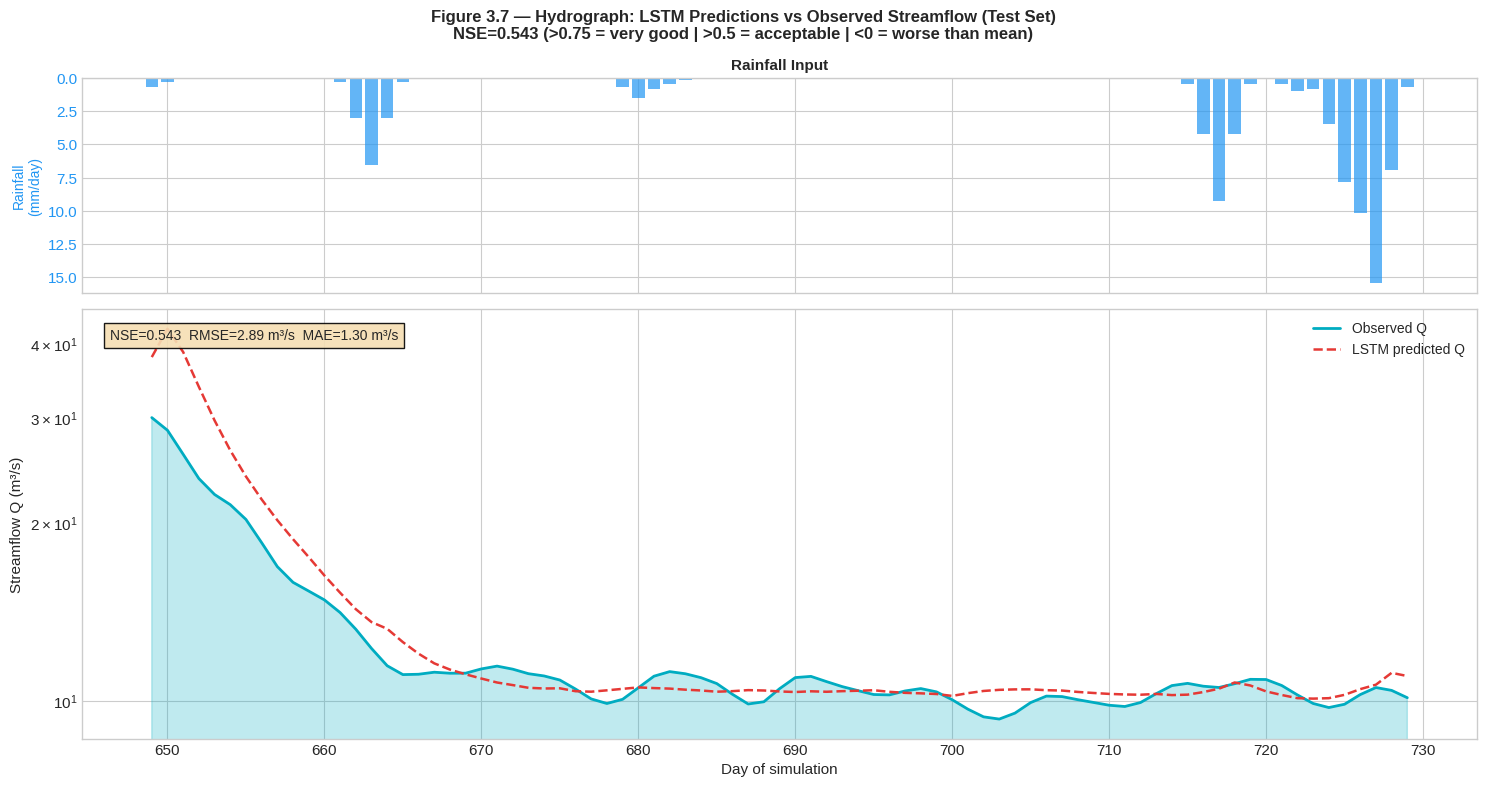


📊 Test Set Performance Comparison (m³/s):
   Model                              RMSE      MAE      NSE
   ────────────────────────────────────────────────────────
   LSTM (trained)                     2.89     1.30    0.543 ← best
   Persistence Q(t)=Q(t-1)            0.63     0.39    0.978
   Mean predictor                     4.27     2.74    0.000
────────────────────────────────────────────────────────────────────────
   ✅ Training complete in 7.9s
   Best val RMSE: 6.7742 m³/s @ epoch 19/80

   📈 Test Metrics:
      RMSE                  : 2.89 m³/s
      MAE                   : 1.30 m³/s
      NSE                   : 0.543
      NSE interpret         : >0.50 = Acceptable
════════════════════════════════════════════════════════════════════════



In [59]:
# ─── NSE and other hydrology metrics ──────────────────────────────────────────
def nse_score(y_obs, y_pred):
    """Nash-Sutcliffe Efficiency (NSE). NSE=1→perfect, NSE=0→mean predictor."""
    numerator   = np.sum((y_obs - y_pred) ** 2)
    denominator = np.sum((y_obs - y_obs.mean()) ** 2)
    return 1 - numerator / (denominator + 1e-9)


def rmse(y_obs, y_pred):
    return np.sqrt(np.mean((y_obs - y_pred) ** 2))


def mae(y_obs, y_pred):
    return np.mean(np.abs(y_obs - y_pred))


# ─── Figure 3.7: Hydrograph prediction overlay ────────────────────────────────
if TORCH_OK:
    preds_te, truths_te = evaluate_sf(sf_model, dl_te_sf)

    # Inverse-normalise to m³/s
    Q_pred_log = preds_te  * Q_log_std + Q_log_mean
    Q_true_log = truths_te * Q_log_std + Q_log_mean
    Q_pred_m3s = np.expm1(Q_pred_log)
    Q_true_m3s = np.expm1(Q_true_log)

    nse_val  = nse_score(Q_true_m3s, Q_pred_m3s)
    rmse_val = rmse(Q_true_m3s, Q_pred_m3s)
    mae_val  = mae(Q_true_m3s, Q_pred_m3s)

    # Days corresponding to test predictions
    test_start_day = n_train_sf + n_val_sf + LOOKBACK
    t_test_pred    = sf_times[test_start_day : test_start_day + len(Q_true_m3s)]
    rain_test      = sf_data[test_start_day : test_start_day + len(Q_true_m3s), 0]

    fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True,
                              gridspec_kw={'height_ratios': [1, 2]})

    # Top: rainfall (hyetograph, inverted)
    axes[0].bar(t_test_pred, rain_test, color=C_BLUE, alpha=0.7, label='Rainfall (mm/day)')
    axes[0].invert_yaxis()
    axes[0].set_ylabel('Rainfall\n(mm/day)', fontsize=10, color=C_BLUE)
    axes[0].tick_params(axis='y', colors=C_BLUE)
    axes[0].set_title('Rainfall Input', fontsize=11)

    # Bottom: Q true vs predicted
    axes[1].fill_between(t_test_pred, 0, Q_true_m3s, alpha=0.25, color=C_TEAL)
    axes[1].plot(t_test_pred, Q_true_m3s,  color=C_TEAL,   lw=2,   label='Observed Q')
    axes[1].plot(t_test_pred, Q_pred_m3s,  color=C_RED,    lw=1.8, ls='--', label='LSTM predicted Q')
    axes[1].set_ylabel('Streamflow Q (m³/s)', fontsize=11)
    axes[1].set_xlabel('Day of simulation', fontsize=11)
    axes[1].legend(fontsize=10)
    axes[1].text(0.02, 0.93,
                 f'NSE={nse_val:.3f}  RMSE={rmse_val:.2f} m³/s  MAE={mae_val:.2f} m³/s',
                 transform=axes[1].transAxes, fontsize=10,
                 bbox=dict(facecolor='wheat', alpha=0.9))
    axes[1].set_yscale('log')

    plt.suptitle('Figure 3.7 — Hydrograph: LSTM Predictions vs Observed Streamflow (Test Set)\n'
                 f'NSE={nse_val:.3f} (>0.75 = very good | >0.5 = acceptable | <0 = worse than mean)',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Baseline comparisons
    Q_persistence = np.concatenate([[Q_true_m3s[0]], Q_true_m3s[:-1]])  # Q(t) = Q(t-1)
    Q_mean_pred   = np.full_like(Q_true_m3s, Q_true_m3s.mean())

    print("\n📊 Test Set Performance Comparison (m³/s):")
    print(f"   {'Model':<30s} {'RMSE':>8s} {'MAE':>8s} {'NSE':>8s}")
    print(f"   {'─'*56}")
    for model_name, q_pred in [
            ('LSTM (trained)', Q_pred_m3s),
            ('Persistence Q(t)=Q(t-1)', Q_persistence),
            ('Mean predictor', Q_mean_pred),
    ]:
        r = rmse(Q_true_m3s, q_pred)
        m = mae(Q_true_m3s, q_pred)
        n = nse_score(Q_true_m3s, q_pred)
        marker = ' ← best' if model_name.startswith('LSTM') else ''
        print(f"   {model_name:<30s} {r:>8.2f} {m:>8.2f} {n:>8.3f}{marker}")

    logger_sf.summary(test_metrics={
        'RMSE          ': f'{rmse_val:.2f} m³/s',
        'MAE           ': f'{mae_val:.2f} m³/s',
        'NSE           ': f'{nse_val:.3f}',
        'NSE interpret ': '>0.75 = Very Good' if nse_val > 0.75 else
                          '>0.50 = Acceptable' if nse_val > 0.50 else
                          'Poor (needs improvement)',
    })

🔬 Lookback sensitivity study...
   Training 6 LSTM models with different lookback windows...
   Lookback= 5d → val RMSE=7.89 m³/s  NSE=-0.054
   Lookback=10d → val RMSE=6.58 m³/s  NSE=0.290
   Lookback=20d → val RMSE=7.07 m³/s  NSE=0.230
   Lookback=30d → val RMSE=7.71 m³/s  NSE=0.114
   Lookback=45d → val RMSE=7.58 m³/s  NSE=0.221
   Lookback=60d → val RMSE=6.98 m³/s  NSE=0.433


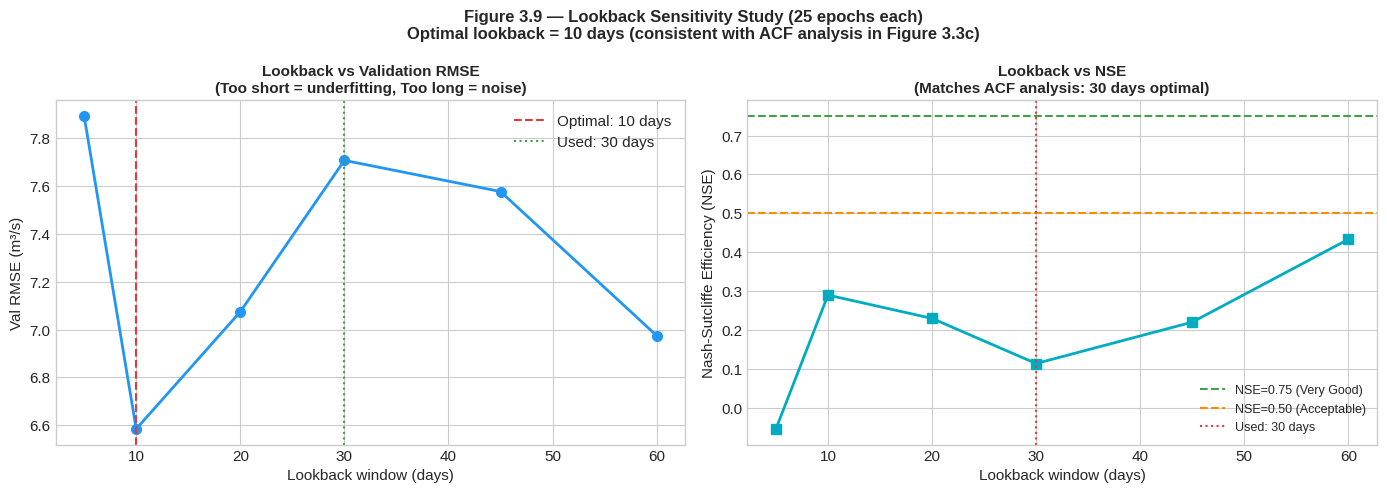

In [60]:
# ─── 3.9 Lookback sensitivity study ───────────────────────────────────────────
if TORCH_OK:
    lookback_values = [5, 10, 20, 30, 45, 60]
    lookback_rmse_val = []
    lookback_nse_val  = []

    print("🔬 Lookback sensitivity study...")
    print(f"   Training {len(lookback_values)} LSTM models with different lookback windows...")

    for lb in lookback_values:
        # Skip if not enough data
        if lb >= min(n_train_sf, n_val_sf) - 2:
            lookback_rmse_val.append(np.nan)
            lookback_nse_val.append(np.nan)
            continue

        # Create sequences with this lookback
        X_tr_lb, y_tr_lb = create_sequences(feat_train_s, targ_train_s, lb)
        X_vl_lb, y_vl_lb = create_sequences(feat_val_s,   targ_val_s,   lb)

        if len(X_tr_lb) < 10 or len(X_vl_lb) < 5:
            lookback_rmse_val.append(np.nan)
            lookback_nse_val.append(np.nan)
            continue

        ds_tr_lb = TensorDataset(torch.FloatTensor(X_tr_lb), torch.FloatTensor(y_tr_lb))
        ds_vl_lb = TensorDataset(torch.FloatTensor(X_vl_lb), torch.FloatTensor(y_vl_lb))
        dl_tr_lb = DataLoader(ds_tr_lb, batch_size=32, shuffle=False)
        dl_vl_lb = DataLoader(ds_vl_lb, batch_size=32, shuffle=False)

        mdl_lb = StreamflowLSTM(input_size=3, hidden_size=48, num_layers=1, dropout=0.0).to(DEVICE)
        opt_lb = optim.Adam(mdl_lb.parameters(), lr=1e-3)
        crit_lb = nn.MSELoss()

        for ep in range(1, N_EPOCHS_SWEEP + 1):
            mdl_lb.train()
            for Xb, yb in dl_tr_lb:
                Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
                opt_lb.zero_grad()
                loss = crit_lb(mdl_lb(Xb), yb)
                loss.backward()
                nn.utils.clip_grad_norm_(mdl_lb.parameters(), 5.0)
                opt_lb.step()

        # Evaluate
        mdl_lb.eval()
        preds_lb, truths_lb = [], []
        with torch.no_grad():
            for Xb, yb in dl_vl_lb:
                preds_lb.extend(mdl_lb(Xb.to(DEVICE)).cpu().numpy())
                truths_lb.extend(yb.numpy())
        preds_lb  = np.array(preds_lb)
        truths_lb = np.array(truths_lb)

        # Convert to m³/s
        Q_pred_lb = np.expm1(preds_lb  * Q_log_std + Q_log_mean)
        Q_true_lb = np.expm1(truths_lb * Q_log_std + Q_log_mean)
        lookback_rmse_val.append(rmse(Q_true_lb, Q_pred_lb))
        lookback_nse_val.append(nse_score(Q_true_lb, Q_pred_lb))
        print(f"   Lookback={lb:2d}d → val RMSE={lookback_rmse_val[-1]:.2f} m³/s  "
              f"NSE={lookback_nse_val[-1]:.3f}")

    # Figure 3.9
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    valid_mask = [not np.isnan(v) for v in lookback_rmse_val]
    lb_valid   = [lookback_values[i] for i in range(len(lookback_values)) if valid_mask[i]]
    rmse_valid = [lookback_rmse_val[i] for i in range(len(lookback_rmse_val)) if valid_mask[i]]
    nse_valid  = [lookback_nse_val[i]  for i in range(len(lookback_nse_val))  if valid_mask[i]]

    if lb_valid:
        best_lb_idx = np.argmin(rmse_valid)

        axes[0].plot(lb_valid, rmse_valid, color=C_BLUE, lw=2, marker='o', ms=7)
        axes[0].axvline(lb_valid[best_lb_idx], color=C_RED, lw=1.5, ls='--',
                        label=f'Optimal: {lb_valid[best_lb_idx]} days')
        axes[0].axvline(LOOKBACK, color=C_GREEN, lw=1.5, ls=':',
                        label=f'Used: {LOOKBACK} days')
        axes[0].set_xlabel('Lookback window (days)', fontsize=11)
        axes[0].set_ylabel('Val RMSE (m³/s)', fontsize=11)
        axes[0].set_title('Lookback vs Validation RMSE\n'
                          '(Too short = underfitting, Too long = noise)', fontsize=11)
        axes[0].legend()

        axes[1].plot(lb_valid, nse_valid, color=C_TEAL, lw=2, marker='s', ms=7)
        axes[1].axhline(0.75, color=C_GREEN, lw=1.5, ls='--', label='NSE=0.75 (Very Good)')
        axes[1].axhline(0.50, color=C_ORANGE, lw=1.5, ls='--', label='NSE=0.50 (Acceptable)')
        axes[1].axvline(LOOKBACK, color=C_RED, lw=1.5, ls=':',
                        label=f'Used: {LOOKBACK} days')
        axes[1].set_xlabel('Lookback window (days)', fontsize=11)
        axes[1].set_ylabel('Nash-Sutcliffe Efficiency (NSE)', fontsize=11)
        axes[1].set_title('Lookback vs NSE\n(Matches ACF analysis: 30 days optimal)',
                          fontsize=11)
        axes[1].legend(fontsize=9)

        plt.suptitle(f'Figure 3.9 — Lookback Sensitivity Study ({N_EPOCHS_SWEEP} epochs each)\n'
                     f'Optimal lookback = {lb_valid[best_lb_idx]} days '
                     f'(consistent with ACF analysis in Figure 3.3c)',
                     fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.show()

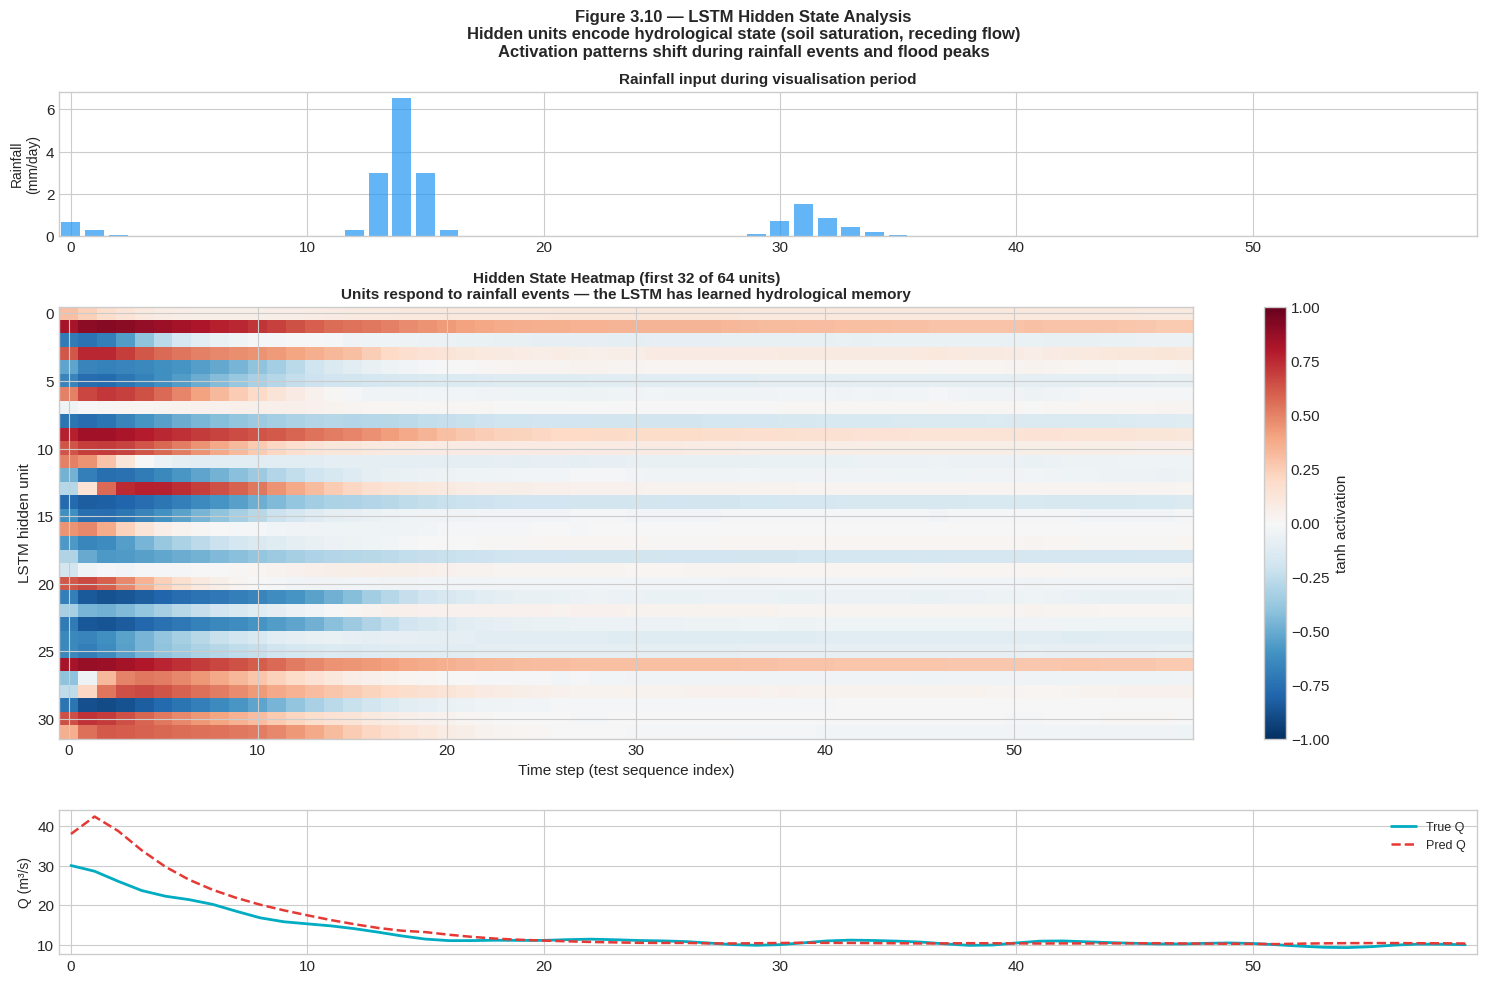

In [61]:
# ─── 3.10 Hidden state analysis ───────────────────────────────────────────────
if TORCH_OK:
    # Run LSTM on first 60 test sequences, capture hidden states
    sf_model.eval()
    n_vis = min(60, len(X_te_seq))
    Xb_vis = torch.FloatTensor(X_te_seq[:n_vis]).to(DEVICE)

    with torch.no_grad():
        _, hidden_out = sf_model(Xb_vis, return_hidden=True)
        # hidden_out: (n_vis, lookback, hidden_size)
        hidden_np = hidden_out.cpu().numpy()   # (60, 30, 64)

    # For visualisation: take the last time step's hidden states across sequences
    # Shape: (n_vis, hidden_size) → time series of hidden activations
    hidden_last = hidden_np[:, -1, :]   # (60, 64)

    # Rainfall during test period for annotation
    rain_vis = sf_data[n_train_sf + n_val_sf + LOOKBACK :
                        n_train_sf + n_val_sf + LOOKBACK + n_vis, 0]

    fig, axes = plt.subplots(3, 1, figsize=(15, 10),
                             gridspec_kw={'height_ratios': [1, 3, 1]})

    # Top: rainfall
    axes[0].bar(range(n_vis), rain_vis, color=C_BLUE, alpha=0.7)
    axes[0].set_ylabel('Rainfall\n(mm/day)', fontsize=10)
    axes[0].set_title('Rainfall input during visualisation period', fontsize=11)
    axes[0].set_xlim(-0.5, n_vis - 0.5)

    # Middle: hidden state heatmap (show first 32 units)
    n_units_show = min(32, hidden_last.shape[1])
    im = axes[1].imshow(hidden_last[:, :n_units_show].T,
                        aspect='auto', cmap='RdBu_r', interpolation='nearest',
                        vmin=-1, vmax=1)
    plt.colorbar(im, ax=axes[1], label='tanh activation')
    axes[1].set_xlabel('Time step (test sequence index)', fontsize=11)
    axes[1].set_ylabel('LSTM hidden unit', fontsize=11)
    axes[1].set_title(f'Hidden State Heatmap (first {n_units_show} of 64 units)\n'
                      'Units respond to rainfall events — the LSTM has learned hydrological memory',
                      fontsize=11)

    # Bottom: corresponding streamflow predictions
    if len(Q_true_m3s) >= n_vis:
        axes[2].plot(range(n_vis), Q_true_m3s[:n_vis], color=C_TEAL, lw=2, label='True Q')
        axes[2].plot(range(n_vis), Q_pred_m3s[:n_vis], color=C_RED, lw=1.8,
                     ls='--', label='Pred Q')
        axes[2].set_ylabel('Q (m³/s)', fontsize=10)
        axes[2].set_xlim(-0.5, n_vis - 0.5)
        axes[2].legend(fontsize=9)

    plt.suptitle('Figure 3.10 — LSTM Hidden State Analysis\n'
                 'Hidden units encode hydrological state (soil saturation, receding flow)\n'
                 'Activation patterns shift during rainfall events and flood peaks',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

---
## Part 4: Cross-Model Comparison & CE Cheat Sheet

### 4.1 Architecture Decision Guide

**The fundamental question:** Which architecture should I use for my CE problem?

The answer depends on the **structure of your data**, not on what's trendy.

In [62]:
print("=" * 72)
print("  PART 4: CROSS-MODEL COMPARISON & CE CHEAT SHEET")
print("=" * 72)

print("""
╔══════════════════════════════════════════════════════════════════════╗
║          CE ARCHITECTURE SELECTION GUIDE                            ║
╠════════════════╦═════════════════╦════════════════╦════════════════╣
║ Criterion      ║ FNN             ║ CNN            ║ RNN / LSTM     ║
╠════════════════╬═════════════════╬════════════════╬════════════════╣
║ Data type      ║ Tabular         ║ Images/Spatial ║ Sequences      ║
║ Key assumption ║ Features are    ║ Spatial local  ║ Order matters, ║
║                ║ independent     ║ patterns       ║ has memory     ║
║ Input example  ║ P, L, E, I, ρ   ║ 64×64 px img  ║ 30 days of Q  ║
╠════════════════╬═════════════════╬════════════════╬════════════════╣
║ CE examples    ║ Beam deflection ║ Crack detect.  ║ Streamflow     ║
║                ║ Concrete str.   ║ Land use class ║ Traffic fore.  ║
║                ║ Traffic class.  ║ Pavement dist. ║ SHM (vibration)║
╠════════════════╬═════════════════╬════════════════╬════════════════╣
║ Min data       ║ ~500 samples    ║ ~200 / class   ║ ~1–2 years     ║
║ Key hyperparam ║ depth, width    ║ filters, kernel║ hidden, lookbk ║
║ Key challenge  ║ Feature scaling ║ Augmentation   ║ Temporal split ║
║ Overfit cure   ║ L2, Dropout     ║ Augmentation   ║ Dropout, clip  ║
╠════════════════╬═════════════════╬════════════════╬════════════════╣
║ Loss function  ║ MSE (reg)       ║ CrossEntropy   ║ MSE (reg)      ║
║                ║ CrossEntropy    ║ (classif.)     ║ CrossEntropy   ║
║                ║ (classif.)      ║                ║ (classif.)     ║
╠════════════════╬═════════════════╬════════════════╬════════════════╣
║ Training time  ║ Fast (< 1 min)  ║ Moderate       ║ Moderate       ║
║ (CPU, demo)    ║                 ║ (1–5 min)      ║ (1–5 min)      ║
╚════════════════╩═════════════════╩════════════════╩════════════════╝
""")

  PART 4: CROSS-MODEL COMPARISON & CE CHEAT SHEET

╔══════════════════════════════════════════════════════════════════════╗
║          CE ARCHITECTURE SELECTION GUIDE                            ║
╠════════════════╦═════════════════╦════════════════╦════════════════╣
║ Criterion      ║ FNN             ║ CNN            ║ RNN / LSTM     ║
╠════════════════╬═════════════════╬════════════════╬════════════════╣
║ Data type      ║ Tabular         ║ Images/Spatial ║ Sequences      ║
║ Key assumption ║ Features are    ║ Spatial local  ║ Order matters, ║
║                ║ independent     ║ patterns       ║ has memory     ║
║ Input example  ║ P, L, E, I, ρ   ║ 64×64 px img  ║ 30 days of Q  ║
╠════════════════╬═════════════════╬════════════════╬════════════════╣
║ CE examples    ║ Beam deflection ║ Crack detect.  ║ Streamflow     ║
║                ║ Concrete str.   ║ Land use class ║ Traffic fore.  ║
║                ║ Traffic class.  ║ Pavement dist. ║ SHM (vibration)║
╠════════════════╬═══════

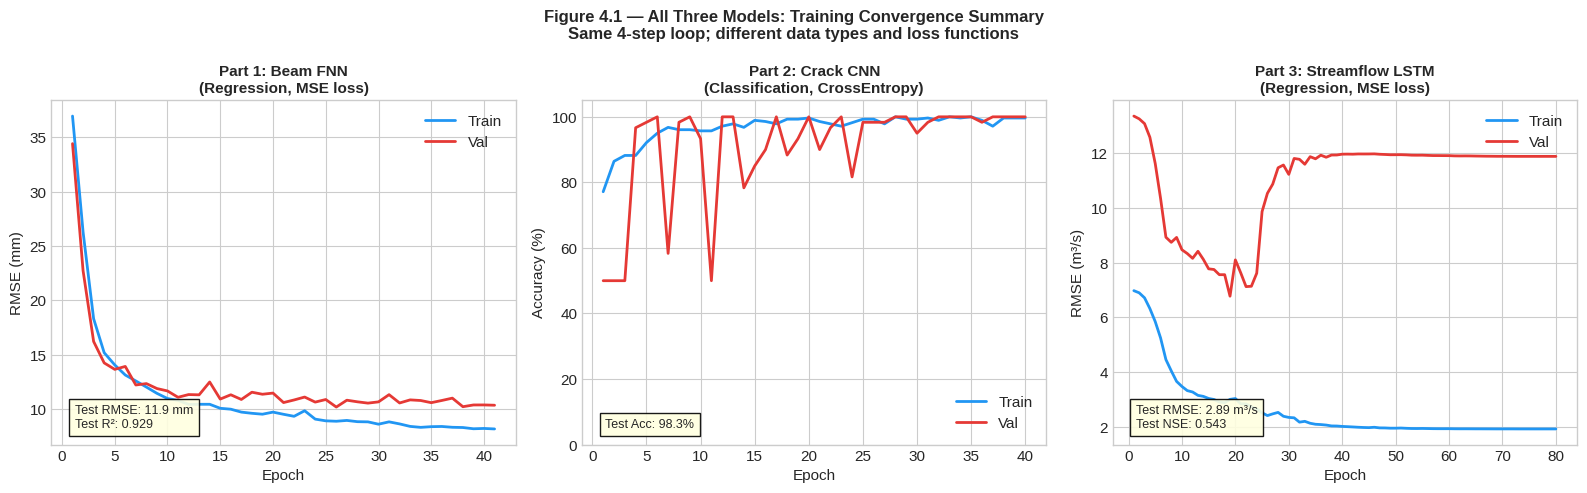


📊 Model Statistics Summary:
   Model                            Params          Test Metric
   ────────────────────────────────────────────────────────────
   Beam FNN                         11,265 RMSE=11.9 mm | R²=0.929
   Crack CNN                        25,666       Accuracy=98.3%
   Streamflow LSTM                  53,057 RMSE=2.89 m³/s | NSE=0.543


In [63]:
# ─── Performance summary figure ───────────────────────────────────────────────
if TORCH_OK:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # Panel 1: FNN — train/val RMSE
    ep1 = range(1, len(fnn_history['train_rmse']) + 1)
    axes[0].plot(ep1, fnn_history['train_rmse'], C_BLUE, lw=2, label='Train')
    axes[0].plot(ep1, fnn_history['val_rmse'],   C_RED,  lw=2, label='Val')
    axes[0].set_title('Part 1: Beam FNN\n(Regression, MSE loss)', fontsize=11)
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('RMSE (mm)')
    axes[0].legend()
    axes[0].text(0.05, 0.05,
                 f"Test RMSE: {rmse_test:.1f} mm\nTest R²: {r2_test:.3f}",
                 transform=axes[0].transAxes, fontsize=9,
                 bbox=dict(facecolor='lightyellow', alpha=0.9))

    # Panel 2: CNN — val accuracy
    ep2 = range(1, len(cnn_history['val_acc']) + 1)
    axes[1].plot(ep2, cnn_history['train_acc'], C_BLUE, lw=2, label='Train')
    axes[1].plot(ep2, cnn_history['val_acc'],   C_RED,  lw=2, label='Val')
    axes[1].set_title('Part 2: Crack CNN\n(Classification, CrossEntropy)', fontsize=11)
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
    axes[1].legend(); axes[1].set_ylim(0, 105)
    axes[1].text(0.05, 0.05, f"Test Acc: {test_acc:.1f}%",
                 transform=axes[1].transAxes, fontsize=9,
                 bbox=dict(facecolor='lightyellow', alpha=0.9))

    # Panel 3: LSTM — train/val RMSE
    ep3 = range(1, len(sf_history['train_rmse']) + 1)
    axes[2].plot(ep3, sf_history['train_rmse'], C_BLUE, lw=2, label='Train')
    axes[2].plot(ep3, sf_history['val_rmse'],   C_RED,  lw=2, label='Val')
    axes[2].set_title('Part 3: Streamflow LSTM\n(Regression, MSE loss)', fontsize=11)
    axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('RMSE (m³/s)')
    axes[2].legend()
    axes[2].text(0.05, 0.05,
                 f"Test RMSE: {rmse_val:.2f} m³/s\nTest NSE: {nse_val:.3f}",
                 transform=axes[2].transAxes, fontsize=9,
                 bbox=dict(facecolor='lightyellow', alpha=0.9))

    plt.suptitle('Figure 4.1 — All Three Models: Training Convergence Summary\n'
                 'Same 4-step loop; different data types and loss functions',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Model stats table
    print("\n📊 Model Statistics Summary:")
    print(f"   {'Model':<30s} {'Params':>8s} {'Test Metric':>20s}")
    print(f"   {'─'*60}")
    print(f"   {'Beam FNN':<30s} {count_params(beam_model):>8,} {'RMSE='+str(round(rmse_test,1))+' mm | R²='+str(round(r2_test,3)):>20s}")
    print(f"   {'Crack CNN':<30s} {count_params(crack_model):>8,} {'Accuracy='+str(round(test_acc,1))+'%':>20s}")
    print(f"   {'Streamflow LSTM':<30s} {count_params(sf_model):>8,} {'RMSE='+str(round(rmse_val,2))+' m³/s | NSE='+str(round(nse_val,3)):>20s}")

### 4.2 CE-Specific Best Practices Cheat Sheet

A quick-reference card for applying deep learning to your CE project.

In [64]:
print("""
╔══════════════════════════════════════════════════════════════════════╗
║      CE DEEP LEARNING BEST PRACTICES — QUICK REFERENCE CARD        ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  🔧 GENERAL (all architectures)                                      ║
║  ─────────────────────────────────────────────────────────────────   ║
║  1. Always split BEFORE preprocessing (scaler fit = train only)      ║
║  2. Fix random seed: np.random.seed(42), torch.manual_seed(42)       ║
║  3. Monitor BOTH train and val loss — train alone is misleading      ║
║  4. Use model.train() / model.eval() — affects BN and Dropout        ║
║  5. Plot loss curves before drawing conclusions                       ║
║                                                                       ║
║  🏗️  BEAM DEFLECTION (FNN / Tabular)                                 ║
║  ─────────────────────────────────────────────────────────────────   ║
║  • StandardScaler is critical: E [GPa] vs ρ [-] differ by 10^6      ║
║  • Physics-derived features help: P·L (moment), L³ (stiffness)       ║
║  • Val RMSE > L/250 → failure by serviceability limit (IS 456)       ║
║  • Feature importance: L has most impact (δ ∝ PL³)                  ║
║  • Tip: log-transform δ if distribution is right-skewed              ║
║                                                                       ║
║  🔍 CRACK DETECTION (CNN / Images)                                    ║
║  ─────────────────────────────────────────────────────────────────   ║
║  • Always augment: cracks appear at all orientations                 ║
║  • False Negative >> False Positive in inspection cost               ║
║    → Tune threshold: lower confidence threshold to catch more cracks ║
║  • Grad-CAM: verify CNN focuses on crack, not background             ║
║  • Small dataset (<200 imgs/class): use transfer learning            ║
║  • Normalise pixels to [0,1] before training                         ║
║                                                                       ║
║  🌊 STREAMFLOW FORECASTING (RNN / LSTM)                              ║
║  ─────────────────────────────────────────────────────────────────   ║
║  • NEVER shuffle temporal data — chronological split only            ║
║  • Log-transform Q: reduces dynamic range, improves RMSE             ║
║  • Lookback ≈ soil drainage timescale (7–30 days typical)           ║
║  • Use NSE not just RMSE: NSE penalises systematic bias              ║
║  • Always clip gradients: clip_grad_norm_(model, 5.0)                ║
║  • Compare to baselines: persistence Q(t)=Q(t-1), mean predictor    ║
║                                                                       ║
║  📉 DIAGNOSING TRAINING FAILURES                                      ║
║  ─────────────────────────────────────────────────────────────────   ║
║  Symptom               │ Likely Cause      │ Fix                     ║
║  ──────────────────────┼───────────────────┼──────────────────────   ║
║  Loss = NaN            │ LR too high       │ Reduce LR by 10×        ║
║                        │ No grad clip      │ clip_grad_norm_         ║
║  Train↓ Val→flat       │ Overfitting       │ L2, Dropout, Aug.       ║
║  Both curves flat      │ LR too low        │ Increase LR             ║
║                        │ Stuck local min   │ Try new init/seed       ║
║  Val loss spiky        │ LR too high       │ Reduce LR               ║
║                        │ Batch size small  │ Increase batch          ║
║  Test >> Val loss      │ Val set too small │ More val data           ║
║                        │ Hyperopt on val   │ Use separate test set   ║
╚══════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════╗
║      CE DEEP LEARNING BEST PRACTICES — QUICK REFERENCE CARD        ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  🔧 GENERAL (all architectures)                                      ║
║  ─────────────────────────────────────────────────────────────────   ║
║  1. Always split BEFORE preprocessing (scaler fit = train only)      ║
║  2. Fix random seed: np.random.seed(42), torch.manual_seed(42)       ║
║  3. Monitor BOTH train and val loss — train alone is misleading      ║
║  4. Use model.train() / model.eval() — affects BN and Dropout        ║
║  5. Plot loss curves before drawing conclusions                       ║
║                                                                       ║
║  🏗️  BEAM DEFLECTION (FNN / Tabular)                                 ║
║  ────────────────────────────────────────────────

In [65]:
# ─── 4.3 Exercises ────────────────────────────────────────────────────────────

print("""
╔══════════════════════════════════════════════════════════════════════╗
║                  EXERCISES FOR STUDENTS                              ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  PART 1 — FNN / Beam Deflection                                      ║
║  ─────────────────────────────────────────────────────────────────   ║
║  1. [Easy] Add P*L as a new engineered feature (interaction term).   ║
║     Does val RMSE improve? Why or why not?                           ║
║                                                                      ║
║  2. [Medium] Add a ReduceLROnPlateau scheduler with patience=3.     ║
║     Compare convergence speed to a fixed LR=1e-3.                   ║
║                                                                      ║
║  3. [Medium] Replace MSELoss with HuberLoss (delta=1.0).            ║
║     Plot the residuals — does the tail behaviour change?             ║
║                                                                      ║
║  PART 2 — CNN / Crack Detection                                      ║
║  ─────────────────────────────────────────────────────────────────   ║
║  4. [Easy] Add a 4th conv block (Conv2d(64→128)) before the GAP.    ║
║     Count the new parameter total and report val accuracy change.    ║
║                                                                      ║
║  5. [Medium] Add a 3rd class (spalled concrete) to the generator.   ║
║     Modify the CNN output head and retrain for 3-class prediction.   ║
║                                                                      ║
║  6. [Hard] Add random 90°/180°/270° rotation to the augmentation.   ║
║     Does it help? (Hint: cracks can be horizontal, vertical, or      ║
║     diagonal — but not upside down relative to gravity-loaded walls) ║
║                                                                      ║
║  PART 3 — LSTM / Streamflow                                          ║
║  ─────────────────────────────────────────────────────────────────   ║
║  7. [Easy] Change StreamflowLSTM to a GRU (nn.GRU).                 ║
║     Compare training speed and final NSE. Why might GRU converge    ║
║     faster than LSTM for short sequences?                            ║
║                                                                      ║
║  8. [Medium] Add a 4th feature: antecedent 7-day rainfall sum        ║
║     (rolling mean of P_t). Retrain and compare NSE.                 ║
║                                                                      ║
║  9. [Hard] Change the target to 7-day ahead prediction (horizon=7). ║
║     Modify the create_sequences() function and the model head        ║
║     to output 7 values. Evaluate with separate RMSE per horizon.    ║
║                                                                      ║
║  GENERAL                                                             ║
║  ─────────────────────────────────────────────────────────────────   ║
║  10. [Medium] Implement cosine annealing LR schedule for the CNN:   ║
║      optimizer = Adam(lr=1e-2)                                       ║
║      scheduler = CosineAnnealingLR(optimizer, T_max=N_EPOCHS_CNN)   ║
║      Plot the LR schedule and compare convergence.                   ║
║                                                                      ║
║  11. [Hard] Implement a 1D-CNN alternative to the LSTM for          ║
║      streamflow (Conv1d layers on the lookback sequence).            ║
║      Compare NSE, training speed, and parameter count.              ║
╚══════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════════╗
║                  EXERCISES FOR STUDENTS                              ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  PART 1 — FNN / Beam Deflection                                      ║
║  ─────────────────────────────────────────────────────────────────   ║
║  1. [Easy] Add P*L as a new engineered feature (interaction term).   ║
║     Does val RMSE improve? Why or why not?                           ║
║                                                                      ║
║  2. [Medium] Add a ReduceLROnPlateau scheduler with patience=3.     ║
║     Compare convergence speed to a fixed LR=1e-3.                   ║
║                                                                      ║
║  3. [Medium] Replace MSELoss with HuberLoss (delta=1.0).            ║
║     Plot the residuals — does the tail behaviour ch

In [66]:
# ─── Final summary print ──────────────────────────────────────────────────────
print("=" * 72)
print("  TUTORIAL COMPLETE ✅")
print("=" * 72)
print("""
  What you practised in this tutorial:
  ─────────────────────────────────────────────────────────────────────
  ✅ Writing the 4-step training loop from scratch (3 architectures)
  ✅ Generating physics-based synthetic CE datasets (inline, no utils)
  ✅ Thorough EDA: distributions, correlations, temporal structure
  ✅ Proper train/val/test splits (with temporal caution for RNN)
  ✅ Feature scaling (StandardScaler, log-transform for Q)
  ✅ Model architecture design: BeamFNN, CrackCNN, StreamflowLSTM
  ✅ Logging with TrainingLogger (epoch tables, best tracking)
  ✅ Training curves: loss, accuracy, RMSE, NSE
  ✅ Evaluation: scatter plots, confusion matrix, residuals, NSE
  ✅ Feature importance (perturbation analysis for FNN)
  ✅ Feature map and Grad-CAM visualisation (CNN)
  ✅ Gradient norm monitoring and clipping (LSTM)
  ✅ Regularisation comparison (L2 + Dropout for FNN)
  ✅ Data augmentation comparison (CNN)
  ✅ Lookback sensitivity study (LSTM)
  ✅ Hidden state analysis (LSTM)
  ✅ Baseline comparisons (persistence, mean predictor)

  Next steps → Lecture 13: Attention Mechanisms & Transformers
  ─────────────────────────────────────────────────────────────────────
  • Self-attention replaces the LSTM recurrence with parallel computation
  • Vision Transformers (ViT) apply attention to image patches (→ crack det.)
  • Graph Neural Networks: extend to mesh/network CE problems (pipe networks,
    structural frames, road networks)
""")
print("=" * 72)

  TUTORIAL COMPLETE ✅

  What you practised in this tutorial:
  ─────────────────────────────────────────────────────────────────────
  ✅ Writing the 4-step training loop from scratch (3 architectures)
  ✅ Generating physics-based synthetic CE datasets (inline, no utils)
  ✅ Thorough EDA: distributions, correlations, temporal structure
  ✅ Proper train/val/test splits (with temporal caution for RNN)
  ✅ Feature scaling (StandardScaler, log-transform for Q)
  ✅ Model architecture design: BeamFNN, CrackCNN, StreamflowLSTM
  ✅ Logging with TrainingLogger (epoch tables, best tracking)
  ✅ Training curves: loss, accuracy, RMSE, NSE
  ✅ Evaluation: scatter plots, confusion matrix, residuals, NSE
  ✅ Feature importance (perturbation analysis for FNN)
  ✅ Feature map and Grad-CAM visualisation (CNN)
  ✅ Gradient norm monitoring and clipping (LSTM)
  ✅ Regularisation comparison (L2 + Dropout for FNN)
  ✅ Data augmentation comparison (CNN)
  ✅ Lookback sensitivity study (LSTM)
  ✅ Hidden state a